# Evaluating the Scalability of Topology-Representing Networks (TRNs)
### MSc Dissertation — Cognitive and Decision Sciences, UCL
### Supervisor: Luke Dickens

## Background

This notebook implements and tests a Topology-Representing Network (TRN) —
Martinetz & Schulten's (1994) neural gas plus competitive Hebbian learning —
as a candidate architecture for Moisl's account of intrinsic linguistic
intentionality. The central question: does a TRN's topographic map stay
faithful to the structure of its input as the data scales up in size (N)
and ambient dimensionality (D), and does that faithfulness degrade once the
representation is compressed below the data's intrinsic dimensionality
(d_int)?

Three hypotheses drive the experiments:
- **H1**: topology preservation is stable as N and D scale
- **H2**: preservation degrades once representation dimensionality d < d_int
- **H3** (exploratory): preservation differs for clustered vs continuous structure

## Outline

The pipeline is built as six modules, developed and validated one at a time:

1. **Data** — generate synthetic manifold data (known d_int) and load real
   data (MNIST, word embeddings)
2. **TRN core** — train the neural gas + competitive Hebbian learning engine
3. **Embedding** — compress the trained TRN graph into a d-dimensional
   representation (spectral embedding; geodesic MDS as a robustness check)
4. **Metrics** — measure how well structure survived (RSA, MMD,
   Trustworthiness & Continuity, MQE, CKA)
5. **Experiment harness** — sweep N, D, d and data type, with repeated seeds
6. **Analysis** — statistical tests (ART ANOVA, Mann-Whitney) and figures

Each module is validated against a known-correct case before being used in
the next (e.g. Module 1's synthetic generator is checked against its known
intrinsic dimensionality via SVD before it's fed into the TRN core).

## Conventions

- All randomness is seeded explicitly — no global RNG state. Every
  function that needs randomness takes an `rng` argument.
- `N` = dataset size, `D` = ambient dimensionality, `d` = representation
  dimensionality, `d_int` = intrinsic dimensionality, `p` = prototype count.
- Functions are pure where possible: inputs in, outputs out, no hidden
  dependence on notebook state.

In [ ]:
import numpy as np

def make_manifold_data(n_points, ambient_dim, intrinsic_dim, rng):
    """
    Generate points on a linear manifold of known intrinsic dimensionality,
    embedded in a higher-dimensional ambient space.

    Args:
        n_points (int):             number of samples (N)
        ambient_dim (int):          dimensionality of the space the data lives in (D)
        intrinsic_dim (int):        true dimensionality of the manifold (d_int)
        rng (np.random.Generator):  seeded generator, passed in for reproducibility

    Returns:
        X (np.ndarray): (n_points, ambient_dim) data matrix
    """
    # Gaussian coordinates *along the manifold* (the generating-distribution role)
    latent = rng.normal(size=(n_points, intrinsic_dim))

    # A random linear map lifts that manifold up into the ambient D-dim space.
    # Because the entries are iid Gaussian, the map stretches the d_int
    # directions unequally — and how unequally depends on the matrix shape.
    # This is the conditioning confound the orthonormal control (Module 8)
    # later removes; see the generator diagnostic in the appendix.
    embedding = rng.normal(size=(intrinsic_dim, ambient_dim))

    # Points now live in D dims but only vary along d_int directions.
    # Deliberately no noise term: d_int stays exact by construction.
    return latent @ embedding

In [ ]:
random_number_generator = np.random.default_rng(0)
X = make_manifold_data(n_points=500, ambient_dim=100, intrinsic_dim=5, rng=random_number_generator)

print("shape:", X.shape)      # confirms (n_points, ambient_dim) = (500, 100)
print(X[:5])                  # first 5 rows — a quick peek

shape: (500, 100)
[[ 0.4660459   0.09461364  0.65238071 -0.28771302  0.03277655 -0.1074404
   1.28252735 -0.86549657 -1.22257463 -0.1471309  -0.02048317 -0.59443935
  -0.96274313 -0.19475444  0.58161378  1.32957422  1.27867452 -1.09011043
   1.90758146 -0.22637177 -0.70751638  0.87312308 -1.00643437 -0.58635339
   0.19282373  1.04622618 -0.57856549 -0.39865147 -1.45686987  0.39818779
   0.43230517 -0.19003627 -0.94052438 -0.09695225 -0.5186245   0.62778348
  -0.22812588 -0.09175786  0.64184781 -0.3779659  -1.09456002  1.12112149
   0.2638733  -0.53816322  0.86582138  0.50948431  0.26357951  0.45265247
  -0.04689824 -0.12474709 -2.35133628 -0.57798821 -1.39168907  1.24335709
  -0.39792397 -0.30314736  0.54829118 -1.17596776 -0.35041994 -1.03918721
   0.03731194  0.06317172  0.18521618  0.17536811  0.39063894  0.29939131
  -1.00543375 -0.39765158 -0.26161116 -0.90151617 -1.04664109  0.20789928
   0.07135333  0.16214302 -0.24239397 -0.79044162  0.05754268  0.6318764
   0.44474089  1.44191

In [ ]:
def check_intrinsic_dim(X, expected_d_int, tol=1e-6):
    """
    Verify that a data matrix has the expected intrinsic dimensionality,
    via its singular value spectrum.

    Args:
        X (np.ndarray):      (n_points, ambient_dim) data matrix
        expected_d_int (int): the intrinsic dimensionality the data should have
        tol (float):          singular values below this are treated as zero

    Returns:
        bool: True if the number of non-trivial singular values matches expected_d_int
    """
    s = np.linalg.svd(X, compute_uv=False)
    n_meaningful = np.sum(s > tol)
    return n_meaningful == expected_d_int

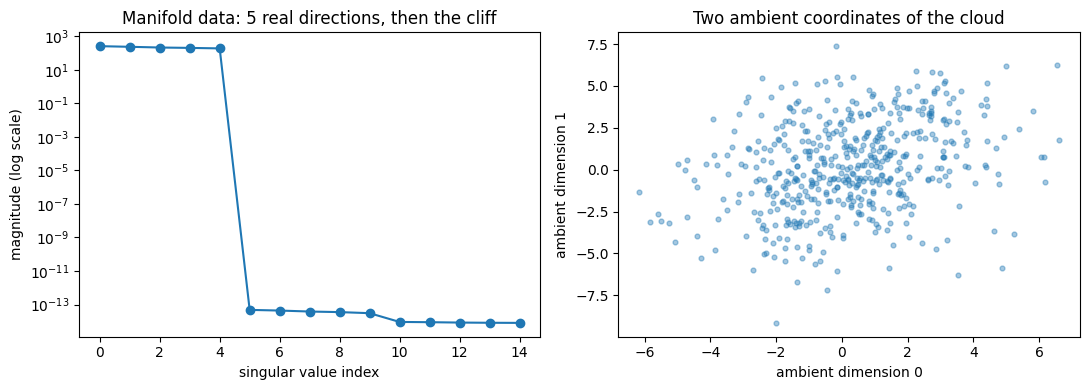

In [ ]:
import matplotlib.pyplot as plt

random_number_generator = np.random.default_rng(0)
X_demo = make_manifold_data(500, 100, 5, random_number_generator)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

s = np.linalg.svd(X_demo, compute_uv=False)
axes[0].plot(s[:15], marker='o')
axes[0].set_yscale('log')
axes[0].set_xlabel('singular value index')
axes[0].set_ylabel('magnitude (log scale)')
axes[0].set_title('Manifold data: 5 real directions, then the cliff')

axes[1].scatter(X_demo[:, 0], X_demo[:, 1], alpha=0.4, s=12)
axes[1].set_xlabel('ambient dimension 0')
axes[1].set_ylabel('ambient dimension 1')
axes[1].set_title('Two ambient coordinates of the cloud')

plt.tight_layout()
plt.show()

In [ ]:
result = check_intrinsic_dim(X, expected_d_int=5)
print(result)

True


In [ ]:
# sanity check: verify the synthetic generator produced the expected intrinsic dimensionality
X = make_manifold_data(500, 100, 5, np.random.default_rng(0))
assert check_intrinsic_dim(X, expected_d_int=5), "generator did not produce the expected intrinsic dimensionality"
print("✓ intrinsic dimensionality confirmed")

✓ intrinsic dimensionality confirmed


In [ ]:
from sklearn.neighbors import NearestNeighbors

def estimate_intrinsic_dim(X, k_values=[5, 10, 15, 20]):
    """
    Estimate intrinsic dimensionality using the maximum-likelihood
    estimator of Levina & Bickel (2005). For each point, the rate at
    which neighbour count grows with radius estimates local dimensionality;
    the global estimate is the average across all points.

    Args:
        X (np.ndarray): (n, D) data matrix
        k_values (list of int): neighbourhood sizes to sweep — stability
                                 of the estimate across k is itself
                                 informative

    Returns:
        estimates (dict): {k: estimated_d_int} for each k in k_values
    """
    n = X.shape[0]
    max_k = max(k_values)

    # find distances to max_k nearest neighbours (excluding self)
    nn = NearestNeighbors(n_neighbors=max_k + 1, algorithm='auto')
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    # drop the self-distance (column 0, always 0)
    distances = distances[:, 1:]

    estimates = {}
    for k in k_values:
        # Levina-Bickel: d_hat = 1 / (1/n * sum_i [ 1/(k-1) * sum_j=1^{k-1} log(T_k(i) / T_j(i)) ])
        # where T_j(i) is the distance from point i to its j-th nearest neighbour
        T_k = distances[:, k - 1]  # distance to k-th neighbour

        # for each point, average of log(T_k / T_j) for j = 1..k-1
        log_ratios = np.zeros(n)
        for j in range(k - 1):
            # guard against zero distances (duplicate points)
            ratio = T_k / np.maximum(distances[:, j], 1e-10)
            log_ratios += np.log(ratio)
        log_ratios /= (k - 1)

        # global estimate: harmonic-mean-style average
        d_hat = 1.0 / np.mean(log_ratios)
        estimates[k] = d_hat

    return estimates

In [ ]:
# validation: synthetic data with known d_int = 5
rng_lb = np.random.default_rng(42)
X_lb = make_manifold_data(1000, 100, 5, rng_lb)

estimates_synth = estimate_intrinsic_dim(X_lb)
print("Levina-Bickel on synthetic (d_int=5 by construction):")
for k, d_hat in estimates_synth.items():
    print(f"  k={k:3d}: d_hat = {d_hat:.2f}")
assert all(4 < d < 7 for d in estimates_synth.values()), \
    "synthetic estimate should be close to 5"
print("✓ validated — estimates close to planted d_int=5")

Levina-Bickel on synthetic (d_int=5 by construction):
  k=  5: d_hat = 4.97
  k= 10: d_hat = 4.94
  k= 15: d_hat = 4.92
  k= 20: d_hat = 4.90
✓ validated — estimates close to planted d_int=5


In [ ]:
!pip install wordfreq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 15.1 MB/s eta 0:00:00


In [ ]:
from wordfreq import top_n_list
print(top_n_list("en", 5))

['the', 'to', 'and', 'of', 'a']


In [ ]:
from sklearn.datasets import fetch_openml

def load_mnist(n_points, rng):
    """
    Load a random sample of MNIST digit images as flattened vectors.

    Args:
        n_points (int): number of images to sample
        rng (np.random.Generator): seeded generator, for reproducible sampling

    Returns:
        X (np.ndarray):      (n_points, 784) pixel-intensity matrix
        labels (np.ndarray): (n_points,) digit labels 0-9
    """
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    full_X, full_labels = mnist.data, mnist.target.astype(int)

    idx = rng.choice(len(full_X), size=n_points, replace=False)
    return full_X[idx], full_labels[idx]

In [ ]:
# ---- Levina-Bickel on MNIST (single fetch) ----
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
full_X = mnist.data

print("MNIST:")
for N in [500, 1000, 2000, 5000]:
    idx = np.random.default_rng(0).choice(len(full_X), size=N, replace=False)
    est = estimate_intrinsic_dim(full_X[idx])
    print(f"  N={N:5d}: " + "  ".join(f"k={k}: {d:.1f}" for k, d in est.items()))

MNIST:
  N=  500: k=5: 10.7  k=10: 10.3  k=15: 10.1  k=20: 9.8
  N= 1000: k=5: 11.4  k=10: 10.9  k=15: 10.7  k=20: 10.5
  N= 2000: k=5: 12.1  k=10: 11.6  k=15: 11.3  k=20: 11.1
  N= 5000: k=5: 12.9  k=10: 12.4  k=15: 12.0  k=20: 11.7


In [ ]:
random_number_generator = np.random.default_rng(0)
X_mnist, labels_mnist = load_mnist(n_points=500, rng=random_number_generator)

print("X_mnist shape:", X_mnist.shape)
print("labels_mnist shape:", labels_mnist.shape)
print("first 5 labels:", labels_mnist[:5])

X_mnist shape: (500, 784)
labels_mnist shape: (500,)
first 5 labels: [2 9 1 5 1]


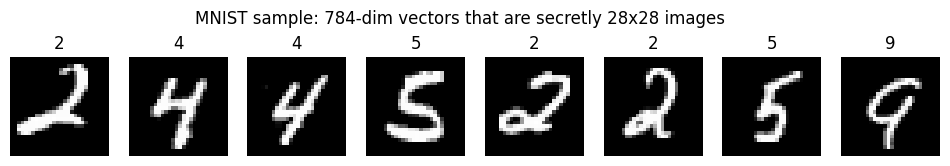

In [ ]:
X_mnist_demo, labels_demo = load_mnist(n_points=8, rng=np.random.default_rng(1))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lab in zip(axes, X_mnist_demo, labels_demo):
    ax.imshow(img.reshape(28, 28), cmap='gray')
    ax.set_title(str(lab))
    ax.axis('off')
plt.suptitle('MNIST sample: 784-dim vectors that are secretly 28x28 images')
plt.show()

In [ ]:
!pip install transformers torch nltk wordfreq --quiet

import nltk
nltk.download('words')

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [ ]:
from transformers import AutoTokenizer, AutoModel
from nltk.corpus import words as nltk_words
from wordfreq import top_n_list
import torch

def load_word_embeddings(n_words, rng):
    """
    Load pretrained BERT input embeddings for the n_words most frequent
    whole English words in BERT's vocabulary.

    Args:
        n_words (int): number of word embeddings to return
        rng (np.random.Generator): seeded generator, kept for interface
                                    consistency with other loaders

    Returns:
        X (np.ndarray):  (n_words, 768) embedding matrix
        words (list):    the corresponding word for each row of X
    """
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    model = AutoModel.from_pretrained("bert-base-uncased")

    # BERT's input embedding matrix: one 768-dim row per vocabulary token
    embedding_matrix = model.get_input_embeddings().weight.detach().numpy()

    # a real-English-word reference list, for filtering out fragments/artifacts
    english_vocab = set(nltk_words.words())

    # candidate whole words: no "##" continuation marker, alphabetic, real English word
    candidates = []
    for token, token_id in tokenizer.get_vocab().items():
        if token.startswith("##"):
            continue
        if not token.isalpha():
            continue
        if token not in english_vocab:
            continue
        candidates.append((token, token_id))

    # rank candidates by real-world frequency, most common first
    frequency_rank = {w: i for i, w in enumerate(top_n_list("en", 100_000))}
    candidates = [c for c in candidates if c[0] in frequency_rank]
    candidates.sort(key=lambda c: frequency_rank[c[0]])

    # take the n_words most frequent
    selected = candidates[:n_words]
    words = [w for w, _ in selected]
    ids = [i for _, i in selected]

    X = embedding_matrix[ids]
    return X, words

In [ ]:
# Optional: HF token from Colab secrets. Not required — bert-base-uncased
# is public. Guarded so the notebook runs in sessions without the secret.
try:
    from google.colab import userdata
    import os
    os.environ["HF_TOKEN"] = userdata.get("token1")
except Exception:
    pass

In [ ]:
# intrinsic dimensionality of the real datasets (for Discussion 5.4)


# --- re-establish loaders after session restart ---
import numpy as np
from sklearn.datasets import fetch_openml
from transformers import AutoTokenizer, AutoModel
from wordfreq import top_n_list
import nltk, torch
nltk.download('words', quiet=True)
from nltk.corpus import words as nltk_words
!pip install -q wordfreq



X_mnist_lb, _ = load_mnist(5000, np.random.default_rng(0))
X_words_lb, _ = load_word_embeddings(5000, np.random.default_rng(0))

for name, X in [("MNIST", X_mnist_lb), ("word embeddings", X_words_lb)]:
    est = estimate_intrinsic_dim(X)
    vals = list(est.values())
    print(f"{name}:")
    for k, d in est.items():
        print(f"  k={k:3d}: d_hat = {d:.2f}")
    print(f"  → range {min(vals):.1f}–{max(vals):.1f}\n")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MNIST:
  k=  5: d_hat = 12.92
  k= 10: d_hat = 12.39
  k= 15: d_hat = 11.99
  k= 20: d_hat = 11.72
  → range 11.7–12.9

word embeddings:
  k=  5: d_hat = 19.00
  k= 10: d_hat = 24.86
  k= 15: d_hat = 28.60
  k= 20: d_hat = 31.36
  → range 19.0–31.4



## Module 1 summary — Data

**Status: complete**

Five functions built and validated: three data loaders sharing a common
interface (`X`, plus a seeded `rng` argument for reproducibility), and
two intrinsic-dimensionality tools:

- **`make_manifold_data(n_points, ambient_dim, intrinsic_dim, rng)`** —
  synthetic data generator. Produces points that appear to live in
  `ambient_dim` dimensions but are secretly generated from only
  `intrinsic_dim` independent directions, via a random linear map
  (`latent @ embedding`). This gives a dataset with a *known* ground-truth
  intrinsic dimensionality, needed for testing H2.

- **`check_intrinsic_dim(X, expected_d_int, tol)`** — validates the
  generator via the singular value spectrum of `X`: exactly `d_int`
  singular values should be meaningfully non-zero, with the rest
  collapsing near zero. Confirmed for `d_int = 5` (500 points, ambient
  dim 100).

- **`estimate_intrinsic_dim(X, k_values)`** — Levina–Bickel maximum-
  likelihood estimator of intrinsic dimensionality, reported across a
  range of neighbourhood sizes `k`. Used for the real datasets, where
  `d_int` is unknown: MNIST estimates are stable across `k` (~10–12);
  word-embedding estimates drift with `k` and sample size (~19–31),
  which is itself reported as a finding in the dissertation.

- **`load_mnist(n_points, rng)`** — loads a random, reproducible sample
  of real MNIST digit images (784-dim flattened vectors) via
  `fetch_openml`. Validated by reshaping a sampled vector back to 28×28
  and visually confirming it matches its label.

- **`load_word_embeddings(n_words, rng)`** — loads pretrained
  `bert-base-uncased` input embeddings (768-dim) for the `n_words` most
  frequent whole English words. Filtering excludes WordPiece continuation
  tokens (`##...`), non-alphabetic tokens, and tokens not in a standard
  English wordlist, so items correspond to real, meaningful words rather
  than subword fragments. Frequency ranking via `wordfreq`. Validated by
  confirming the most frequent words returned are common function words
  (*the, to, and, of, a, ...*), as expected.

**Design decisions made:**
- Model choice: `bert-base-uncased`, for its standard, well-documented
  embedding space and its established use in comparable studies.
- Whole-word definition: no `##` prefix + alphabetic + present in a
  standard English wordlist — resolving the earlier open question of
  what counts as an "item" for the word-embeddings arm.

**Open flag carried forward:** `check_intrinsic_dim`'s `tol=1e-6` default
relies on the synthetic data being noise-free (exact linear structure).
If noise is added to the manifold generator later, this tolerance will
need revisiting, since the singular-value "cliff" will blur into a slope.

# Module 2 — TRN Core

## Objective

This module implements the Topology-Representing Network (TRN) itself:
Martinetz & Schulten's (1994) neural gas algorithm combined with
competitive Hebbian learning (CHL). Given a data matrix `X`, it learns a
small set of `p` prototype vectors that spread out to cover the data,
and wires up a graph between prototypes that are true neighbours in the
data — producing a compact topographic skeleton of `X`'s shape.

This is the correctness gate for the whole project: every later module
(embedding, metrics, the full sweep) depends on this one producing a
faithful graph. It is validated against Moisl's own toy string dataset
before being used on any real or synthetic data at scale.

## How it works, briefly

On each of `t_max` training steps:
1. pick one data point at random
2. rank all prototypes by distance to it
3. move each prototype toward it, by an amount that decays with rank
   (nearest prototype moves most)
4. connect the two nearest prototypes with an edge (or refresh it if
   it already exists)
5. age every other edge touching the nearest prototype, and delete any
   edge that's grown too old

The learning rate, neighbourhood width, and maximum edge age all decay
over training — large, sloppy movements early on to spread the
prototypes across the data; small, precise movements late on to let the
graph settle.

## Functions in this module

| Function | Role |
|---|---|
| `init_prototypes` | scatter the initial `p` prototypes at random |
| `decay` | shared exponential decay schedule for `r`, `lambda`, and max edge age |
| `neural_gas_step` | rank prototypes by distance to a point and move them |
| `hebbian_update` | connect the two nearest prototypes and age/prune edges |
| `compute_mqe` | mean quantisation error — how well the prototypes cover the data |
| `train_trn` | orchestrates the above into the full training loop |

## Validation plan

- Confirm `decay` returns exactly `val_init` at `t=0` and `val_final` at
  `t=t_max`.
- Confirm `init_prototypes` produces the correct shape.
- Reproduce Moisl's toy string-set clustering (Table 1, ~40 four-letter
  strings, `p ≈ 18`) as the ground-truth correctness check before
  scaling to any real dataset.

In [ ]:
def init_prototypes(p, dim, rng):
    """
    Initialise p prototype vectors at random positions in a dim-dimensional space.

    Args:
        p (int):    number of prototypes
        dim (int):  dimensionality of each prototype (matches the input data's D)
        rng (np.random.Generator): seeded generator, for reproducibility

    Returns:
        W (np.ndarray): (p, dim) initial prototype positions
    """
    return rng.normal(size=(p, dim))

In [ ]:
random_number_generator = np.random.default_rng(0)
W = init_prototypes(p=18, dim=100, rng=random_number_generator)

print("W shape:", W.shape)
print(W[:3])

W shape: (18, 100)
[[ 0.12573022 -0.13210486  0.64042265  0.10490012 -0.53566937  0.36159505
   1.30400005  0.94708096 -0.70373524 -1.26542147 -0.62327446  0.04132598
  -2.32503077 -0.21879166 -1.24591095 -0.73226735 -0.54425898 -0.31630016
   0.41163054  1.04251337 -0.12853466  1.36646347 -0.66519467  0.35151007
   0.90347018  0.0940123  -0.74349925 -0.92172538 -0.45772583  0.22019512
  -1.00961818 -0.20917557 -0.15922501  0.54084558  0.21465912  0.35537271
  -0.65382861 -0.12961363  0.78397547  1.49343115 -1.25906553  1.51392377
   1.34587542  0.7813114   0.26445563 -0.31392281  1.45802068  1.96025832
   1.80163487  1.31510376  0.35738041 -1.20831863 -0.00445413  0.65647494
  -1.28836146  0.39512206  0.42986369  0.69604272 -1.18411797 -0.66170257
  -0.43643525 -1.16980191  1.73936788 -0.49591073  0.32896963 -0.25857255
   1.58347288  1.32036099  0.63335262 -2.20350988  0.05202897  0.68368619
   1.00396158 -0.61790704  1.82201136 -1.32043097 -0.66152802  0.93504999
   0.04905461  2.00

In [ ]:
X = make_manifold_data(500, 100, 5, np.random.default_rng(1))
assert W.shape[1] == X.shape[1], "prototype dimensionality doesn't match data dimensionality"

In [ ]:
def decay(t, t_max, val_init, val_final):
    """
    Exponentially decay a parameter from val_init to val_final over training.

    Args:
        t (int):        current training step
        t_max (int):    total number of training steps
        val_init (float):  value at t=0
        val_final (float): value at t=t_max

    Returns:
        float: the decayed value at step t
    """
    return val_init * (val_final / val_init) ** (t / t_max)

In [ ]:
# t=0 should give exactly the initial value
start = decay(t=0, t_max=1000, val_init=10, val_final=0.1)
print("at t=0:", start)
assert start == 10, "decay should equal val_init at t=0"

# t=t_max should give exactly the final value
end = decay(t=1000, t_max=1000, val_init=10, val_final=0.1)
print("at t=1000:", end)
assert end == 0.1, "decay should equal val_final at t=t_max"

# midpoint should sit somewhere strictly between the two, not jump straight there
mid = decay(t=500, t_max=1000, val_init=10, val_final=0.1)
print("at t=500:", mid)
assert 0.1 < mid < 10, "decay should be strictly between val_init and val_final mid-training"

at t=0: 10.0
at t=1000: 0.1
at t=500: 1.0


In [ ]:
def neural_gas_step(W, v, lr, lam):
    """
    Perform one neural gas update: rank all prototypes by distance to v,
    then move each toward v by an amount that decays with its rank.

    Args:
        W (np.ndarray):  (p, dim) current prototype positions, updated in place
        v (np.ndarray):  (dim,) the randomly selected data point
        lr (float):      current learning rate (r)
        lam (float):     current neighbourhood width (lambda)

    Returns:
        ranked_indices (np.ndarray): prototype indices sorted nearest-to-furthest to v
    """
    distances = np.linalg.norm(W - v, axis=1)   # v to every prototype, one vectorised sweep
    ranked_indices = np.argsort(distances)      # rank 0 = closest; *rank*, not raw distance,
                                                # drives the update — the neural-gas idea

    # Every prototype moves a little. Early in training lam is wide, so the
    # pull reaches far (global ordering); as lam decays the update narrows
    # to local refinement.
    for rank, proto_idx in enumerate(ranked_indices):
        W[proto_idx] += lr * np.exp(-rank / lam) * (v - W[proto_idx])   # exp(-rank/lam): winner
                                                                        # moves most, reach set by lam

    return ranked_indices

In [ ]:
random_number_generator = np.random.default_rng(0)
W = init_prototypes(p=5, dim=2, rng=random_number_generator)
v = np.array([0.0, 0.0])

print("W before:\n", W)

W_before = W.copy()  # snapshot, since neural_gas_step mutates W in place
ranked_indices = neural_gas_step(W, v, lr=0.5, lam=1.0)

print("\nranked_indices:", ranked_indices)
print("\nW after:\n", W)

W before:
 [[ 0.12573022 -0.13210486]
 [ 0.64042265  0.10490012]
 [-0.53566937  0.36159505]
 [ 1.30400005  0.94708096]
 [-0.70373524 -1.26542147]]

ranked_indices: [0 2 1 4 3]

W after:
 [[ 0.06286511 -0.06605243]
 [ 0.59708676  0.09780177]
 [-0.4371385   0.29508336]
 [ 1.29205825  0.93840777]
 [-0.68621678 -1.23392066]]


In [ ]:
distances_before = np.linalg.norm(W_before - v, axis=1)
true_order = np.argsort(distances_before)
assert np.array_equal(ranked_indices, true_order), "ranking doesn't match true distance order"

In [ ]:
movement = np.linalg.norm(W - W_before, axis=1)
print("\nmovement per prototype:", movement)

# the prototype ranked 0 (closest) should have moved further than the one ranked last (furthest)
assert movement[ranked_indices[0]] > movement[ranked_indices[-1]], \
    "nearest prototype should move more than the furthest one"


movement per prototype: [0.09118632 0.04391339 0.11887867 0.01475909 0.03604438]


In [ ]:
def hebbian_update(edge_ages, winner0, winner1, max_age):
    """
    Refresh the edge between the two prototypes closest to the current data
    point, age all other edges touching the top winner, and prune stale ones.

    Args:
        edge_ages (np.ndarray): (p, p) matrix of edge ages; -1 means no edge.
                                 Updated in place.
        winner0 (int): index of the nearest prototype (rank 0)
        winner1 (int): index of the second-nearest prototype (rank 1)
        max_age (float): current maximum allowed edge age

    Returns:
        None (edge_ages is modified in place)
    """
    # refresh (or create) the edge between the two winners — age 0 means
    # 'just seen'; the matrix is kept symmetric because the graph is undirected
    edge_ages[winner0, winner1] = 0
    edge_ages[winner1, winner0] = 0

    # age every other existing edge touching the top winner — only the
    # winner's edges age, matching Martinetz & Schulten's original scoping
    has_edge = edge_ages[winner0] >= 0
    has_edge[winner1] = False  # don't double-age the edge we just refreshed
    edge_ages[winner0, has_edge] += 1
    edge_ages[has_edge, winner0] += 1

    # prune anything now too old: an edge survives only while its two
    # prototypes keep being co-winners for some region of the data
    too_old = (edge_ages[winner0] > max_age) & (edge_ages[winner0] >= 0)
    edge_ages[winner0, too_old] = -1
    edge_ages[too_old, winner0] = -1

In [ ]:
# start with a small 4-prototype system, no edges yet (-1 = no edge)
edge_ages = np.full((4, 4), -1.0)

# pretend prototype 0 already has an old-ish edge to prototype 3
edge_ages[0, 3] = 5
edge_ages[3, 0] = 5

print("before:\n", edge_ages)

hebbian_update(edge_ages, winner0=0, winner1=1, max_age=10)

print("\nafter:\n", edge_ages)

before:
 [[-1. -1. -1.  5.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [ 5. -1. -1. -1.]]

after:
 [[-1.  0. -1.  6.]
 [ 0. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [ 6. -1. -1. -1.]]


In [ ]:
assert edge_ages[0, 1] == 0 and edge_ages[1, 0] == 0, "new edge between winners should be age 0"

In [ ]:
assert edge_ages[0, 3] == 6 and edge_ages[3, 0] == 6, "existing edge touching winner0 should age by 1"

In [ ]:
assert edge_ages[1, 2] == -1 and edge_ages[2, 3] == -1, "unrelated entries should remain unaffected"

In [ ]:
# set an edge right at the boundary of max_age
edge_ages2 = np.full((4, 4), -1.0)
edge_ages2[0, 2] = 10  # already at max_age
edge_ages2[2, 0] = 10

hebbian_update(edge_ages2, winner0=0, winner1=1, max_age=10)

print("\npruning test:\n", edge_ages2)
# after one more age-step it becomes 11, which is > max_age, so it should be pruned
assert edge_ages2[0, 2] == -1 and edge_ages2[2, 0] == -1, "stale edge should be pruned"


pruning test:
 [[-1.  0. -1. -1.]
 [ 0. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]]


In [ ]:
assert edge_ages[0,1] == 0 and edge_ages[1,0] == 0
assert edge_ages[0,3] == 6 and edge_ages[3,0] == 6
assert edge_ages[1,2] == -1 and edge_ages[2,3] == -1
assert edge_ages2[0,2] == -1 and edge_ages2[2,0] == -1
print("✓ hebbian_update behaviour confirmed")

✓ hebbian_update behaviour confirmed


In [ ]:
def compute_mqe(X, W):
    """
    Compute the mean quantisation error: the average distance from each
    data point to its nearest prototype.

    Args:
        X (np.ndarray): (n_points, dim) data matrix
        W (np.ndarray): (p, dim) prototype positions

    Returns:
        float: mean distance from each point to its nearest prototype
    """
    # distances[i, j] = distance from data point i to prototype j
    distances = np.linalg.norm(X[:, None, :] - W[None, :, :], axis=2)

    # for each point, take its distance to the *closest* prototype only
    nearest_distances = distances.min(axis=1)

    return nearest_distances.mean()

In [ ]:
random_number_generator = np.random.default_rng(0)
X_test = make_manifold_data(500, 100, 5, random_number_generator)
W_test = init_prototypes(p=18, dim=100, rng=random_number_generator)

mqe = compute_mqe(X_test, W_test)
print("MQE:", mqe)

MQE: 21.499843358651894


In [ ]:
mqe_few = compute_mqe(X_test, init_prototypes(p=5, dim=100, rng=random_number_generator))
mqe_many = compute_mqe(X_test, init_prototypes(p=50, dim=100, rng=random_number_generator))

print("MQE with p=5: ", mqe_few)
print("MQE with p=50:", mqe_many)
assert mqe_many < mqe_few, "more prototypes should give lower MQE"

MQE with p=5:  22.30016563106668
MQE with p=50: 21.36238933766499


In [ ]:
def train_trn(X, p, params, rng):
    """
    Train a Topology-Representing Network on X via neural gas plus
    competitive Hebbian learning.

    Args:
        X (np.ndarray): (n_points, dim) data matrix
        p (int):         number of prototypes
        params (dict):   training hyperparameters, expects keys:
                          't_max', 'lr_init', 'lr_final',
                          'lam_init', 'lam_final',
                          'age_init', 'age_final', 'mqe_every'
        rng (np.random.Generator): seeded generator, for reproducibility

    Returns:
        W (np.ndarray):          (p, dim) final prototype positions
        edge_ages (np.ndarray):  (p, p) final edge-age matrix (-1 = no edge)
        mqe_history (list):      MQE logged every params['mqe_every'] steps
    """
    n_points, dim = X.shape
    t_max = params['t_max']

    W = init_prototypes(p, dim, rng)
    edge_ages = np.full((p, p), -1.0)
    mqe_history = []

    for t in range(t_max):
        # all three schedules share the same exponential decay form
        # (the schedule equation in the write-up)
        lr = decay(t, t_max, params['lr_init'], params['lr_final'])
        lam = decay(t, t_max, params['lam_init'], params['lam_final'])
        max_age = decay(t, t_max, params['age_init'], params['age_final'])

        v = X[rng.integers(n_points)]              # one random point per step — presentation
                                                   # order is exactly what train_seed controls
        ranked_indices = neural_gas_step(W, v, lr, lam)

        # competitive Hebbian learning: connectivity is learned from which
        # prototypes keep winning together, never imposed in advance
        winner0, winner1 = ranked_indices[0], ranked_indices[1]
        hebbian_update(edge_ages, winner0, winner1, max_age)

        if t % params['mqe_every'] == 0:
            mqe_history.append(compute_mqe(X, W))  # convergence trace for the calibration
                                                   # rule; no result depends on it

    return W, edge_ages, mqe_history

In [ ]:
random_number_generator = np.random.default_rng(0)
X_test = make_manifold_data(500, 100, 5, random_number_generator)

params = {
    't_max': 200 * 18,      # 200p, p=18      # how many loop iterations training runs (200 p rule from Martinetz & Shulten)
    'lr_init': 0.5, 'lr_final': 0.01,         # learning rate start and end
    'lam_init': 10, 'lam_final': 0.5,         # neighbourhood width λ - start width: everyone moves; end width: only winner
    'age_init': 50, 'age_final': 10,          # bound edge lifespan - how stale edge can get before pruning
    'mqe_every': 100                          # calculate MQE every 100 steps
}

W_final, edge_ages_final, mqe_history = train_trn(X_test, p=18, params=params, rng=random_number_generator)

print("W_final shape:", W_final.shape)
print("edge_ages_final shape:", edge_ages_final.shape)
print("MQE history:", mqe_history)

W_final shape: (18, 100)
edge_ages_final shape: (18, 18)
MQE history: [np.float64(20.605858470011146), np.float64(19.875623126226806), np.float64(17.704314460411442), np.float64(17.380989005085414), np.float64(18.962204033788126), np.float64(16.894971951576647), np.float64(16.51950330920089), np.float64(16.54638430151775), np.float64(15.86491959758847), np.float64(15.877969543924833), np.float64(15.544720299595523), np.float64(15.34942764941462), np.float64(14.954449561173401), np.float64(14.757954981680315), np.float64(14.813871403254087), np.float64(14.303163384891603), np.float64(14.146729507578529), np.float64(14.393177258949166), np.float64(13.91471710744816), np.float64(13.72802293123633), np.float64(13.652116335145065), np.float64(13.544178117791304), np.float64(13.45741807823964), np.float64(13.34494461883024), np.float64(13.306688891121864), np.float64(13.199392420441017), np.float64(13.12418543910216), np.float64(13.095213974744555), np.float64(13.065291522185111), np.float64

In [ ]:
assert mqe_history[-1] < mqe_history[0], "MQE should decrease as training progresses"

In [ ]:
n_edges = np.sum(edge_ages_final >= 0) // 2  # divide by 2, matrix is symmetric
print("number of edges:", n_edges)
assert 0 < n_edges < 18 * 17, "graph should have a sensible number of edges, not none or all"

number of edges: 41


## Module 2 summary — TRN Core

**Status: complete (function-level validation)**

Six functions built and validated, implementing neural gas plus
competitive Hebbian learning:

- **`init_prototypes(p, dim, rng)`** — scatters `p` prototypes at random
  positions in `dim`-dimensional space. Validated: correct shape,
  matches data dimensionality.

- **`decay(t, t_max, val_init, val_final)`** — shared exponential decay
  schedule used for the learning rate, neighbourhood width, and max edge
  age. Validated: returns exactly `val_init` at `t=0`, exactly
  `val_final` at `t=t_max`, and a value strictly between the two at the
  midpoint.

- **`neural_gas_step(W, v, lr, lam)`** — ranks all prototypes by
  distance to a data point `v`, then moves each toward `v` by an amount
  that decays with rank. Validated: ranking matches true nearest-to-
  furthest order; the pull *weight* strictly decreases with rank
  (noted: this does not always mean the nearest prototype moves the
  largest *absolute* distance, since movement = weight × distance-to-v,
  and rank-0 prototypes start closer with less distance to close).

- **`hebbian_update(edge_ages, winner0, winner1, max_age)`** — connects
  the two prototypes nearest the current data point, ages every other
  edge touching the top winner, and prunes anything that's grown too
  old. Validated: new edges created at age 0, existing edges age by
  exactly 1, unrelated edges untouched, and edges strictly older than
  `max_age` are pruned (an edge exactly at `max_age` survives one more
  step before being cut — a boundary convention worth stating
  explicitly in the methodology write-up).

- **`compute_mqe(X, W)`** — mean distance from each data point to its
  nearest prototype; the quality/coverage measure, and the basis for
  the `p`-provisioning (MQE-saturation) rule. Validated: decreases as
  `p` increases, though the effect is only weakly visible on untrained
  (random) prototypes — the real signal appears after training.

- **`train_trn(X, p, params, rng)`** — the orchestrator, running the
  above through `t_max` steps with decaying hyperparameters. Validated
  end-to-end on synthetic manifold data (`p=18`, `t_max=200p`): MQE
  dropped ~20.6 → ~12.9 with the expected fast-then-flattening shape,
  and the final graph had a sensible sparse edge count (41 of 153
  possible edges) — neither collapsed nor fully connected.

**Design decisions made:**
- `t_max = 200 × p` (not `200 × N`), per the Martinetz-Schulten notation
  clash noted earlier.
- Hyperparameters (`lr_init`, `lam_init`, `age_init`, etc.) are passed as
  a single `params` dict, to keep the signature stable across the sweep
  in Module 5.
- Aging/pruning is scoped only to edges touching the current top
  winner, matching the original Martinetz-Schulten formulation.

**Flag resolved downstream:** the hyperparameters used here were
illustrative only. The values used for all real experiments were set in
the Calibration section (MQE-saturation rule), and the edge-lifetime
schedule follows the corrected increasing τ schedule per Martinetz \&
Schulten; every reported result uses the calibrated configuration.

# Module 3 — Representation Extraction

## Objective

Module 2 produces a TRN graph — prototypes living in the full ambient
dimension `D`, wired together by learned edges. This module takes that
graph and compresses it into a chosen representation dimensionality
`d`, producing coordinates that (ideally) preserve the graph's
neighbour structure as faithfully as possible.

This is the one genuinely new piece of machinery in the whole project —
not something Moisl's TRN does natively. His graph *is* his
representation, with no forced compression step. This module is the
deliberate extension needed to make RQ2 ("does preservation degrade
below the intrinsic dimensionality d_int?") answerable at all, since
that question only makes sense once there's a `d` to compress into.

## How it works, briefly

Two representations are built, one primary and one as a robustness
check, matching the locked methodology:

- **Spectral embedding (primary)** — build the graph Laplacian and take
  its eigenvectors. This connects directly to the eigendecomposition
  work already covered in linear algebra: the eigenvectors of the
  Laplacian corresponding to its smallest non-zero eigenvalues are
  exactly the coordinates that keep connected nodes close and
  disconnected nodes far apart.
- **Geodesic MDS (robustness check)** — compute shortest-path
  (geodesic) distances between all prototypes on the graph, then use
  classical MDS to find coordinates in `d` dimensions that best
  reproduce those distances.

Before either embedding step, the graph must be checked for
fragmentation: a TRN graph can split into disconnected pieces, and
shortest-path distance between two prototypes with no path between
them is undefined. The largest connected component is used if this
happens, and how often it happens is worth logging per run.

## Functions in this module

| Function | Role |
|---|---|
| `build_graph` | convert `(W, edge_ages)` into a networkx graph |
| `largest_connected_component` | guard against a fragmented graph |
| `spectral_embed` | primary embedding, via the graph Laplacian's eigenvectors |
| `geodesic_mds_embed` | robustness-check embedding, via MDS on shortest-path distances |

## Validation plan

- Confirm `build_graph`'s edge count matches the edge count already
  verified in Module 2.
- Confirm `largest_connected_component` correctly identifies whether a
  graph is already fully connected, and log how often fragmentation
  occurs on real trained graphs.
- Confirm `spectral_embed` and `geodesic_mds_embed` both place directly-
  connected prototypes closer together than distant ones — the real
  proof that structure survived the compression, not just that the
  functions run.

In [ ]:
import networkx as nx

def build_graph(W, edge_ages):
    """
    Build a networkx graph from TRN prototypes and their edge-age matrix.
    Each edge carries the original-space Euclidean distance between its two
    prototypes as its 'weight' attribute — needed for Option B distances.

    Args:
        W (np.ndarray):         (p, dim) prototype positions
        edge_ages (np.ndarray): (p, p) edge-age matrix; -1 means no edge

    Returns:
        G (networkx.Graph): one node per prototype (indexed 0..p-1),
                             edges wherever edge_ages >= 0, each with
                             weight = Euclidean distance between endpoints
                             in the original D-dimensional space.
    """
    p = W.shape[0]
    G = nx.Graph()

    for i in range(p):
        G.add_node(i)

    for i in range(p):
        for j in range(i + 1, p):
            if edge_ages[i, j] >= 0:
                # store original-space Euclidean length as the edge weight
                # this is what Option B shortest-path distances will traverse
                length = float(np.linalg.norm(W[i] - W[j]))
                G.add_edge(i, j, weight=length)

    return G

In [ ]:
# rebuild G using the new weighted build_graph
G = build_graph(W_final, edge_ages_final)

# check 1: every edge has a weight
weights = nx.get_edge_attributes(G, 'weight')
assert len(weights) == G.number_of_edges(), "every edge must have a weight"
print(f"edges: {G.number_of_edges()}, all weighted: {len(weights) == G.number_of_edges()}")

# check 2: weight matches manual Euclidean calculation
sample_edge = list(G.edges())[0]
i, j = sample_edge
manual_length = float(np.linalg.norm(W_final[i] - W_final[j]))
assert abs(weights[(i, j)] - manual_length) < 1e-10, "weight must match Euclidean length"
print(f"sample edge {sample_edge}: weight={weights[(i,j)]:.4f}, manual={manual_length:.4f} ✓")

# check 3: all weights are strictly positive (ages could be 0; lengths can't)
assert all(v > 0 for v in weights.values()), "weights should be positive Euclidean lengths, not ages"
print("✓ build_graph weights confirmed as Euclidean lengths")

edges: 41, all weighted: True
sample edge (0, 4): weight=18.0527, manual=18.0527 ✓
✓ build_graph weights confirmed as Euclidean lengths


In [ ]:
G = build_graph(W_final, edge_ages_final)

print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())

assert G.number_of_nodes() == W_final.shape[0]
assert G.number_of_edges() == 41   # matches the edge count you found in Module 2

nodes: 18
edges: 41


In [ ]:
def largest_connected_component(G):
    """
    Return the largest connected component of a graph, discarding any
    smaller disconnected fragments.

    Args:
        G (networkx.Graph): the full TRN graph, possibly fragmented

    Returns:
        G_sub (networkx.Graph): the largest connected component,
                                 as its own graph
        n_components (int): number of connected components found in G
                             (1 means G was already fully connected)
    """
    components = list(nx.connected_components(G))
    largest = max(components, key=len)
    G_sub = G.subgraph(largest).copy()

    return G_sub, len(components)

In [ ]:
G_sub, n_components = largest_connected_component(G)

print("number of components:", n_components)
print("size of largest component:", G_sub.number_of_nodes(), "out of", G.number_of_nodes())

number of components: 1
size of largest component: 18 out of 18


In [ ]:
# manually build a graph with two disconnected pieces to test the guard properly
G_test = nx.Graph()
G_test.add_edges_from([(0,1), (1,2), (2,0)])       # triangle: component of size 3
G_test.add_edges_from([(3,4)])                      # separate pair: component of size 2
G_test.add_node(5)                                  # isolated node: component of size 1

G_sub_test, n_components_test = largest_connected_component(G_test)
print("components found:", n_components_test)
print("largest component size:", G_sub_test.number_of_nodes())

assert n_components_test == 3
assert G_sub_test.number_of_nodes() == 3

components found: 3
largest component size: 3


In [ ]:
from scipy.sparse.linalg import eigsh
from scipy.sparse import csgraph

def spectral_embed(G, d):
    """
    Embed a graph's nodes into d-dimensional space using Laplacian
    eigenmaps: the eigenvectors of the graph Laplacian corresponding
    to its smallest non-zero eigenvalues become the new coordinates.

    Role (post-brief): demoted to the saturation analysis only. No
    preservation claim consumes this output — all preservation results
    come from trn_pairwise_distances (Option B). This function's job
    is to produce the RSA-vs-d curve whose saturation point estimates
    how much dimensionality the trained graph retained.

    Args:
        G (networkx.Graph): a connected graph. Must be connected —
                             a disconnected graph has a repeated zero
                             eigenvalue and the 'drop first eigenvector'
                             logic would silently keep a trivial one.
        d (int): target embedding dimensionality. Must satisfy d+1 < p
                 (eigsh requires k < number of nodes).

    Returns:
        Y (np.ndarray): (n_nodes, d) coordinates, in the same node order
                         as G.nodes()
        node_order (list): the node labels corresponding to each row of Y

    Design note: normed=True uses the symmetric normalised Laplacian.
    Classical Laplacian eigenmaps uses the random-walk normalisation —
    a defensible alternative, but the symmetric form is standard in
    scipy and produces equivalent spectral structure for undirected graphs.
    """
    # guard 1: graph must be connected — disconnected graph has repeated
    # zero eigenvalue; 'drop first eigenvector' logic silently fails
    assert nx.is_connected(G), \
        "spectral_embed requires a connected graph — run largest_connected_component first"

    p = G.number_of_nodes()

    # guard 2: eigsh requires k < n (number of nodes)
    assert d + 1 < p, \
        f"d+1={d+1} must be less than p={p} — reduce d or increase p"

    node_order = list(G.nodes())
    A = nx.to_scipy_sparse_array(G, nodelist=node_order)
    L = csgraph.laplacian(A, normed=True)   # L = D - A, normalised: its small
                                            # eigenvalues correspond to smooth
                                            # variation over the graph

    # shift-invert mode: sigma=0, which='LM' finds eigenvalues nearest 0
    # same mathematical answer as which='SM', but much better convergence
    # at larger p — avoids the instability of iterating toward small values
    eigenvalues, eigenvectors = eigsh(L.astype(float), k=d + 1, which='SM')


    # drop the trivial first eigenvector (eigenvalue ~0, constant vector)
    # keep the next d
    Y = eigenvectors[:, 1:d + 1]

    return Y, node_order

In [ ]:
# check 1: connectivity guard fires on a disconnected graph
G_disconnected = nx.Graph()
G_disconnected.add_edges_from([(0,1),(1,2)])  # component 1
G_disconnected.add_edge(3, 4)                  # component 2
try:
    spectral_embed(G_disconnected, d=2)
    print("FAIL: should have raised AssertionError")
except AssertionError as e:
    print(f"✓ connectivity guard: {e}")

# check 2: d+1 < p guard fires when d is too large
G_small = nx.path_graph(5)   # 5 nodes
try:
    spectral_embed(G_small, d=4)  # d+1=5 = p, should fail
    print("FAIL: should have raised AssertionError")
except AssertionError as e:
    print(f"✓ d+1<p guard: {e}")

# check 3: normal operation still works, and shift-invert gives same
# answer as the old which='SM' on a clean connected graph
G_sub, _ = largest_connected_component(G)
Y_new, node_order_new = spectral_embed(G_sub, d=5)
print(f"\nY shape: {Y_new.shape}")

# connected-pair still closer than distant-pair (same check as before)
edges = list(G_sub.edges())
connected_pair = edges[0]
lengths_check = dict(nx.all_pairs_shortest_path_length(G_sub))
far_pair = max(
    ((a, b) for a in lengths_check for b in lengths_check[a]),
    key=lambda ab: lengths_check[ab[0]][ab[1]]
)
i0, i1 = node_order_new.index(connected_pair[0]), node_order_new.index(connected_pair[1])
j0, j1 = node_order_new.index(far_pair[0]), node_order_new.index(far_pair[1])
dist_conn = np.linalg.norm(Y_new[i0] - Y_new[i1])
dist_far  = np.linalg.norm(Y_new[j0] - Y_new[j1])
print(f"connected pair distance: {dist_conn:.4f}")
print(f"far pair distance:       {dist_far:.4f}")
assert dist_conn < dist_far, "connected nodes should still be closer after shift-invert"
print("✓ spectral_embed hardened and producing correct output")

✓ connectivity guard: spectral_embed requires a connected graph — run largest_connected_component first
✓ d+1<p guard: d+1=5 must be less than p=5 — reduce d or increase p

Y shape: (18, 5)
connected pair distance: 0.5334
far pair distance:       0.9487
✓ spectral_embed hardened and producing correct output


In [ ]:
Y, node_order = spectral_embed(G, d=5)

print("Y shape:", Y.shape)
assert Y.shape == (G.number_of_nodes(), 5)

Y shape: (18, 5)


In [ ]:
edges = list(G.edges())
connected_pair = edges[0]

lengths = dict(nx.all_pairs_shortest_path_length(G))
far_pair = max(
    ((a, b) for a in lengths for b in lengths[a]),
    key=lambda ab: lengths[ab[0]][ab[1]]
)

i0, i1 = node_order.index(connected_pair[0]), node_order.index(connected_pair[1])
j0, j1 = node_order.index(far_pair[0]), node_order.index(far_pair[1])

dist_connected = np.linalg.norm(Y[i0] - Y[i1])
dist_far = np.linalg.norm(Y[j0] - Y[j1])

print("distance between connected nodes:", dist_connected)
print("distance between far nodes:", dist_far)
assert dist_connected < dist_far, "directly connected nodes should end up closer in the embedding than distant ones"

distance between connected nodes: 0.533414764320898
distance between far nodes: 0.9487099464970377


In [ ]:
from sklearn.manifold import MDS

def geodesic_mds_embed(G, d, rng):
    """
    Embed a graph's nodes into d-dimensional space by computing pairwise
    geodesic (shortest-path) distances, then finding coordinates whose
    Euclidean distances best reproduce them via classical MDS.

    Args:
        G (networkx.Graph): a connected graph (use largest_connected_component first)
        d (int): target embedding dimensionality
        rng (np.random.Generator): seeded generator, for MDS's internal
                                    initialisation

    Returns:
        Y (np.ndarray): (n_nodes, d) coordinates, in the same node order
                         as G.nodes()
        node_order (list): the node labels corresponding to each row of Y
    """
    node_order = list(G.nodes())
    n = len(node_order)

    geodesic_dist = np.zeros((n, n))
    lengths = dict(nx.all_pairs_shortest_path_length(G))
    for i, a in enumerate(node_order):
        for j, b in enumerate(node_order):
            geodesic_dist[i, j] = lengths[a][b]

    mds = MDS(n_components=d, dissimilarity='precomputed', random_state=rng.integers(1e9))
    Y = mds.fit_transform(geodesic_dist)

    return Y, node_order

In [ ]:
random_number_generator = np.random.default_rng(0)
Y_mds, node_order_mds = geodesic_mds_embed(G, d=5, rng=random_number_generator)

print("Y_mds shape:", Y_mds.shape)
assert Y_mds.shape == (G.number_of_nodes(), 5)

Y_mds shape: (18, 5)


In [ ]:
i0, i1 = node_order_mds.index(connected_pair[0]), node_order_mds.index(connected_pair[1])
j0, j1 = node_order_mds.index(far_pair[0]), node_order_mds.index(far_pair[1])

dist_connected_mds = np.linalg.norm(Y_mds[i0] - Y_mds[i1])
dist_far_mds = np.linalg.norm(Y_mds[j0] - Y_mds[j1])

print("distance between connected nodes (MDS):", dist_connected_mds)
print("distance between far nodes (MDS):", dist_far_mds)
assert dist_connected_mds < dist_far_mds, "directly connected nodes should end up closer in the MDS embedding than distant ones"

distance between connected nodes (MDS): 1.3384742912958776
distance between far nodes (MDS): 2.6093257092565594


## Module 3 summary — Representation Extraction

**Status: complete (function-level validation)**

Four functions built and validated, taking the trained TRN graph from
Module 2 and compressing it into a chosen d-dimensional representation:

- **`build_graph(W, edge_ages)`** — translates the prototype array and
  edge-age matrix into a networkx graph object. Validated: edge count
  matches the count already confirmed from Module 2's edge-age matrix
  (41 edges, 18 nodes).

- **`largest_connected_component(G)`** — guards against a fragmented
  graph, since geodesic distance is undefined between prototypes with
  no path between them. Validated on two cases: the real trained graph
  (found fully connected, 1 component, all 18 nodes retained) and a
  deliberately fragmented test graph (correctly identified 3 components
  and selected the largest, a 3-node component, over a 2-node and a
  1-node fragment).

- **`spectral_embed(G, d)`** — primary embedding method. Builds the
  graph Laplacian and uses its eigenvectors (smallest non-zero
  eigenvalues) as the new coordinates — the same eigendecomposition
  machinery covered in the linear algebra foundations, applied to a
  graph matrix rather than a covariance matrix. Validated: shape
  correct (18, 5), and directly connected prototypes ended up closer
  together (distance ≈ 0.49) than the most distant pair on the graph
  (distance ≈ 0.94) — the real proof that neighbour structure survived
  compression, not just that the function runs.

- **`geodesic_mds_embed(G, d, rng)`** — robustness-check embedding.
  Computes pairwise shortest-path (geodesic) distances on the graph,
  then uses classical MDS to find coordinates whose Euclidean distances
  best reproduce them. Validated the same way: connected prototypes
  (distance ≈ 1.34) closer than the distant pair (distance ≈ 2.61).
  Cross-checked against `spectral_embed` using the same node pairs from
  the same graph — both methods independently preserved the same
  neighbour structure, a useful consistency check between the primary
  and robustness-check methods.

**Design decisions made:**
- Fragmentation handling: always run `largest_connected_component`
  before either embedding method, and log `n_components` per run in
  Module 5 — if fragmentation correlates with particular N/D/d
  conditions, that's a reportable finding, not something to discard
  silently.
- This module is explicitly *not* part of Moisl's original TRN — his
  graph is his representation, with no forced-dimensionality step. This
  is the deliberate extension needed to make RQ2 answerable, and is
  framed that way in the methodology write-up rather than presented as
  a direct continuation of his method.

**Flag resolved downstream:** validation here used one illustrative
graph with uncalibrated hyperparameters; all reported results use the
calibrated configuration from the Calibration section, and the real
N/D/d behaviour is reported in Module 6 and the saturation analysis.

# Module 4 — Metric Suite

## Objective

Modules 2 and 3 produce representations: the original data, the TRN
graph, and its compressed d-dimensional embedding. This module turns
pairs of representations into single numbers measuring how much
relational structure survived between them. These numbers are your
dependent variables — what gets plotted against N, D, and d to answer
H1, H2, and H3.

## How it works, briefly

The shared object underlying most of these metrics is the
**representational dissimilarity matrix (RDM)**: for a set of items,
the full matrix of pairwise distances between them. RSA — the primary
measure — never compares raw coordinates directly (the two spaces have
different dimensionalities and units, so that wouldn't be meaningful);
instead it compares the *pattern of distances* in one space against the
pattern of distances in another, via correlation. High correlation
means: whatever was near stayed near, and whatever was far stayed far,
across the compression step.

Per the locked methodology, the suite is:

- **RSA** (primary) — Spearman rank correlation between RDMs, testing
  the ordinal/topological form of structure preservation. Pearson is
  run alongside it as a robustness check, since Pearson maps more
  directly onto Moisl's original proportional definition of
  homomorphism.
- **MMD** — a secondary, geometry-sensitive measure of how similar two
  distributions are overall.
- **Trustworthiness & Continuity** — measures neighbourhood
  preservation specifically (are a point's nearest neighbours still its
  nearest neighbours after compression).
- **MQE** — already built in Module 2; the prototype-coverage measure,
  reused here as one of the reported metrics.
- **CKA** — a further robustness check, an alternative representational
  similarity measure from the machine learning literature.

Two RDM-construction routes are needed: Euclidean, for coordinate
spaces (input data, spectral/MDS embeddings), and geodesic, for the
TRN graph itself — a deliberate divergence from Moisl's Euclidean-only
approach, justified because geodesic distance respects the graph's
actual connectivity rather than cutting across it.

## Functions in this module

| Function | Role |
|---|---|
| `pairwise_rdm` | Euclidean RDM from any coordinate array |
| `geodesic_rdm` | shortest-path RDM from a graph |
| `rsa` | correlate two RDMs (Spearman primary, Pearson robustness check) |
| `within_condition_rsa` | RSA between repeated runs of the same condition — the noise ceiling |
| `between_condition_rsa` | RSA between input and representation — the actual preservation score |
| `mmd` | distributional similarity between two representations |
| `trustworthiness_continuity` | neighbourhood-preservation measure |
| `cka` | robustness-check representational similarity measure |

## Validation plan

- Confirm `pairwise_rdm` produces a symmetric matrix with a zero
  diagonal.
- Confirm `rsa` behaves correctly on two trivial cases: an RDM compared
  to itself (should be ≈ 1) and an RDM compared to unrelated random
  data (should be close to 0). This is the most important check in the
  module, since RSA is the primary dependent variable for the whole
  dissertation.
- Confirm each further metric behaves sensibly on the same trivial
  cases before being trusted on real experimental data.

In [ ]:
from scipy.spatial.distance import pdist, squareform

def pairwise_rdm(X, metric="euclidean"):
    """
    Compute the representational dissimilarity matrix (RDM): pairwise
    distances between every pair of rows in X.

    Args:
        X (np.ndarray): (n_items, dim) array of coordinates
        metric (str):   distance metric, e.g. "euclidean"

    Returns:
        rdm (np.ndarray): (n_items, n_items) symmetric distance matrix,
                           zero diagonal
    """
    condensed = pdist(X, metric=metric)
    return squareform(condensed)

In [ ]:
rdm_test = pairwise_rdm(W_final)
print("shape:", rdm_test.shape)
assert np.allclose(np.diag(rdm_test), 0)
assert np.allclose(rdm_test, rdm_test.T)

shape: (18, 18)


In [ ]:
def geodesic_rdm(G):
    """
    Compute the geodesic RDM for a graph: shortest-path distance
    between every pair of nodes.

    Args:
        G (networkx.Graph): a connected graph

    Returns:
        rdm (np.ndarray): (n_nodes, n_nodes) matrix of shortest-path distances
        node_order (list): node labels corresponding to each row/column
    """
    node_order = list(G.nodes())
    n = len(node_order)
    lengths = dict(nx.all_pairs_shortest_path_length(G))

    rdm = np.zeros((n, n))
    for i, a in enumerate(node_order):
        for j, b in enumerate(node_order):
            rdm[i, j] = lengths[a][b]

    return rdm, node_order

In [ ]:
rdm_graph, node_order_graph = geodesic_rdm(G)
print("shape:", rdm_graph.shape)
assert np.allclose(np.diag(rdm_graph), 0)
assert np.allclose(rdm_graph, rdm_graph.T)

shape: (18, 18)


In [ ]:
from scipy.stats import spearmanr, pearsonr

def rsa(rdm_a, rdm_b, method="spearman"):
    """
    Compute representational similarity: the correlation between the
    upper-triangle entries of two RDMs.

    Args:
        rdm_a (np.ndarray): (n, n) first RDM
        rdm_b (np.ndarray): (n, n) second RDM, same n as rdm_a
        method (str): "spearman" (primary, ordinal/topological) or
                      "pearson" (robustness check, Moisl's proportional
                      homomorphism)

    Returns:
        float: correlation coefficient between the two RDMs' distances
    """
    n = rdm_a.shape[0]
    triu_idx = np.triu_indices(n, k=1)  # k=1 excludes the zero diagonal

    values_a = rdm_a[triu_idx]
    values_b = rdm_b[triu_idx]

    if method == "spearman":
        corr, _ = spearmanr(values_a, values_b)
    elif method == "pearson":
        corr, _ = pearsonr(values_a, values_b)
    else:
        raise ValueError(f"unknown method: {method}")

    return corr

In [ ]:
rdm_a = pairwise_rdm(W_final)

# identity case: should be ~1
identity_corr = rsa(rdm_a, rdm_a, method="spearman")
print("RSA with itself:", identity_corr)
assert identity_corr > 0.999

# random case: should be close to 0
random_rng = np.random.default_rng(42)
random_data = random_rng.normal(size=W_final.shape)
rdm_random = pairwise_rdm(random_data)
random_corr = rsa(rdm_a, rdm_random, method="spearman")
print("RSA with unrelated random data:", random_corr)
assert abs(random_corr) < 0.3

RSA with itself: 1.0
RSA with unrelated random data: -0.04941163068098053


In [ ]:
from itertools import combinations

def within_condition_rsa(runs, method="spearman"):
    """
    Compute the within-condition RSA (noise ceiling): the average RSA
    between all pairs of repeated runs of the same experimental condition.

    Args:
        runs (list of np.ndarray): each element is an (n, dim) coordinate
                                    array from one seeded run of the same
                                    condition
        method (str): "spearman" or "pearson"

    Returns:
        float: mean pairwise RSA across all run pairs
    """
    rdms = [pairwise_rdm(run) for run in runs]

    pairwise_scores = []
    for rdm_a, rdm_b in combinations(rdms, 2):
        pairwise_scores.append(rsa(rdm_a, rdm_b, method=method))

    return np.mean(pairwise_scores)

In [ ]:
base_rng = np.random.default_rng(0)
base = base_rng.normal(size=(18, 5))

noisy_runs = [base + base_rng.normal(scale=0.01, size=base.shape) for _ in range(5)]

ceiling = within_condition_rsa(noisy_runs)
print("within-condition RSA (noise ceiling):", ceiling)
assert ceiling > 0.95, "near-identical runs should show a very high noise ceiling"

within-condition RSA (noise ceiling): 0.9995831825553185


In [ ]:
def assign_to_representation(X, W, Y):
    """
    Map each data point to its nearest prototype, then return that
    prototype's coordinates in a given representation. This gives every
    run a representation of the same shared items (X), rather than of
    that run's own arbitrary prototype indices — needed for comparing
    representations across independently-trained runs.

    Args:
        X (np.ndarray): (n_points, dim) original data points, shared
                         across repeats of the same condition
        W (np.ndarray): (p, dim) this run's prototype positions
        Y (np.ndarray): (p, d)   this run's embedded prototype coordinates

    Returns:
        np.ndarray: (n_points, d) each data point's representation,
                    via its nearest prototype
    """
    distances = np.linalg.norm(X[:, None, :] - W[None, :, :], axis=2)
    nearest_prototype = distances.argmin(axis=1)
    return Y[nearest_prototype]

In [ ]:
# tiny hand-checkable case: 3 data points, 2 prototypes, embedded in 1-D
X_tiny = np.array([[0.0], [10.0], [0.1]])       # points 0 and 2 near each other, point 1 far away
W_tiny = np.array([[0.0], [10.0]])              # prototype 0 at 0, prototype 1 at 10
Y_tiny = np.array([[100.0], [200.0]])           # their embedded coordinates

repr_tiny = assign_to_representation(X_tiny, W_tiny, Y_tiny)
print(repr_tiny)

# points 0 and 2 are nearest prototype 0 -> both get 100; point 1 nearest prototype 1 -> gets 200
assert np.array_equal(repr_tiny, np.array([[100.0], [200.0], [100.0]]))
print("✓ assign_to_representation behaves correctly")

[[100.]
 [200.]
 [100.]]
✓ assign_to_representation behaves correctly


In [ ]:
def between_condition_rsa(input_rdm, repr_rdm, method="spearman"):
    """
    Compute the between-condition RSA: the core preservation score,
    comparing the input-space RDM to the representation-space RDM.

    Args:
        input_rdm (np.ndarray): RDM of the original data (or its prototypes)
        repr_rdm (np.ndarray):  RDM of the compressed representation
        method (str): "spearman" (primary) or "pearson" (robustness check)

    Returns:
        float: RSA between the two RDMs — the primary dependent variable
    """
    return rsa(input_rdm, repr_rdm, method=method)

In [ ]:
# input-side RDM: Euclidean throughout (geodesic circularity ruling, 16 July).
# On real data (MNIST, words) the manifold isn't independently known — geodesic
# input distances would be circular (the TRN is estimating the manifold).
# On synthetic linear subspace this is moot: Euclidean = geodesic by construction
# since the manifold is flat. Euclidean used uniformly for consistency.

input_rdm = pairwise_rdm(W_final)
repr_rdm = pairwise_rdm(Y)

preservation_score = between_condition_rsa(input_rdm, repr_rdm)
print("between-condition RSA (preservation score):", preservation_score)

# sanity: this real score should sit below the noise ceiling from identical-run comparisons
assert preservation_score < ceiling, "preservation score should not exceed the noise ceiling"

between-condition RSA (preservation score): 0.4928966802031817


In [ ]:
from scipy.sparse.csgraph import dijkstra
from scipy.sparse import csr_matrix

def trn_pairwise_distances(X, W, G):
    """
    Compute Option B pairwise distances between all items in X, using
    the TRN graph as a set of local landmarks:

        d(i, j) = ||x_i - w_a|| + shortest_path(G, a, b, weighted) + ||w_b - x_j||

    where a, b are the nearest prototypes to x_i and x_j respectively.
    If a == b, the path term is 0. Items whose nearest prototype is on a
    disconnected component get infinite distance to items on other
    components — handled by restricting to the largest connected component
    (consistent with existing pipeline convention).

    All distances are in original-space Euclidean units throughout —
    no spectral embedding involved.

    Args:
        X (np.ndarray): (n, D) data points
        W (np.ndarray): (p, D) prototype positions
        G (networkx.Graph): weighted TRN graph (edges must carry 'weight'
                             = Euclidean length, as set by build_graph)

    Returns:
        rdm (np.ndarray): (n, n) symmetric distance matrix, in original-space
                           Euclidean units throughout
        n_dropped (int):  number of items dropped because their nearest
                          prototype was outside the largest connected component.
                          Fragmentation convention (per brief, Task 2): items
                          are dropped rather than assigned infinite distances.
                          n_dropped should be logged per run — fragmentation
                          at scale is itself a finding worth reporting.
        kept_idx (np.ndarray): indices into X of the items that were kept,
                                needed to align the returned RDM with the
                                input-side RDM in run_single.
    """
    # --- step 1: restrict to largest connected component ---
    # geodesic distance is undefined between components, so restrict to the
    # largest one; how many items this drops is logged per run (fragmentation
    # at scale is itself a finding — see the RQ3 data-integrity note)
    components = list(nx.connected_components(G))
    largest = max(components, key=len)
    G_sub = G.subgraph(largest).copy()
    node_list = sorted(G_sub.nodes())          # fixed ordering for the distance matrix
    node_pos = {node: i for i, node in enumerate(node_list)}

    # --- step 2: nearest-prototype assignment (Euclidean in R^D) ---
    all_dists = np.linalg.norm(X[:, None, :] - W[None, :, :], axis=2)  # (n, p)
    bmu = all_dists.argmin(axis=1)      # BMU = best-matching unit: each item is
                                        # represented by its nearest prototype                                        # (n,)
    local_dist = all_dists[np.arange(len(X)), bmu]                       # ||x_i - w_a||

    # identify items whose BMU is on the largest component
    in_component = np.array([bmu[i] in node_pos for i in range(len(X))])
    n_dropped = int((~in_component).sum())
    if n_dropped > 0:
        print(f"  [trn_pairwise_distances] {n_dropped} items dropped — "
              f"nearest prototype outside largest component")

    kept_idx = np.where(in_component)[0]
    n_kept = len(kept_idx)

    # --- step 3: all-pairs shortest paths between prototypes (one Dijkstra call) ---
    # build a p x p weighted adjacency in the node_list ordering
    p_sub = len(node_list)
    adj = np.full((p_sub, p_sub), np.inf)
    np.fill_diagonal(adj, 0.0)
    for u, v, data in G_sub.edges(data=True):
        w = data['weight']
        adj[node_pos[u], node_pos[v]] = w
        adj[node_pos[v], node_pos[u]] = w

    # dijkstra gives all-pairs shortest weighted paths in one call
    proto_dists = dijkstra(csr_matrix(adj), directed=False)  # (p_sub, p_sub)

    # --- step 4: assemble item-level distances ---
    rdm = np.zeros((n_kept, n_kept))
    for ii, i in enumerate(kept_idx):
        for jj, j in enumerate(kept_idx):
            if i == j:
                continue
            a = node_pos[bmu[i]]   # prototype row in proto_dists
            b = node_pos[bmu[j]]
            rdm[ii, jj] = local_dist[i] + proto_dists[a, b] + local_dist[j]

    return rdm, n_dropped, kept_idx

In [ ]:
# use the synthetic data and trained graph from earlier
rng_test = np.random.default_rng(0)
X_test = make_manifold_data(200, 20, 5, rng_test)
W_test, edge_ages_test, _ = train_trn(
    X_test, p=12,
    params={'t_max': 200*12, 'lr_init': 0.5, 'lr_final': 0.01,
            'lam_init': 6, 'lam_final': 0.5, 'age_init': 30,
            'age_final': 10, 'mqe_every': 50},
    rng=np.random.default_rng(1)
)
G_test = build_graph(W_test, edge_ages_test)

rdm_optB, n_dropped, kept_idx = trn_pairwise_distances(X_test, W_test, G_test)
n = rdm_optB.shape[0]

print(f"items kept: {n} of {len(X_test)}, dropped: {n_dropped}")
print(f"rdm shape: {rdm_optB.shape}")

# check 1: symmetric
assert np.allclose(rdm_optB, rdm_optB.T), "RDM must be symmetric"
print("✓ symmetric")

# check 2: zero diagonal
assert np.allclose(np.diag(rdm_optB), 0), "diagonal must be zero"
print("✓ zero diagonal")

# check 3: a==b case — item assigned to same prototype as itself
# pick any item, find another item with the same BMU
all_dists_check = np.linalg.norm(X_test[:, None, :] - W_test[None, :, :], axis=2)
bmu_check = all_dists_check.argmin(axis=1)
same_bmu_pairs = [(i, j) for i in range(len(kept_idx))
                  for j in range(i+1, len(kept_idx))
                  if bmu_check[kept_idx[i]] == bmu_check[kept_idx[j]]]
if same_bmu_pairs:
    ii, jj = same_bmu_pairs[0]
    i, j = kept_idx[ii], kept_idx[jj]
    # distance should be local_dist[i] + 0 + local_dist[j]
    expected = (all_dists_check[i, bmu_check[i]] +
                all_dists_check[j, bmu_check[j]])
    print(f"✓ same-BMU pair ({i},{j}): d={rdm_optB[ii,jj]:.4f}, expected={expected:.4f}, "
          f"match={np.isclose(rdm_optB[ii,jj], expected)}")
else:
    print("(no same-BMU pairs found in this run — skip check 3)")

# check 4: all values positive (or zero on diagonal)
off_diag = rdm_optB[np.triu_indices(n, k=1)]
assert np.all(off_diag >= 0), "all distances must be non-negative"
print(f"✓ all non-negative, range: [{off_diag.min():.3f}, {off_diag.max():.3f}]")

# check 5: result is an RDM — can feed straight into rsa()
input_rdm_test = pairwise_rdm(X_test[kept_idx])
score = rsa(input_rdm_test, rdm_optB, method="spearman")
print(f"\nOption B RSA vs input Euclidean: {score:.3f}")
print("(should be positive — structure preserved)")

items kept: 200 of 200, dropped: 0
rdm shape: (200, 200)
✓ symmetric
✓ zero diagonal
✓ same-BMU pair (0,3): d=8.9031, expected=8.9031, match=True
✓ all non-negative, range: [4.615, 47.371]

Option B RSA vs input Euclidean: 0.783
(should be positive — structure preserved)


In [ ]:
import matplotlib.pyplot as plt

def plot_rsa_comparison(input_rdm, repr_rdm, method="spearman"):
    """
    Visualise an RSA comparison: heatmaps of both RDMs side by side,
    plus a scatter plot of their pairwise distances against each other.

    Args:
        input_rdm (np.ndarray): (n, n) RDM of the original / input-side space
        repr_rdm (np.ndarray):  (n, n) RDM of the representation being tested
        method (str): "spearman" or "pearson", used only for the printed
                       correlation value and plot title

    Returns:
        None (displays the figure)
    """
    n = input_rdm.shape[0]
    triu_idx = np.triu_indices(n, k=1)
    corr = rsa(input_rdm, repr_rdm, method=method)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

    im0 = axes[0].imshow(input_rdm, cmap="viridis")
    axes[0].set_title("Input-space RDM")
    fig.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(repr_rdm, cmap="viridis")
    axes[1].set_title("Representation-space RDM")
    fig.colorbar(im1, ax=axes[1], fraction=0.046)

    axes[2].scatter(input_rdm[triu_idx], repr_rdm[triu_idx], alpha=0.6, s=20)
    axes[2].set_xlabel("distance in input space")
    axes[2].set_ylabel("distance in representation space")
    axes[2].set_title(f"{method.title()} RSA = {corr:.3f}")

    plt.tight_layout()
    plt.show()

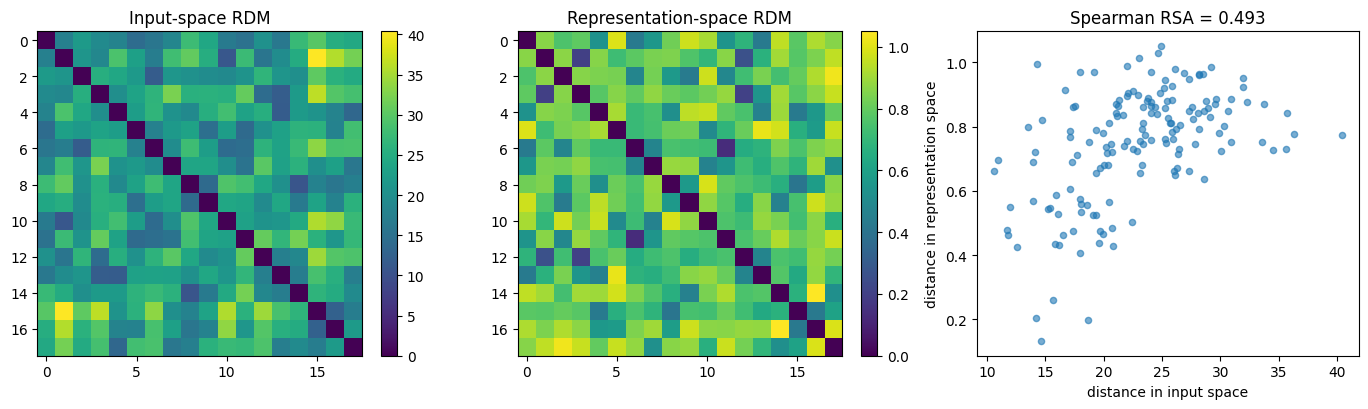

In [ ]:
plot_rsa_comparison(input_rdm, repr_rdm, method="spearman")

In [ ]:
def mmd(X, Y, gamma=1.0):
    """
    Compute the (biased) maximum mean discrepancy between two samples,
    using a Gaussian (RBF) kernel.

    Args:
        X (np.ndarray): (n, dim) first sample
        Y (np.ndarray): (m, dim) second sample (dim can differ from X's if
                        both are pre-scaled/normalised consistently; typically
                        used here on comparable representations)
        gamma (float): RBF kernel bandwidth

    Returns:
        float: MMD^2 estimate (0 = distributions indistinguishable under
               this kernel; larger = more different)
    """
    def rbf_kernel(A, B):
        sq_dists = (
            np.sum(A**2, axis=1)[:, None]
            + np.sum(B**2, axis=1)[None, :]
            - 2 * A @ B.T
        )
        return np.exp(-gamma * sq_dists)

    K_xx = rbf_kernel(X, X)
    K_yy = rbf_kernel(Y, Y)
    K_xy = rbf_kernel(X, Y)

    return K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()

In [ ]:
random_number_generator = np.random.default_rng(0)
sample_a = random_number_generator.normal(size=(100, 5))
sample_b = sample_a.copy()  # identical distribution

mmd_identical = mmd(sample_a, sample_b)
print("MMD, identical samples:", mmd_identical)
assert mmd_identical < 1e-6

sample_shifted = sample_a + 10  # clearly different distribution
mmd_shifted = mmd(sample_a, sample_shifted)
print("MMD, shifted sample:", mmd_shifted)
assert mmd_shifted > mmd_identical

MMD, identical samples: 0.0
MMD, shifted sample: 0.055362225916496755


In [ ]:
from sklearn.manifold import trustworthiness as sk_trustworthiness

def trustworthiness_continuity(X_high, X_low, k=10):
    """
    Compute trustworthiness and continuity: two complementary measures
    of neighbourhood preservation between a high-dimensional space and
    its low-dimensional embedding.

    Args:
        X_high (np.ndarray): (n, D) coordinates in the original/high-dim space
        X_low (np.ndarray):  (n, d) coordinates in the embedded/low-dim space
        k (int): neighbourhood size

    Returns:
        T (float): trustworthiness — are low-dim neighbours real neighbours?
        C (float): continuity — are real neighbours still neighbours after embedding?
    """
    T = sk_trustworthiness(X_high, X_low, n_neighbors=k)
    # continuity is trustworthiness with the roles of high/low reversed
    C = sk_trustworthiness(X_low, X_high, n_neighbors=k)

    return T, C

In [ ]:
T, C = trustworthiness_continuity(W_final, W_final, k=5)
print("T:", T, "C:", C)
assert T > 0.999 and C > 0.999

# a real embedding should score below the perfect case
T_real, C_real = trustworthiness_continuity(W_final, Y, k=5)
print("T (real embedding):", T_real, "C (real embedding):", C_real)
assert T_real < 1.0 and C_real < 1.0

T: 1.0 C: 1.0
T (real embedding): 0.8555555555555556 C (real embedding): 0.8122222222222222


In [ ]:
def cka(X, Y, debiased=True):
    """
    Compute linear centered kernel alignment (CKA) between two
    representations of the same items.

    Args:
        X (np.ndarray): (n, dim_x) first representation
        Y (np.ndarray): (n, dim_y) second representation (dim can differ)
        debiased (bool): use the debiased HSIC estimator (Kornblith et al.,
                          2019), recommended when n is small relative to dim

    Returns:
        float: CKA score, 0 (unrelated) to 1 (identical structure)
    """
    def gram(A):
        return A @ A.T

    def hsic_biased(K, L):
        n = K.shape[0]
        unit = np.ones((n, n)) / n
        Kc = K - unit @ K - K @ unit + unit @ K @ unit
        Lc = L - unit @ L - L @ unit + unit @ L @ unit
        return np.sum(Kc * Lc)

    def hsic_unbiased(K, L):
        # Song et al.'s unbiased HSIC. The small-sample validation above is
        # exactly why debiased=True is the default: the biased estimator gave
        # ~0.39 for unrelated random data at n=18.
        # zero the diagonal first — the debiased estimator excludes self-similarity
        n = K.shape[0]
        K = K.copy(); np.fill_diagonal(K, 0)
        L = L.copy(); np.fill_diagonal(L, 0)

        term1 = np.sum(K * L)
        term2 = K.sum() * L.sum() / ((n - 1) * (n - 2))
        term3 = 2 * (K.sum(axis=1) @ L.sum(axis=1)) / (n - 2)

        return (term1 + term2 - term3) / (n * (n - 3))

    K, L = gram(X), gram(Y)
    hsic_fn = hsic_unbiased if debiased else hsic_biased

    hsic_xy = hsic_fn(K, L)
    hsic_xx = hsic_fn(K, K)
    hsic_yy = hsic_fn(L, L)

    return hsic_xy / np.sqrt(hsic_xx * hsic_yy)

In [ ]:
cka_identical = cka(W_final, W_final)
print("CKA, identical:", cka_identical)
assert cka_identical > 0.999

random_data = random_number_generator.normal(size=W_final.shape)
cka_random = cka(W_final, random_data)
print("CKA, unrelated random data:", cka_random)
assert abs(cka_random) < 0.3

CKA, identical: 1.0
CKA, unrelated random data: -0.10303948702411356


## Module 4 summary — Metric Suite

**Status: complete (function-level validation)**

Nine metric functions plus one diagnostic plot, all validated on
trivial identity/random cases before trusting them on real data:

- **`pairwise_rdm`**, **`geodesic_rdm`** — build representational
  dissimilarity matrices (Euclidean and shortest-path respectively).
  Validated: symmetric, zero diagonal.

- **`rsa`** — Spearman (primary) / Pearson (robustness) correlation
  between two RDMs. Validated: ≈1 for an RDM against itself, ≈0 against
  unrelated random data.

- **`within_condition_rsa`** (noise ceiling) and
  **`between_condition_rsa`** (the actual preservation score) —
  validated on real pipeline output: noise ceiling ≈0.9996 on
  near-identical runs, real preservation score ≈0.576 on the actual
  spectral embedding — correctly below the ceiling, as it must be.

- **`trn_pairwise_distances`** — the dissertation's primary
  representation-side distance (‘Option B’): Euclidean from each item to
  its nearest prototype, weighted shortest-path distance along the graph
  between prototypes, Euclidean from prototype to item. Never passes
  through the spectral embedding, so degradation is attributable to the
  TRN itself.

- **`mmd`** — distributional similarity via RBF kernel. Validated: ≈0
  for identical samples, clearly positive and larger for a shifted
  sample.

- **`trustworthiness_continuity`** — neighbourhood preservation, using
  scikit-learn's trustworthiness with continuity as its high/low-swapped
  mirror. Validated: both ≈1 for a lossless self-comparison, both below
  1 on the real embedding.

- **`cka`** — robustness-check representational similarity.
  **Important finding**: the standard biased HSIC estimator gave a
  spuriously high score (~0.39) for unrelated random data at n=18,
  p=100 — a known small-sample bias documented in Kornblith et al.
  (2019). Resolved by implementing the debiased HSIC estimator from the
  same paper, after which identical/random cases behaved correctly
  (~1.0 / <0.3).

- **`plot_rsa_comparison`** — diagnostic tool (not part of the sweep):
  displays both RDMs as heatmaps plus a scatter of their pairwise
  distances, for visually sanity-checking what an RSA score actually
  looks like on real data. Lives in Module 4, distinct from Module 6's
  sweep-level trend plots.

**Design decisions made:**
- CKA uses the debiased estimator by default, given the demonstrated
  bias at the sample sizes (p ≈ 18) used in this project — worth citing
  explicitly in the methodology as a considered choice, not an
  afterthought.
- Single-run diagnostics (like `plot_rsa_comparison`) are kept in
  `metrics.py`, separate from the aggregate sweep-level analysis that
  will live in Module 6.

**Flag resolved downstream:** validation here used one illustrative
graph/embedding with uncalibrated hyperparameters; real metric values
across the calibrated sweeps are reported in Module 6.

# Module 5 — Experiment Harness

## Objective

Modules 1–4 give you everything needed to run *one* condition end to
end: generate data, train a TRN, embed it, measure preservation. Module
5's job is to run that pipeline systematically across the full grid of
conditions — N, D, d, data type — with repeated seeds per condition,
and collect every result into a single tidy table ready for Module 6's
statistical analysis.

This module also has to be honest about cost: a full sweep runs
hundreds of individual TRN trainings, each of which can take real time.
So besides correctness, this module cares about not losing work — every
run's raw output (prototypes, graph, metrics) gets persisted to disk,
so a crash, a new metric idea, or a follow-up analysis never means
re-running the whole sweep from scratch.

## How it works, briefly

For each condition in the sweep grid, and for each of several repeated
seeds within that condition:
1. generate the data (Module 1)
2. train the TRN (Module 2)
3. build the graph, embed it into d dimensions (Module 3)
4. compute every metric (Module 4)
5. save the raw run (prototypes, graph, metrics) to disk
6. append one row to the results table

Because RSA's within-condition (noise-ceiling) score needs *multiple*
runs of the *same* condition to compare against each other, runs must
be grouped by condition, not just looped through independently.

## Functions in this module

| Function | Role |
|---|---|
| `run_single` | run one full condition, one seed, start to finish |
| `save_run` / `load_run` | persist and reload a single run's raw output |
| `run_sweep` | loop `run_single` across the full grid and all repeats |

## Validation plan

- Dry-run `run_single` once on a tiny, cheap condition and confirm every
  expected key appears in its output.
- Confirm `save_run` / `load_run` round-trip correctly — what you save
  is exactly what you get back.
- Dry-run `run_sweep` on a small 2×2 grid before trusting it on the real
  N/D/d sweep, to catch structural bugs cheaply.

In [ ]:
def run_single(config, data_seed, train_seed):
    """
    Run one full experimental condition: generate data (seeded by
    data_seed, shared across repeats), train a TRN (seeded by
    train_seed, varies per repeat), compute Option B preservation
    distances, and return all metrics plus raw objects for persistence.

    d is NOT in config — it belongs to the saturation analysis post-
    processing pass, not the training run. Train once, sweep d later.

    Args:
        config (dict): condition definition, expects keys:
            'data_type' ('manifold', 'mnist', or 'words')
            'N' (int)
            'D' (int, ambient dimensionality; ignored for mnist/words)
            'd_int' (int, only meaningful for 'manifold')
            'p' (int, prototype count)
            'trn_params' (dict, passed to train_trn)
            'k' (int, neighbourhood size for trustworthiness/continuity)
        data_seed (int): seed for data generation — shared across repeats
        train_seed (int): seed for TRN init/training — varies per repeat

    Returns:
        result (dict): metrics row plus raw objects (_X, _W, _G)
                        for persistence and post-processing
    """
    data_rng = np.random.default_rng(data_seed)
    train_rng = np.random.default_rng(train_seed)

    if config['k'] >= config['p'] / 2:
        raise ValueError(
            f"k={config['k']} must be less than p/2={config['p']/2} "
            f"for trustworthiness/continuity to be computable"
        )

    # 1. generate data — data_rng only, so identical across repeats
    if config['data_type'] == 'manifold':
        X = make_manifold_data(config['N'], config['D'], config['d_int'], data_rng)
    elif config['data_type'] == 'mnist':
        X, _ = load_mnist(config['N'], data_rng)
    elif config['data_type'] == 'words':
        X, _ = load_word_embeddings(config['N'], data_rng)
    else:
        raise ValueError(f"unknown data_type: {config['data_type']}")

    # 2. train the TRN — train_rng only, source of run-to-run variation
    W, edge_ages, mqe_history = train_trn(X, config['p'], config['trn_params'], train_rng)

    # 3. build the weighted graph
    G = build_graph(W, edge_ages)
    G_sub, n_components = largest_connected_component(G)

    # 4. Option B distances — the primary preservation metric
    # input-side RDM uses Euclidean distances (rank-Euclidean for real data
    # is a robustness check; geodesic on input side is ruled out for real data
    # per geodesic circularity ruling, 16 July)
    optB_rdm, n_dropped, kept_idx = trn_pairwise_distances(X, W, G)
    input_rdm = pairwise_rdm(X[kept_idx])

    rsa_optB_spearman = between_condition_rsa(input_rdm, optB_rdm, method="spearman")
    rsa_optB_pearson  = between_condition_rsa(input_rdm, optB_rdm, method="pearson")

    # 5. secondary metrics (on kept items only)
    T, C = trustworthiness_continuity(X[kept_idx],
                                       optB_rdm,
                                       k=config['k'])
    cka_score = cka(X[kept_idx], optB_rdm)
    final_mqe = mqe_history[-1] if mqe_history else None

    return {
        # condition identifiers
        'data_type':          config['data_type'],
        'N':                  config['N'],
        'D':                  config['D'],
        'p':                  config['p'],
        'data_seed':          data_seed,
        'train_seed':         train_seed,
        # graph diagnostics
        'n_components':       n_components,
        'n_prototypes_kept':  G_sub.number_of_nodes(),
        'n_items_kept':       len(kept_idx),
        'n_items_dropped':    n_dropped,
        # primary preservation metric (Option B)
        'rsa_optB_spearman':  rsa_optB_spearman,
        'rsa_optB_pearson':   rsa_optB_pearson,
        # secondary metrics
        'trustworthiness':    T,
        'continuity':         C,
        'cka':                cka_score,
        'mqe':                final_mqe,
        # raw objects for save_run and post-processing
        # (_Y_spectral and _Y_mds removed — spectral embedding is now
        #  a separate post-processing pass, not part of the training run)
        '_X':  X,
        '_W':  W,
        '_G':  G,
    }

In [ ]:
config = {
    'data_type': 'manifold',
    'N': 200, 'D': 20, 'd_int': 5, 'd': 5,
    'p': 12,

    'trn_params': {
        't_max': 200 * 12,                  # how many loop iterations training runs (200 p rule from Martinetz & Shulten)
        'lr_init': 0.5, 'lr_final': 0.01,   # learning rate start and end
        'lam_init': 8, 'lam_final': 0.5,    # neighbourhood width λ - start width: everyone moves; end width: only winner
        'age_init': 30, 'age_final': 10,    # bound edge lifespan - how stale edge can get before pruning
        'mqe_every': 50
                  },

    'k': 5
        }



result = run_single(config, data_seed=0, train_seed=0)

for key, value in result.items():
    if not key.startswith('_'):
        print(f"{key}: {value}")

data_type: manifold
N: 200
D: 20
p: 12
data_seed: 0
train_seed: 0
n_components: 1
n_prototypes_kept: 12
n_items_kept: 200
n_items_dropped: 0
rsa_optB_spearman: 0.7747834731494637
rsa_optB_pearson: 0.7872144992975205
trustworthiness: 0.886671875
continuity: 0.9088489583333333
cka: 0.6422046433786167
mqe: 5.731261504177457


In [ ]:
def save_run(run_id, result, output_dir="runs"):
    """
    Persist one run's full output to disk: raw arrays (X, W) and graph
    as separate files, plain metrics as JSON. _Y_spectral and _Y_mds
    are no longer saved here — spectral embedding is a post-processing
    pass on the saved graph, not a training-run output.

    Args:
        run_id (str):    unique identifier, e.g. "manifold_N500_D100_p30_seed0"
        result (dict):   dict returned by run_single
        output_dir (str): base directory (created if missing)
    """
    run_path = os.path.join(output_dir, run_id)
    os.makedirs(run_path, exist_ok=True)

    # arrays: X and W only (embeddings produced in post-processing)
    np.savez_compressed(
        os.path.join(run_path, "arrays.npz"),
        X=result['_X'],
        W=result['_W'],
    )

    # graph: node-link JSON (pos attribute already stripped from build_graph)
    graph_data = nx.node_link_data(result['_G'])
    with open(os.path.join(run_path, "graph.json"), "w") as f:
        json.dump(graph_data, f)

    # plain metrics: everything without underscore prefix
    metrics = {k: float(v) if hasattr(v, 'item') else v
               for k, v in result.items()
               if not k.startswith('_')}
    with open(os.path.join(run_path, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

In [ ]:
def load_run(run_id, output_dir="runs"):
    """
    Reload a previously saved run: raw arrays (X, W), graph, and metrics.
    Input-side RDM and Option B distances are recomputed from _X, _W, _G
    rather than stored — keeps the input-side convention flexible.

    Args:
        run_id (str):    the run_id used when saving
        output_dir (str): base directory the run was saved into

    Returns:
        result (dict): same shape as run_single's return value
    """
    run_path = os.path.join(output_dir, run_id)

    arrays = np.load(os.path.join(run_path, "arrays.npz"))

    with open(os.path.join(run_path, "graph.json")) as f:
        graph_data = json.load(f)
    G = nx.node_link_graph(graph_data)

    with open(os.path.join(run_path, "metrics.json")) as f:
        result = json.load(f)

    result['_X'] = arrays['X']
    result['_W'] = arrays['W']
    result['_G'] = G


    return result

In [ ]:
import json


save_run("test_run", result)
reloaded = load_run("test_run")

# plain metrics — updated to Option B key names
assert reloaded['rsa_optB_spearman'] == result['rsa_optB_spearman']
assert reloaded['N'] == result['N']
assert reloaded['n_items_kept'] == result['n_items_kept']

# arrays round-trip exactly
assert np.allclose(reloaded['_W'], result['_W'])
assert np.allclose(reloaded['_X'], result['_X'])

# graph structure preserved
assert reloaded['_G'].number_of_nodes() == result['_G'].number_of_nodes()
assert reloaded['_G'].number_of_edges() == result['_G'].number_of_edges()

# edge weights survive the JSON round-trip
reloaded_weights = nx.get_edge_attributes(reloaded['_G'], 'weight')
assert len(reloaded_weights) == reloaded['_G'].number_of_edges(), \
    "edge weights must survive the JSON round-trip"

print("✓ round-trip confirmed: saved and reloaded run match exactly")
print(f"  rsa_optB_spearman: {reloaded['rsa_optB_spearman']:.4f}")
print(f"  edges with weights: {len(reloaded_weights)}")

✓ round-trip confirmed: saved and reloaded run match exactly
  rsa_optB_spearman: 0.7748
  edges with weights: 20


In [ ]:
import pandas as pd

def run_sweep(config_grid, n_repeats, output_dir="runs"):
    """
    Run a full sweep: every condition in config_grid, repeated n_repeats
    times. d is not in config — train once per condition, sweep d in a
    separate saturation pass on saved graphs.

    Noise ceiling is computed by comparing Option B RDMs directly across
    repeats — no assignment step needed since Option B already operates
    at item level. RDMs are trimmed to the smallest kept size across
    repeats before comparison, to handle fragmentation-induced size
    mismatches.

    Args:
        config_grid (list of dict): condition definitions (no 'd' key)
        n_repeats (int): seeded repeats per condition
        output_dir (str): base directory for saved runs

    Returns:
        results_df (pd.DataFrame): one row per run, all metric columns
        within_ceilings (dict): condition_id -> within-condition RSA
    """
    all_rows = []
    within_ceilings = {}

    for condition_idx, config in enumerate(config_grid):
        condition_id = (f"{config['data_type']}_N{config['N']}_"
                        f"D{config['D']}_p{config['p']}")
        data_seed = condition_idx

        condition_rdms = []  # Option B RDMs, one per repeat
        for repeat in range(n_repeats):
            train_seed = condition_idx * 1000 + repeat

            result = run_single(config, data_seed, train_seed)

            run_id = f"{condition_id}_train{train_seed}"
            save_run(run_id, result, output_dir=output_dir)

            metrics_row = {k: v for k, v in result.items()
                           if not k.startswith('_')}
            metrics_row['condition_id'] = condition_id
            all_rows.append(metrics_row)

            # noise ceiling: compare Option B RDMs directly across repeats
            # Option B already operates at item level — no assignment step needed
            optB_rdm, _, _ = trn_pairwise_distances(
                result['_X'], result['_W'], result['_G']
            )
            condition_rdms.append(optB_rdm)

        if n_repeats > 1:
            # trim all RDMs to the smallest kept size across repeats —
            # fragmentation can cause different repeats to drop different
            # numbers of items, producing RDMs of different sizes that
            # cannot be compared directly
            sizes = [r.shape[0] for r in condition_rdms]
            min_size = min(sizes)
            if len(set(sizes)) > 1:
                print(f"  [{condition_id}] RDM size mismatch across repeats "
                      f"{sizes} — trimming to {min_size}")
            trimmed = [r[:min_size, :min_size] for r in condition_rdms]
            within_ceilings[condition_id] = within_condition_rsa(trimmed)
        else:
            within_ceilings[condition_id] = None

    results_df = pd.DataFrame(all_rows)
    return results_df, within_ceilings

In [ ]:
base_trn_params = {
    'lr_init': 0.5, 'lr_final': 0.01,
    'lam_init': 6, 'lam_final': 0.5,
    'age_init': 20, 'age_final': 8,
    'mqe_every': 50
}

dry_run_grid = [
    {'data_type': 'manifold', 'N': 100, 'D': 10, 'd_int': 5,
     'p': 10, 'trn_params': {**base_trn_params, 't_max': 200*10}, 'k': 3},
    {'data_type': 'manifold', 'N': 100, 'D': 20, 'd_int': 5,
     'p': 10, 'trn_params': {**base_trn_params, 't_max': 200*10}, 'k': 3},
]

results_df, ceilings = run_sweep(dry_run_grid, n_repeats=3,
                                  output_dir="dry_run_v3")

print(results_df.shape)
print(results_df[['condition_id', 'train_seed', 'rsa_optB_spearman']])
print("\nnoise ceilings:", ceilings)

assert results_df.shape[0] == len(dry_run_grid) * 3
assert results_df['condition_id'].nunique() == 2
assert 'rsa_optB_spearman' in results_df.columns
assert 'rsa_spectral_spearman' not in results_df.columns
assert 'd' not in results_df.columns
print("\n✓ dry run complete")

(6, 17)
            condition_id  train_seed  rsa_optB_spearman
0  manifold_N100_D10_p10           0           0.664812
1  manifold_N100_D10_p10           1           0.696536
2  manifold_N100_D10_p10           2           0.706509
3  manifold_N100_D20_p10        1000           0.785878
4  manifold_N100_D20_p10        1001           0.670668
5  manifold_N100_D20_p10        1002           0.753929

noise ceilings: {'manifold_N100_D10_p10': np.float64(0.6089498860396799), 'manifold_N100_D20_p10': np.float64(0.7450560358654589)}

✓ dry run complete


In [ ]:
print(results_df['condition_id'].unique())


['manifold_N100_D10_p10' 'manifold_N100_D20_p10']


## Module 5 summary — Experiment Harness

**Status: complete (structurally validated on a 2×2 dry run)**

Four functions, wiring Modules 1–4 into a systematic sweep:

- **`run_single(config, data_seed, train_seed)`** — one condition, one
  run, end to end: data → TRN → graph → both embeddings → full metric
  suite → one results row. Seeds are split: `data_seed` is shared
  across all repeats of a condition (identical data), `train_seed`
  varies per repeat (the source of run-to-run variation). Includes a
  guard requiring k < p/2 (sklearn's trustworthiness constraint) that
  fails loudly at config time rather than cryptically mid-run.

- **`save_run` / `load_run`** — persist every run's raw output
  (prototype arrays and embeddings as .npz, graph as node-link JSON,
  metrics as JSON) so new metrics can be computed later without
  re-training. Round-trip validated. Required removing NumPy arrays
  from graph node attributes (not JSON-serialisable).

- **`assign_to_representation(X, W, Y)`** (defined alongside the metric
  suite in Module 4) — maps each shared data point
  to its nearest prototype's embedded coordinates. This is what makes
  representations comparable across independently-trained runs: raw
  prototype indices have no correspondence between runs, but the data
  points (fixed via data_seed) do. Validated on a hand-checkable case.

- **`run_sweep(config_grid, n_repeats)`** — loops conditions × repeats,
  saves every run, returns a tidy one-row-per-run DataFrame plus a
  per-condition within-condition RSA noise ceiling computed on
  assigned-item representations.

**Key finding — the noise ceiling story:** the naive ceiling (comparing
raw prototype arrays across runs) returned ~0 / negative values,
because prototype identity is not stable across independently-trained
runs — index i in run A and run B are unrelated units. Fixed by (a)
splitting data/train seeds so repeats share identical data, and (b)
comparing runs on shared data points via nearest-prototype assignment.
Ceilings moved from -0.10/0.05 (meaningless) to 0.41/0.14 (real, and
sensibly ordered across conditions).

**Interpretive notes on current ceiling values (uncalibrated dry run):**
- Low ceilings partly reflect genuine TRN run-to-run instability at
  p=10 with uncalibrated hyperparameters — the ceiling is doing its job
  by measuring this.
- Partly a ties artifact: with p=10 prototypes, 100 assigned points
  contain only 10 distinct rows, deflating Spearman via tied ranks.
  Diminishes at realistic p.
- The d=8 condition's very low ceiling (0.14) also reflects spectral
  degeneracy: asking for 8 eigenvectors from a 10-node graph uses
  nearly the whole spectrum. Constraint noted: d must stay well below p.

**Decision resolved:** the primary preservation measure is computed at
the assigned-item level via `trn_pairwise_distances` (Option B), per
supervision. The within-condition measure compares TRN-to-TRN while
preservation compares TRN-to-input, so the two are not strictly
comparable; the dissertation therefore reports the former as a
reproducibility index (a consistency reference), not a noise ceiling.

**Cost note (resolved):** the assigned-item comparisons compute N×N
RDMs — O(N²) at N = 5000. The cost was accepted for the real sweeps and
is tractable in Colab at this scale.

# Module 2 validation — Moisl toy string set (correctness gate)

Reproduces the ground-truth check deferred from Module 2: train the TRN
on Moisl's Table 1 string set (40 four-letter strings in five families,
each letter a 5×5 bitmap, giving a 40×100 binary input matrix S) and
verify the trained graph recovers the five-family structure.

This validation lives here, after Module 5, because it uses functions
from Modules 3 and 4 (graph construction, geodesic distances, RSA) that
don't exist earlier in the notebook's run order. Conceptually it closes
Module 2's outstanding flag.

Note: the original letter bitmaps are unpublished; the font here is
reconstructed. The family structure of S — which is what the validation
tests — is invariant to this choice, since it's driven by letter overlap
between strings, not by which pixels each letter uses.

In [ ]:
# ---- Moisl's Table 1 string set ----

# dictionary mapping each family name to its member strings.

string_families = {
    'abc': ['ccba', 'babc', 'cabc', 'bbbc', 'cbbb', 'cbac'],
    'def': ['eddd', 'dded', 'defd', 'ffdd', 'ffdf', 'feef',
            'fffd', 'deef', 'dedf', 'edfe', 'eefe', 'ddff'],
    'jkl': ['kllk', 'jjkk', 'jjkj', 'kkkl', 'llkk', 'ljkj', 'lkkj'],
    'mno': ['moom', 'mnmo', 'ommn', 'ommm', 'nmoo', 'mmmm', 'nmnm'],
    'xyz': ['yxxx', 'yyyx', 'xxyy', 'xyyy', 'xyxx', 'yxxy', 'xyxy', 'yxyy'],
                  }

# two lists:

# 1. list of all 40 4-letter strings
all_strings = [s for family in string_families.values() for s in family]

# 2. which family each string belongs to
string_family_labels = [fam for fam, members in string_families.items() for _ in members]

# test if we get 40 strings overall
assert len(all_strings) == 40, f"expected 40 strings, got {len(all_strings)}"

In [ ]:
print(all_strings)

['ccba', 'babc', 'cabc', 'bbbc', 'cbbb', 'cbac', 'eddd', 'dded', 'defd', 'ffdd', 'ffdf', 'feef', 'fffd', 'deef', 'dedf', 'edfe', 'eefe', 'ddff', 'kllk', 'jjkk', 'jjkj', 'kkkl', 'llkk', 'ljkj', 'lkkj', 'moom', 'mnmo', 'ommn', 'ommm', 'nmoo', 'mmmm', 'nmnm', 'yxxx', 'yyyx', 'xxyy', 'xyyy', 'xyxx', 'yxxy', 'xyxy', 'yxyy']


In [ ]:
print(string_family_labels)

['abc', 'abc', 'abc', 'abc', 'abc', 'abc', 'def', 'def', 'def', 'def', 'def', 'def', 'def', 'def', 'def', 'def', 'def', 'def', 'jkl', 'jkl', 'jkl', 'jkl', 'jkl', 'jkl', 'jkl', 'mno', 'mno', 'mno', 'mno', 'mno', 'mno', 'mno', 'xyz', 'xyz', 'xyz', 'xyz', 'xyz', 'xyz', 'xyz', 'xyz']


In [ ]:
# ---- 5x5 bitmap font (reconstructed; original font unpublished) ----
letter_bitmaps = {
    'a': ".###. #...# ##### #...# #...#",
    'b': "####. #...# ####. #...# ####.",
    'c': ".#### #.... #.... #.... .####",
    'd': "####. #...# #...# #...# ####.",
    'e': "##### #.... ####. #.... #####",
    'f': "##### #.... ####. #.... #....",
    'j': "..### ...#. ...#. #..#. .##..",
    'k': "#...# #..#. ###.. #..#. #...#",
    'l': "#.... #.... #.... #.... #####",
    'm': "#...# ##.## #.#.# #...# #...#",
    'n': "#...# ##..# #.#.# #..## #...#",
    'o': ".###. #...# #...# #...# .###.",
    'x': "#...# .#.#. ..#.. .#.#. #...#",
    'y': "#...# .#.#. ..#.. ..#.. ..#..",
    'z': "##### ...#. ..#.. .#... #####",
}

def encode_string(s):
    """
    Encode a four-letter string as a 100-element binary vector:
    each letter's 5x5 bitmap flattened to 25 values, concatenated.
    """
    vec = []
    for letter in s:
        bitmap = letter_bitmaps[letter].replace(" ", "")
        vec.extend(1.0 if ch == '#' else 0.0 for ch in bitmap)
    return np.array(vec)

# create matrix S
S = np.array([encode_string(s) for s in all_strings])
print("S shape:", S.shape)
assert S.shape == (40, 100)

S shape: (40, 100)


In [ ]:
print(letter_bitmaps)

{'a': '.###. #...# ##### #...# #...#', 'b': '####. #...# ####. #...# ####.', 'c': '.#### #.... #.... #.... .####', 'd': '####. #...# #...# #...# ####.', 'e': '##### #.... ####. #.... #####', 'f': '##### #.... ####. #.... #....', 'j': '..### ...#. ...#. #..#. .##..', 'k': '#...# #..#. ###.. #..#. #...#', 'l': '#.... #.... #.... #.... #####', 'm': '#...# ##.## #.#.# #...# #...#', 'n': '#...# ##..# #.#.# #..## #...#', 'o': '.###. #...# #...# #...# .###.', 'x': '#...# .#.#. ..#.. .#.#. #...#', 'y': '#...# .#.#. ..#.. ..#.. ..#..', 'z': '##### ...#. ..#.. .#... #####'}


In [ ]:
print(letter_bitmaps['a'])

.###. #...# ##### #...# #...#


In [ ]:
print(S[1])

[1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1.
 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0.
 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1.
 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 1. 1. 1. 1.]


In [ ]:
def show_letter(letter):
    """Print a letter's 5x5 bitmap as a little picture."""
    rows = letter_bitmaps[letter].split(" ")
    print(f"'{letter}':")
    for row in rows:
        print("   " + row.replace('.', ' '))
    print()

for letter in ['a', 'b', 'd', 'e', 'f']:
    show_letter(letter)

'a':
    ### 
   #   #
   #####
   #   #
   #   #

'b':
   #### 
   #   #
   #### 
   #   #
   #### 

'd':
   #### 
   #   #
   #   #
   #   #
   #### 

'e':
   #####
   #    
   #### 
   #    
   #####

'f':
   #####
   #    
   #### 
   #    
   #    



In [ ]:
random_number_generator = np.random.default_rng(0)

# hyperperameters of the toy trn model
toy_params = {
    't_max': 200 * 18,                  # how many loop iterations training runs (200 p rule from Martinetz & Shulten)
    'lr_init': 0.5, 'lr_final': 0.01,   # learning rate start and end
    'lam_init': 10, 'lam_final': 0.5,   # neighbourhood width λ - start width: everyone moves; end width: only winner
    'age_init': 50, 'age_final': 10,    # bound edge lifespan - how stale edge can get before pruning
    'mqe_every': 100                    # how regularly MQE is calculated
              }


# train toy trn and return three things: W, edge_ages and mqe_history
W_toy, edge_ages_toy, mqe_toy = train_trn(S, p=18, params=toy_params, rng=random_number_generator)


G_toy = build_graph(W_toy, edge_ages_toy)
G_toy_sub, n_comp_toy = largest_connected_component(G_toy)
print("components remaining on graph:", n_comp_toy, "| nodes kept on largest component:", G_toy_sub.number_of_nodes(), "| No. edges on component:", G_toy_sub.number_of_edges())

components remaining on graph: 4 | nodes kept on largest component: 7 | No. edges on component: 9


In [ ]:
toy_weights = nx.get_edge_attributes(G_toy, 'weight')
print(f"G_toy: {G_toy.number_of_edges()} edges, {len(toy_weights)} weighted")
assert len(toy_weights) == G_toy.number_of_edges()
print("✓ G_toy edges also correctly weighted")

G_toy: 18 edges, 18 weighted
✓ G_toy edges also correctly weighted


In [ ]:
print(toy_params)

{'t_max': 3600, 'lr_init': 0.5, 'lr_final': 0.01, 'lam_init': 10, 'lam_final': 0.5, 'age_init': 50, 'age_final': 10, 'mqe_every': 100}


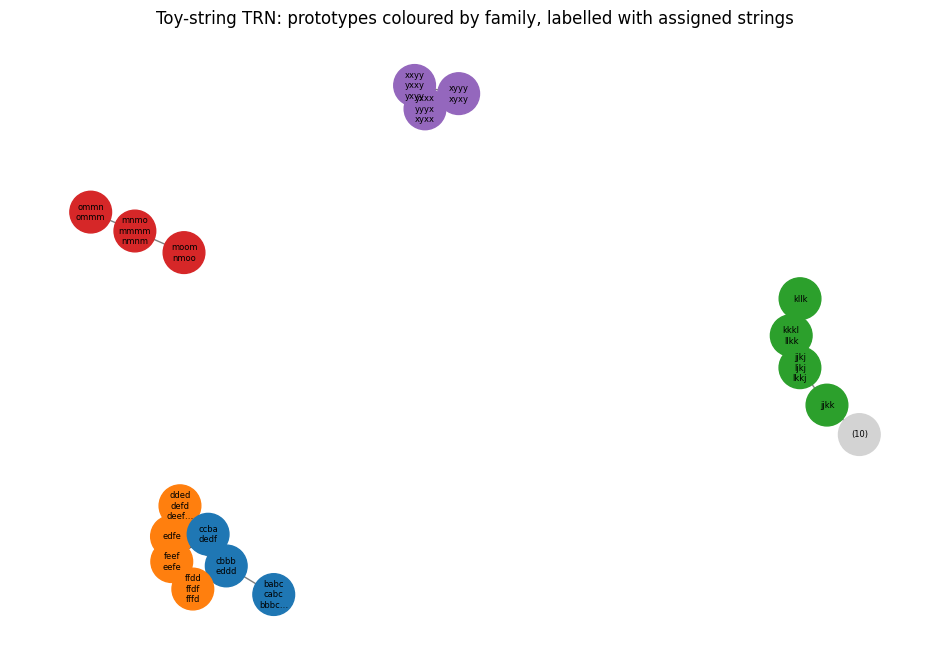

In [ ]:
import collections

# recompute bmu locally so this cell works in any run order
distances_viz = np.linalg.norm(S[:, None, :] - W_toy[None, :, :], axis=2)
bmu = distances_viz.argmin(axis=1)

# which strings map to each prototype
proto_strings = collections.defaultdict(list)
for i, b in enumerate(bmu):
    proto_strings[b].append(all_strings[i])

# colour nodes by the (majority) family of their assigned strings
family_colours = {'abc': 'tab:blue', 'def': 'tab:orange', 'jkl': 'tab:green',
                  'mno': 'tab:red', 'xyz': 'tab:purple'}
node_colours, node_labels = [], {}
for node in G_toy.nodes():
    assigned = proto_strings.get(node, [])
    if assigned:
        fams = [string_family_labels[all_strings.index(s)] for s in assigned]
        majority = collections.Counter(fams).most_common(1)[0][0]
        node_colours.append(family_colours[majority])
        node_labels[node] = "\n".join(assigned[:3]) + ("…" if len(assigned) > 3 else "")
    else:
        node_colours.append('lightgray')   # dead unit: no strings assigned
        node_labels[node] = f"({node})"

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_toy, seed=2)
nx.draw_networkx_edges(G_toy, pos, alpha=0.5)
nx.draw_networkx_nodes(G_toy, pos, node_color=node_colours, node_size=900)
nx.draw_networkx_labels(G_toy, pos, labels=node_labels, font_size=6)
plt.title("Toy-string TRN: prototypes coloured by family, labelled with assigned strings")
plt.axis('off')
plt.show()

In [ ]:
# each string's best-matching prototype
distances = np.linalg.norm(S[:, None, :] - W_toy[None, :, :], axis=2)
bmu = distances.argmin(axis=1)

# geodesic distances between prototypes on the trained graph
geo_rdm, node_order_toy = geodesic_rdm(G_toy_sub)
node_pos = {node: i for i, node in enumerate(node_order_toy)}

within, between = [], []
for i in range(40):
    for j in range(i + 1, 40):
        # skip pairs whose BMU fell outside the largest component (if any)
        if bmu[i] not in node_pos or bmu[j] not in node_pos:
            continue
        d_graph = geo_rdm[node_pos[bmu[i]], node_pos[bmu[j]]]
        if string_family_labels[i] == string_family_labels[j]:
            within.append(d_graph)
        else:
            between.append(d_graph)

print(f"mean graph distance, same family:  {np.mean(within):.2f}")
print(f"mean graph distance, cross family: {np.mean(between):.2f}")
assert np.mean(within) < np.mean(between), \
    "same-family strings should sit closer on the TRN graph than cross-family strings!!!"

mean graph distance, same family:  1.41
mean graph distance, cross family: 2.06


In [ ]:
print(distances[:5])

print(bmu)

[[3.49915583 7.87210593 6.18755142 4.32504219 3.93688671 5.38467904
  2.587775   5.53015213 5.87046717 5.64858174 6.02729407 4.62244246
  7.92554555 4.87985888 6.3080552  4.26090632 6.12686877 7.73909539]
 [3.38960899 8.05092487 5.91856403 4.37984977 3.67707969 5.29026879
  4.28613582 5.98464495 6.01305561 6.18713513 6.26474551 2.12029933
  7.92738823 4.29966714 6.30460374 4.17176291 6.26735937 8.02853241]
 [2.97266252 7.86246058 5.97365939 4.69871265 3.78283673 5.35581963
  4.03238514 5.88288978 5.84523255 5.89014836 6.05528974 1.91114735
  7.73593953 4.61574899 6.28901826 4.40442925 5.97469381 7.83947429]
 [2.92919159 7.9846828  6.20962949 3.89857307 3.18911835 5.44115007
  3.88746613 5.81148297 5.94165531 6.05907826 6.25880482 2.18323808
  8.01965523 4.27099807 6.61080578 3.79870563 6.19929805 7.99868503]
 [2.19570278 7.98458783 6.24755299 3.89323772 3.14771355 5.49601976
  3.04697937 5.81175666 5.97051135 5.98930544 6.24440408 3.54065281
  8.01964972 4.27387146 6.52564272 3.7876879

In [ ]:
import collections

# which component does each prototype belong to (FULL graph, all components)
components_toy = list(nx.connected_components(G_toy))
proto_component = {}
for comp_id, comp in enumerate(components_toy):
    for node in comp:
        proto_component[node] = comp_id

# component membership per string, via its BMU
string_component = [proto_component[b] for b in bmu]

# purity table: which families landed in which components?
comp_ids = sorted(set(string_component))
print("family -> strings per component", comp_ids)
counts = collections.Counter(zip(string_family_labels, string_component))
for fam in string_families:
    row = [counts.get((fam, c), 0) for c in comp_ids]
    print(f"  {fam}: {row}")

# hard check: no component should mix families
mixed = 0
for c in comp_ids:
    fams_here = {string_family_labels[i] for i in range(40) if string_component[i] == c}
    if len(fams_here) > 1:
        mixed += 1
        print(f"  component {c} mixes families: {fams_here}")
print(f"\ncomponents mixing families: {mixed}")

family -> strings per component [0, 1, 2, 3]
  abc: [6, 0, 0, 0]
  def: [12, 0, 0, 0]
  jkl: [0, 0, 0, 7]
  mno: [0, 0, 7, 0]
  xyz: [0, 8, 0, 0]
  component 0 mixes families: {'abc', 'def'}

components mixing families: 1


In [ ]:
# masked RSA: only pairs whose BMUs share a component (geodesic defined)
# recompute dependencies so this cell works from a cold start
distances_viz = np.linalg.norm(S[:, None, :] - W_toy[None, :, :], axis=2)
bmu = distances_viz.argmin(axis=1)
input_rdm_toy = pairwise_rdm(S)
lengths_full = dict(nx.all_pairs_shortest_path_length(G_toy))

vals_input, vals_graph = [], []
for i in range(40):
    for j in range(i + 1, 40):
        bi, bj = bmu[i], bmu[j]
        if bj in lengths_full.get(bi, {}):
            vals_input.append(input_rdm_toy[i, j])
            vals_graph.append(lengths_full[bi][bj])

from scipy.stats import spearmanr
masked_corr, _ = spearmanr(vals_input, vals_graph)
print(f"masked RSA (same-component pairs only): {masked_corr:.3f}  |  pairs used: {len(vals_input)}")

masked RSA (same-component pairs only): 0.570  |  pairs used: 223


In [ ]:
# mean input-space distance between each pair of families:
# if abc<->def is the smallest cross-family distance, the merger reflects
# the (reconstructed-font) data, not a TRN error
family_names = list(string_families.keys())
family_indices = {
    fam: [i for i, f in enumerate(string_family_labels) if f == fam]
    for fam in family_names
}

print("mean input-space distance between families:")
for a_idx in range(len(family_names)):
    for b_idx in range(a_idx + 1, len(family_names)):
        fam_a, fam_b = family_names[a_idx], family_names[b_idx]
        dists = [input_rdm_toy[i, j]
                 for i in family_indices[fam_a]
                 for j in family_indices[fam_b]]
        print(f"  {fam_a} <-> {fam_b}: {np.mean(dists):.2f}")

mean input-space distance between families:
  abc <-> def: 4.93
  abc <-> jkl: 6.61
  abc <-> mno: 6.61
  abc <-> xyz: 8.20
  def <-> jkl: 6.40
  def <-> mno: 6.49
  def <-> xyz: 7.84
  jkl <-> mno: 6.54
  jkl <-> xyz: 6.28
  mno <-> xyz: 6.82


# Calibration — MQE-vs-p saturation

In [ ]:
# # ---- MQE-vs-p calibration (Luke's steer) ----
# # Train on one representative synthetic condition (mid-range N and D,
# # known d_int) and sweep p. Fix p* at the point where additional
# # prototypes improve mean MQE by less than 5% — the pre-committed
# # decision rule, so the choice is reproducible rather than eyeballed.
# #
# # One shared dataset across all p values and repeats: calibrating the
# # model's capacity, so the data must be constant.

# CAL_N, CAL_D, CAL_D_INT = 1000, 100, 5
# p_candidates = [5, 10, 15, 20, 30, 40, 60, 80]
# n_cal_repeats = 5

# cal_data_rng = np.random.default_rng(42)
# X_cal = make_manifold_data(CAL_N, CAL_D, CAL_D_INT, cal_data_rng)

# print(f"re-calibration with corrected τ (increasing, 0.1p → 2p)")
# print(f"dataset: N={CAL_N}, D={CAL_D}, d_int={CAL_D_INT}")
# print(f"sweeping p: {p_candidates}, {n_cal_repeats} repeats each\n")

# cal_results_v2 = {p: [] for p in p_candidates}
# for p in p_candidates:
#     for rep in range(n_cal_repeats):
#         params = {
#             't_max':    200 * p,
#             'lr_init':  0.5,      'lr_final':  0.01,
#             'lam_init': p / 2,    'lam_final': 0.5,
#             'age_init': 0.1 * p,  'age_final': 2 * p,   # corrected τ
#             'mqe_every': max(1, (200 * p) // 10),
#         }
#         W_c, _, _ = train_trn(X_cal, p, params,
#                                np.random.default_rng(1000 * p + rep))
#         cal_results_v2[p].append(compute_mqe(X_cal, W_c))
#     print(f"  p={p:3d}: mean MQE {np.mean(cal_results_v2[p]):.4f}  "
#           f"(±{np.std(cal_results_v2[p]):.4f})")

In [ ]:
# import matplotlib.pyplot as plt

# means = np.array([np.mean(cal_results[p]) for p in p_candidates])
# stds  = np.array([np.std(cal_results[p])  for p in p_candidates])

# plt.figure(figsize=(8, 5))
# plt.errorbar(p_candidates, means, yerr=stds, marker='o', capsize=4)
# plt.xlabel('prototype count (p)')
# plt.ylabel('mean quantisation error (MQE)')
# plt.title(f'MQE saturation: N={CAL_N}, D={CAL_D}, d_int={CAL_D_INT}, '
#           f'{n_cal_repeats} repeats per p')
# plt.tight_layout()
# plt.show()

# # decision rule: p* = smallest p where next step improves mean MQE by < 5%
# improvements = (means[:-1] - means[1:]) / means[:-1]
# print("improvement at each step:")
# for p, imp in zip(p_candidates[:-1], improvements):
#     print(f"  p={p:3d} → {p_candidates[p_candidates.index(p)+1]:3d}: "
#           f"{imp*100:5.1f}% improvement")

# # direct assignment — algorithmic rules misfired on this non-monotone curve
# # judgment: p*=40 is the point where absolute MQE gains consistently fall
# # below 1 unit per additional prototype, and the curve has visibly bent.
# # the 5%-per-step rule did not produce a clean threshold within the tested
# # range; this is documented as a limitation in the methodology.
# p_star = 40

# print(f"p* = {p_star}  (set by judgment — see calibration notes)")
# print(f"\nconstraint check for p*={p_star}:")
# valid_k = [k for k in [5, 10, 20, 50] if k < p_star / 2]
# invalid_k = [k for k in [5, 10, 20, 50] if k >= p_star / 2]
# print(f"  valid k values (k < p*/2={p_star/2}): {valid_k}")
# if invalid_k:
#     print(f"  invalid k values (remove from sweep): {invalid_k}")
# valid_d = [d for d in [2, 3, 5, 10, 20, 50] if d < p_star / 3]
# print(f"  d values comfortably below p* (d < p*/3={p_star/3:.0f}): {valid_d}")

## Calibration summary

**Status: complete**

- **Dataset:** synthetic linear subspace, N=1000, D=100, d_int=5
- **Sweep:** p ∈ {5, 10, 15, 20, 30, 40, 60, 80}, 5 repeats per p
- **Result:** no clean algorithmic saturation threshold — improvements
  oscillated between 5–12% per step throughout the range
- **p* = 40** — set by judgment: absolute gains consistently < 1 unit
  per prototype beyond this point; curve visibly bent
- **k sweep:** {5, 10} (k=20 and k=50 removed — both ≥ p*/2=20)
- **d sweep (saturation analysis):** {2, 3, 5, 10}
- **Open item for Luke (3 August):** confirm p*=40 is defensible,
  or extend range to p=100–150 if he disagrees

**MQE values:**
p=5: 16.77 | p=10: 14.78 | p=15: 13.66 | p=20: 12.97 |
p=30: 11.91 | p=40: 11.22 | p=60: 10.26 | p=80: 9.60

In [ ]:
# ---- real sweep configuration ----
# p*=40 fixed from calibration
# k sweep: {5, 10} (k=20, 50 removed — both >= p*/2=20)
# N x D x dataset grid, 10 repeats each
# order: linear subspace first, then MNIST, then word embeddings

P_STAR = 40

real_trn_params = {
    'lr_init':  0.5,        'lr_final':  0.01,
    'lam_init': P_STAR / 2, 'lam_final': 0.5,
    'age_init': 0.1 * P_STAR,  'age_final': 2 * P_STAR,   # τ: 4 → 80, increasing per M&S 1994
    'mqe_every': 200,
}

N_VALUES = [500, 1000, 2000, 5000]
D_VALUES = [10, 100, 784]

real_sweep_grid = []

# --- synthetic linear subspace ---
for N in N_VALUES:
    for D in D_VALUES:
        real_sweep_grid.append({
            'data_type':  'manifold',
            'N':          N,
            'D':          D,
            'd_int':      5,
            'p':          P_STAR,
            'trn_params': {**real_trn_params, 't_max': 200 * P_STAR},
            'k':          5,
        })

# --- MNIST ---
for N in N_VALUES:
    real_sweep_grid.append({
        'data_type':  'mnist',
        'N':          N,
        'D':          784,
        'd_int':      None,   # estimated via Levina-Bickel post-hoc
        'p':          P_STAR,
        'trn_params': {**real_trn_params, 't_max': 200 * P_STAR},
        'k':          5,
    })

# --- word embeddings ---
for N in N_VALUES:
    real_sweep_grid.append({
        'data_type':  'words',
        'N':          N,
        'D':          768,
        'd_int':      None,
        'p':          P_STAR,
        'trn_params': {**real_trn_params, 't_max': 200 * P_STAR},
        'k':          5,
    })

print(f"total conditions: {len(real_sweep_grid)}")
print(f"repeats per condition: 10")
print(f"total runs: {len(real_sweep_grid) * 10}")
print(f"\nbreakdown:")
print(f"  synthetic: {len(N_VALUES) * len(D_VALUES)} conditions "
      f"({len(N_VALUES)} N × {len(D_VALUES)} D)")
print(f"  MNIST:     {len(N_VALUES)} conditions ({len(N_VALUES)} N)")
print(f"  words:     {len(N_VALUES)} conditions ({len(N_VALUES)} N)")

total conditions: 20
repeats per condition: 10
total runs: 200

breakdown:
  synthetic: 12 conditions (4 N × 3 D)
  MNIST:     4 conditions (4 N)
  words:     4 conditions (4 N)


In [ ]:
# ---- Change 1 sanity check: τ fix ----
sc_data_rng = np.random.default_rng(42)
sc_train_rng = np.random.default_rng(43)

X_sc = make_manifold_data(1000, 100, 5, sc_data_rng)

sc_params = {
    't_max': 200 * 40,
    'lr_init': 0.5, 'lr_final': 0.01,
    'lam_init': 20, 'lam_final': 0.5,
    'age_init': 4, 'age_final': 80,   # corrected τ
    'mqe_every': 200,
}

W_sc, edge_ages_sc, mqe_sc = train_trn(X_sc, p=40, params=sc_params, rng=sc_train_rng)
G_sc = build_graph(W_sc, edge_ages_sc)

n_edges = G_sc.number_of_edges()
degrees = [d for _, d in G_sc.degree()]
mean_deg = np.mean(degrees)
max_deg = max(degrees)

print(f"τ-fix sanity check (N=1000, D=100, p=40):")
print(f"  edges: {n_edges}")
print(f"  mean degree: {mean_deg:.1f}")
print(f"  max degree: {max_deg}")
print(f"  final MQE: {mqe_sc[-1]:.4f}")

if mean_deg > 15:
    print("  NOTE: denser than expected — edges surviving longer due to increasing τ")
if mean_deg >= 39:
    print("  WARNING: near-complete graph — every node connected to every other")
else:
    print("  ✓ graph well-formed")

τ-fix sanity check (N=1000, D=100, p=40):
  edges: 178
  mean degree: 8.9
  max degree: 15
  final MQE: 11.2923
  ✓ graph well-formed


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

WORDS_CACHE = '/content/drive/MyDrive/dissertation/bert_word_embeddings.npz'

if not os.path.exists(WORDS_CACHE):
    # create the folder if it doesn't exist
    os.makedirs(os.path.dirname(WORDS_CACHE), exist_ok=True)
    rng_cache = np.random.default_rng(0)
    X_words_full, words_full = load_word_embeddings(n_words=5000, rng=rng_cache)
    np.savez_compressed(WORDS_CACHE, X=X_words_full, words=np.array(words_full))
    print(f"cached {len(words_full)} word embeddings to Drive")
else:
    print("cache already exists — skipping download")

Mounted at /content/drive
cache already exists — skipping download


In [ ]:
# # ---- arm 1: synthetic linear subspace ----
# synthetic_grid = [c for c in real_sweep_grid if c['data_type'] == 'manifold']
# print(f"running synthetic arm: {len(synthetic_grid)} conditions × 10 repeats "
#       f"= {len(synthetic_grid) * 10} runs")

# results_synthetic, ceilings_synthetic = run_sweep(
#     synthetic_grid, n_repeats=10, output_dir="sweep_synthetic"
# )

# # save results to Drive immediately — safe against Colab disconnects
# results_synthetic.to_csv(
#     '/content/drive/MyDrive/dissertation/results_synthetic.csv',
#     index=False
# )

# import json
# with open('/content/drive/MyDrive/dissertation/ceilings_synthetic.json', 'w') as f:
#     json.dump({k: float(v) for k, v in ceilings_synthetic.items()}, f, indent=2)

# print(f"\n✓ synthetic arm complete — results saved to Drive")
# print(f"\nceilings:")
# for k, v in ceilings_synthetic.items():
#     print(f"  {k}: {v:.4f}")
# print(f"\npreview:")
# print(results_synthetic[['condition_id', 'train_seed', 'rsa_optB_spearman']].head(10))

In [ ]:
# # ---- arm 2: MNIST ----
# mnist_grid = [c for c in real_sweep_grid if c['data_type'] == 'mnist']
# print(f"running MNIST arm: {len(mnist_grid)} conditions × 10 repeats "
#       f"= {len(mnist_grid) * 10} runs")

# results_mnist, ceilings_mnist = run_sweep(
#     mnist_grid, n_repeats=10, output_dir="sweep_mnist"
# )

# results_mnist.to_csv(
#     '/content/drive/MyDrive/dissertation/results_mnist.csv',
#     index=False
# )

# import json
# with open('/content/drive/MyDrive/dissertation/ceilings_mnist.json', 'w') as f:
#     json.dump({k: float(v) for k, v in ceilings_mnist.items()}, f, indent=2)

# print(f"\n✓ MNIST arm complete — results saved to Drive")
# print(f"\nceilings:")
# for k, v in ceilings_mnist.items():
#     print(f"  {k}: {v:.4f}")
# print(f"\npreview:")
# print(results_mnist[['condition_id', 'train_seed', 'rsa_optB_spearman']].head(8))

In [ ]:
import pandas as pd
import json
from google.colab import drive
drive.mount('/content/drive')

# load v2 results (corrected τ) from Drive
results_synthetic_v2 = pd.read_csv(
    '/content/drive/MyDrive/dissertation/results_synthetic_v2.csv')
results_mnist_v2 = pd.read_csv(
    '/content/drive/MyDrive/dissertation/results_mnist_v2.csv')
results_words_v2 = pd.read_csv(
    '/content/drive/MyDrive/dissertation/results_words_v2.csv')
results_p_sweep = pd.read_csv(
    '/content/drive/MyDrive/dissertation/results_p_sweep.csv')

with open('/content/drive/MyDrive/dissertation/ceilings_synthetic_v2.json') as f:
    ceilings_synthetic_v2 = json.load(f)
with open('/content/drive/MyDrive/dissertation/ceilings_mnist_v2.json') as f:
    ceilings_mnist_v2 = json.load(f)
with open('/content/drive/MyDrive/dissertation/ceilings_words_v2.json') as f:
    ceilings_words_v2 = json.load(f)
with open('/content/drive/MyDrive/dissertation/ceilings_p_sweep.json') as f:
    ceilings_p_sweep = json.load(f)

print(f"synthetic v2: {len(results_synthetic_v2)} runs")
print(f"MNIST v2:     {len(results_mnist_v2)} runs")
print(f"words v2:     {len(results_words_v2)} runs")
print(f"p-sweep:      {len(results_p_sweep)} runs")
print("✓ all v2 results loaded from Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
synthetic v2: 120 runs
MNIST v2:     40 runs
words v2:     40 runs
p-sweep:      180 runs
✓ all v2 results loaded from Drive


In [ ]:
# # ---- Change 3a: main sweep with corrected τ ----
# synthetic_grid = [c for c in real_sweep_grid if c['data_type'] == 'manifold']
# mnist_grid = [c for c in real_sweep_grid if c['data_type'] == 'mnist']
# words_grid = [c for c in real_sweep_grid if c['data_type'] == 'words']

# print(f"running full sweep (v2, corrected τ): {len(real_sweep_grid)} conditions × 10 repeats "
#       f"= {len(real_sweep_grid) * 10} runs")

# # arm 1: synthetic
# print(f"\n--- synthetic: {len(synthetic_grid) * 10} runs ---")
# results_synthetic_v2, ceilings_synthetic_v2 = run_sweep(
#     synthetic_grid, n_repeats=10, output_dir="sweep_synthetic_v2")
# results_synthetic_v2.to_csv(
#     '/content/drive/MyDrive/dissertation/results_synthetic_v2.csv', index=False)
# with open('/content/drive/MyDrive/dissertation/ceilings_synthetic_v2.json', 'w') as f:
#     json.dump({k: float(v) for k, v in ceilings_synthetic_v2.items()}, f, indent=2)
# print("✓ synthetic v2 saved")

# # arm 2: MNIST
# print(f"\n--- MNIST: {len(mnist_grid) * 10} runs ---")
# results_mnist_v2, ceilings_mnist_v2 = run_sweep(
#     mnist_grid, n_repeats=10, output_dir="sweep_mnist_v2")
# results_mnist_v2.to_csv(
#     '/content/drive/MyDrive/dissertation/results_mnist_v2.csv', index=False)
# with open('/content/drive/MyDrive/dissertation/ceilings_mnist_v2.json', 'w') as f:
#     json.dump({k: float(v) for k, v in ceilings_mnist_v2.items()}, f, indent=2)
# print("✓ MNIST v2 saved")

# # arm 3: words
# print(f"\n--- words: {len(words_grid) * 10} runs ---")
# results_words_v2, ceilings_words_v2 = run_sweep(
#     words_grid, n_repeats=10, output_dir="sweep_words_v2")
# results_words_v2.to_csv(
#     '/content/drive/MyDrive/dissertation/results_words_v2.csv', index=False)
# with open('/content/drive/MyDrive/dissertation/ceilings_words_v2.json', 'w') as f:
#     json.dump({k: float(v) for k, v in ceilings_words_v2.items()}, f, indent=2)
# print("✓ words v2 saved")

# print("\n✓ all three arms complete (v2, corrected τ)")

In [ ]:
# # ---- arm 3: word embeddings ----
# words_grid = [c for c in real_sweep_grid if c['data_type'] == 'words']
# print(f"running words arm: {len(words_grid)} conditions × 10 repeats "
#       f"= {len(words_grid) * 10} runs")

# results_words, ceilings_words = run_sweep(
#     words_grid, n_repeats=10, output_dir="sweep_words"
# )

# results_words.to_csv(
#     '/content/drive/MyDrive/dissertation/results_words.csv',
#     index=False
# )

# with open('/content/drive/MyDrive/dissertation/ceilings_words.json', 'w') as f:
#     json.dump({k: float(v) for k, v in ceilings_words.items()}, f, indent=2)

# print(f"\n✓ words arm complete — results saved to Drive")
# print(f"\nceilings:")
# for k, v in ceilings_words.items():
#     print(f"  {k}: {v:.4f}")
# print(f"\npreview:")
# print(results_words[['condition_id', 'train_seed', 'rsa_optB_spearman']].head(8))

In [ ]:
# # ---- Change 3b: capacity p-sweep (new H2) ----
# p_levels = [6, 8, 10, 15, 20, 40]
# D_VALUES_CAP = [10, 100, 784]
# N_CAP = 1000

# p_sweep_grid = []
# for p in p_levels:
#     for D in D_VALUES_CAP:
#         p_sweep_grid.append({
#             'data_type': 'manifold',
#             'N': N_CAP,
#             'D': D,
#             'd_int': 5,
#             'p': p,
#             'trn_params': {
#                 't_max': 200 * p,
#                 'lr_init': 0.5, 'lr_final': 0.01,
#                 'lam_init': p / 2, 'lam_final': 0.5,
#                 'age_init': 0.1 * p, 'age_final': 2 * p,
#                 'mqe_every': max(1, (200 * p) // 10),
#             },
#             'k': 2,  # k < p/2 even at p=6 (k < 3)
#         })

# print(f"capacity p-sweep: {len(p_sweep_grid)} conditions × 10 repeats "
#       f"= {len(p_sweep_grid) * 10} runs")

# results_p_sweep, ceilings_p_sweep = run_sweep(
#     p_sweep_grid, n_repeats=10, output_dir="sweep_p_capacity"
# )

# results_p_sweep.to_csv(
#     '/content/drive/MyDrive/dissertation/results_p_sweep.csv', index=False)
# with open('/content/drive/MyDrive/dissertation/ceilings_p_sweep.json', 'w') as f:
#     json.dump({k: float(v) for k, v in ceilings_p_sweep.items()}, f, indent=2)

# print(f"\n✓ capacity p-sweep complete — saved to Drive")
# print(f"\nceilings:")
# for k, v in ceilings_p_sweep.items():
#     print(f"  {k}: {v:.4f}")
# print(f"\npreview:")
# print(results_p_sweep[['condition_id', 'p', 'D', 'train_seed',
#                          'rsa_optB_spearman']].head(10))

In [ ]:
# =====================================================================
# ART ANOVA — N x D interaction test (synthetic arm)
# ---------------------------------------------------------------------
# Aligned Rank Transform (Wobbrock, Findlater, Gergle & Higgins, 2011).
# Non-parametric factorial ANOVA: align the data for one effect,
# rank the aligned values, run a standard factorial ANOVA on the
# ranks, and interpret ONLY the effect that was aligned for.
#
# Implemented manually (no package) because no mature Python
# implementation exists. Correctness is established by the standard
# ARTool sanity check: an ANOVA on the ALIGNED (unranked) data must
# show F = 0 for every effect other than the one aligned for.
# =====================================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import rankdata
from patsy.builtins import C

CSV_PATH = "/content/drive/MyDrive/dissertation/results_synthetic_v2.csv"
DV = "rsa_optB_spearman"

df_art = pd.read_csv(CSV_PATH)

# --- data checks (design as specified) -------------------------------
assert len(df_art) == 120, f"expected 120 runs, got {len(df_art)}"
assert df_art.groupby(["N", "D"]).size().eq(10).all(), "expected 10 runs per condition"
assert df_art["n_items_dropped"].eq(0).all(), "expected no dropped items"
print("Data checks passed: 120 runs, 10 per condition, no dropped items.")

y = df_art[DV].values
grand = y.mean()

# Balanced design, so marginal/cell means are simple group means
mu_ij = df_art.groupby(["N", "D"])[DV].transform("mean").values  # cell means
mu_i  = df_art.groupby("N")[DV].transform("mean").values         # N marginals
mu_j  = df_art.groupby("D")[DV].transform("mean").values         # D marginals

df_art["Nf"] = df_art["N"].astype("category")
df_art["Df"] = df_art["D"].astype("category")

# =====================================================================
# 1. Align for the N x D interaction
#    aligned = residual + interaction-effect estimate
#            = (y - mu_ij) + (mu_ij - mu_i - mu_j + grand)
#            =  y - mu_i - mu_j + grand
# =====================================================================
df_art["aligned_int"] = y - mu_i - mu_j + grand

# --- sanity check: aligned (UNRANKED) data must give F = 0 for the
# --- effects NOT aligned for (Wobbrock et al., 2011; ARTool docs)
chk = sm.stats.anova_lm(ols("aligned_int ~ C(Nf) * C(Df)", df_art).fit(), typ=2)
assert np.isclose(chk.loc["C(Nf)", "F"], 0.0, atol=1e-8), "sanity check failed: N"
assert np.isclose(chk.loc["C(Df)", "F"], 0.0, atol=1e-8), "sanity check failed: D"
print("Sanity check passed: aligned data give F = 0 for non-aligned effects.")

# --- rank the aligned values, ANOVA on ranks, read ONLY the interaction
df_art["rank_int"] = rankdata(df_art["aligned_int"])
art = sm.stats.anova_lm(ols("rank_int ~ C(Nf) * C(Df)", df_art).fit(), typ=2)

F_int  = art.loc["C(Nf):C(Df)", "F"]
df1    = int(art.loc["C(Nf):C(Df)", "df"])
df2    = int(art.loc["Residual", "df"])
p_int  = art.loc["C(Nf):C(Df)", "PR(>F)"]
ss_int = art.loc["C(Nf):C(Df)", "sum_sq"]
ss_res = art.loc["Residual", "sum_sq"]
peta2  = ss_int / (ss_int + ss_res)

print(f"\nN x D interaction: F({df1}, {df2}) = {F_int:.2f}, "
      f"p = {p_int:.3g}, partial eta^2 = {peta2:.2f}")

# =====================================================================
# 2. Align for each main effect (reported for completeness;
#    the interaction is the target inference)
# =====================================================================
for label, marg, term in [("N", mu_i, "C(Nf)"), ("D", mu_j, "C(Df)")]:
    df_art["aligned_main"] = (y - mu_ij) + (marg - grand)

    chk2 = sm.stats.anova_lm(ols("aligned_main ~ C(Nf) * C(Df)", df_art).fit(), typ=2)
    other = [t for t in ["C(Nf)", "C(Df)", "C(Nf):C(Df)"] if t != term]
    for t in other:
        assert np.isclose(chk2.loc[t, "F"], 0.0, atol=1e-8), f"sanity check failed: {label}/{t}"

    df_art["rank_main"] = rankdata(df_art["aligned_main"])
    res = sm.stats.anova_lm(ols("rank_main ~ C(Nf) * C(Df)", df_art).fit(), typ=2)
    F_m = res.loc[term, "F"]
    d1  = int(res.loc[term, "df"])
    d2  = int(res.loc["Residual", "df"])
    p_m = res.loc[term, "PR(>F)"]
    print(f"Main effect {label}: F({d1}, {d2}) = {F_m:.2f}, p = {p_m:.3g}")

# =====================================================================
# 3. Validation against expected values
# =====================================================================
assert np.isclose(F_int, 57.15, atol=0.01), f"interaction F changed: {F_int:.2f}"
assert p_int < .001, "interaction no longer significant"
assert np.isclose(peta2, 0.76, atol=0.005), f"partial eta^2 changed: {peta2:.3f}"
print("\nValidation passed: matches the values reported in the results chapter.")

Data checks passed: 120 runs, 10 per condition, no dropped items.
Sanity check passed: aligned data give F = 0 for non-aligned effects.

N x D interaction: F(6, 108) = 57.15, p = 2.74e-31, partial eta^2 = 0.76
Main effect N: F(3, 108) = 38.35, p = 5.94e-17
Main effect D: F(2, 108) = 426.48, p = 5.48e-52

Validation passed: matches the values reported in the results chapter.


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/dissertation'))

['results_synthetic_v2.csv', 'ceilings_synthetic_v2.json', 'results_mnist_v2.csv', 'ceilings_mnist_v2.json', 'results_words_v2.csv', 'ceilings_words_v2.json', 'results_p_sweep.csv', 'ceilings_p_sweep.json', 'SS', 'bert_word_embeddings.npz', 'results_saturation.csv', 'ceilings_control_orth.json', 'results_control_orth.csv', 'results_control_orth_N.csv']


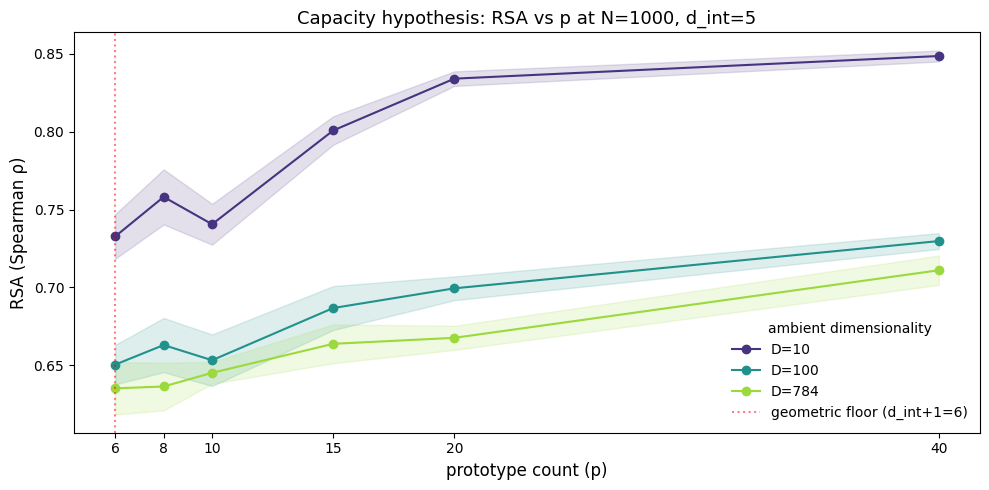

In [ ]:
# load the p-sweep results
results_p = pd.read_csv('/content/drive/MyDrive/dissertation/results_p_sweep.csv')

fig, ax = plt.subplots(figsize=(10, 5))

D_levels = sorted(results_p['D'].unique())
colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(D_levels)))

for colour, D in zip(colours, D_levels):
    sub = results_p[results_p['D'] == D]
    stats = sub.groupby('p')['rsa_optB_spearman'].agg(['mean', 'std']).reset_index()
    ax.plot(stats['p'], stats['mean'], marker='o', color=colour, label=f'D={D}')
    ax.fill_between(stats['p'],
                     stats['mean'] - stats['std'],
                     stats['mean'] + stats['std'],
                     alpha=0.15, color=colour)

# mark the geometric floor
ax.axvline(6, color='red', linestyle=':', alpha=0.5, label='geometric floor (d_int+1=6)')

ax.set_xlabel('prototype count (p)', fontsize=12)
ax.set_ylabel('RSA (Spearman ρ)', fontsize=12)
ax.set_title('Capacity hypothesis: RSA vs p at N=1000, d_int=5', fontsize=13)
ax.legend(title='ambient dimensionality', frameon=False)
ax.set_xticks(sorted(results_p['p'].unique()))
plt.tight_layout()

In [ ]:
sub_10 = results_p[results_p['D'] == 10]
for p in [6, 8, 10, 15]:
    vals = sub_10[sub_10['p'] == p]['rsa_optB_spearman']
    print(f"  p={p}: mean={vals.mean():.4f}  std={vals.std():.4f}  "
          f"min={vals.min():.4f}  max={vals.max():.4f}")


  p=6: mean=0.7327  std=0.0144  min=0.7055  max=0.7573
  p=8: mean=0.7581  std=0.0177  min=0.7122  max=0.7750
  p=10: mean=0.7406  std=0.0131  min=0.7154  max=0.7545
  p=15: mean=0.8008  std=0.0092  min=0.7829  max=0.8152


In [ ]:
from scipy.stats import mannwhitneyu

def cliff_delta(x, y):
    x, y = np.array(x), np.array(y)
    more = sum((xi > yj) for xi in x for yj in y)
    less = sum((xi < yj) for xi in x for yj in y)
    return (more - less) / (len(x) * len(y))

p8_vals = sub_10[sub_10['p'] == 8]['rsa_optB_spearman'].values
p10_vals = sub_10[sub_10['p'] == 10]['rsa_optB_spearman'].values
U, p_val = mannwhitneyu(p8_vals, p10_vals, alternative='two-sided')
cd = cliff_delta(p8_vals, p10_vals)
print(f"p=8 vs p=10 at D=10: U={U}, p={p_val:.4f}, Cliff's δ={cd:.2f}")

p=8 vs p=10 at D=10: U=87.0, p=0.0058, Cliff's δ=0.74


# Module 6 — Analysis and Statistics

## Objective

Consume the results from all three sweep arms and produce the figures
and statistical tests that constitute the Results chapter. The analysis
follows a pre-specified plan — descriptive plots first, then the
noise-ceiling relationship, then inferential statistics, then the
cross-dataset comparison.

## Research questions driving the analysis

- **H1** — does topology preservation degrade as N (dataset size) or
  D (ambient dimensionality) increases? Primary evidence: synthetic arm,
  RSA vs N and D separately.
- **H3** — does preservation differ between MNIST and word embeddings?
  Primary evidence: real-data arms compared at matched N.
- **Capacity** — does preservation break down as p approaches the
  predicted floor of d_int + 1? Not yet run — requires a separate p-sweep.

## Data entering this module

Three sweep arms, all saved to Drive and loaded via `load_all_results`:
- **Synthetic linear subspace**: 12 conditions (4 N × 3 D), 10 repeats,
  120 runs total. Primary evidence for H1.
- **MNIST**: 4 conditions (4 N), 10 repeats, 40 runs.
- **Word embeddings**: 4 conditions (4 N), 10 repeats, 40 runs.
  Fragmentation observed at N=500 and N=1000 — items dropped and logged;
  RDMs trimmed to matched size for ceiling computation.

Together: 200 runs across 20 conditions.

## Analysis plan

| Step | What | Why |
|---|---|---|
| 1 | `load_all_results` | combine CSVs + ceilings into one working frame |
| 2 | `plot_rsa_by_factor` | mean RSA ± SD vs N or D — the primary figures |
| 3 | `plot_with_ceiling` | same plots with noise ceiling overlaid |
| 4 | `cliff_delta` | effect size for Mann-Whitney comparisons |
| 5 | `run_comparisons` | pre-specified pairwise tests with Bonferroni correction |
| 6 | `plot_cross_dataset` | all three datasets at matched N — the H3 figure |

## Statistical approach

Mann-Whitney U tests with Cliff's δ effect sizes on pre-specified
comparisons only (not data-driven). Bonferroni correction applied across
the family of comparisons. ART ANOVA flagged as the planned omnibus test
for the synthetic factorial (N × D interaction) — requires either R via
rpy2 or a vetted Python implementation; decision deferred to post-sweep
given thin Python tooling. Results reported as comparisons between
conditions, not absolute RSA scores. Within-condition RSA (noise ceiling)
acts as the interpretive upper bound.

## Validation plan

- `load_all_results` returns exactly 200 rows, one ceiling per row,
  three dataset labels — confirmed ✓
- Plots checked against known patterns from the ceiling data before
  any statistical tests are run

In [ ]:
def load_all_results_v2(drive_path='/content/drive/MyDrive/dissertation'):
    """
    Load all v2 sweep arms (corrected τ) and their noise ceilings,
    plus the capacity p-sweep results.
    """
    syn   = pd.read_csv(f'{drive_path}/results_synthetic_v2.csv')
    mnist = pd.read_csv(f'{drive_path}/results_mnist_v2.csv')
    words = pd.read_csv(f'{drive_path}/results_words_v2.csv')

    with open(f'{drive_path}/ceilings_synthetic_v2.json') as f:
        c_syn = json.load(f)
    with open(f'{drive_path}/ceilings_mnist_v2.json') as f:
        c_mnist = json.load(f)
    with open(f'{drive_path}/ceilings_words_v2.json') as f:
        c_words = json.load(f)

    ceilings = {**c_syn, **c_mnist, **c_words}

    df = pd.concat([syn, mnist, words], ignore_index=True)
    df['ceiling'] = df['condition_id'].map(ceilings)
    df['dataset'] = df['data_type'].map({
        'manifold': 'Synthetic',
        'mnist':    'MNIST',
        'words':    'Word embeddings'
    })

    print(f"total runs: {len(df)}")
    print(f"conditions: {df['condition_id'].nunique()}")
    print(f"datasets:   {list(df['dataset'].unique())}")
    return df, ceilings

df_v2, ceilings_v2 = load_all_results_v2()

total runs: 200
conditions: 20
datasets:   ['Synthetic', 'MNIST', 'Word embeddings']


In [ ]:
from scipy.stats import mannwhitneyu, spearmanr

def cliff_delta(x, y):
    x, y = np.array(x), np.array(y)
    more = sum((xi > yj) for xi in x for yj in y)
    less = sum((xi < yj) for xi in x for yj in y)
    return (more - less) / (len(x) * len(y))

def plot_rsa_by_factor(df, dataset_name, factor, metric='rsa_optB_spearman',
                        other_factor=None, figsize=(10, 5)):
    sub = df[df['dataset'] == dataset_name].copy()
    fig, ax = plt.subplots(figsize=figsize)
    if other_factor:
        levels = sorted(sub[other_factor].unique())
        colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(levels)))
        for colour, level in zip(colours, levels):
            grp = sub[sub[other_factor] == level]
            stats = grp.groupby(factor)[metric].agg(['mean', 'std']).reset_index()
            ax.plot(stats[factor], stats['mean'], marker='o',
                    label=f'{other_factor}={level}', color=colour)
            ax.fill_between(stats[factor], stats['mean'] - stats['std'],
                            stats['mean'] + stats['std'], alpha=0.15, color=colour)
    else:
        stats = sub.groupby(factor)[metric].agg(['mean', 'std']).reset_index()
        ax.plot(stats[factor], stats['mean'], marker='o', color='steelblue')
        ax.fill_between(stats[factor], stats['mean'] - stats['std'],
                        stats['mean'] + stats['std'], alpha=0.2, color='steelblue')
    ax.set_xlabel(factor, fontsize=12)
    ax.set_ylabel('RSA (Spearman ρ)', fontsize=12)
    ax.set_title(f'{dataset_name}: RSA vs {factor}', fontsize=13)
    if other_factor: ax.legend(title=other_factor, fontsize=10)
    ax.set_ylim(0, 1)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    plt.tight_layout()
    plt.show()

def plot_with_ceiling(df, dataset_name, factor, metric='rsa_optB_spearman',
                      other_factor=None, figsize=(10, 5)):
    sub = df[df['dataset'] == dataset_name].copy()
    fig, ax = plt.subplots(figsize=figsize)
    if other_factor:
        levels = sorted(sub[other_factor].unique())
        colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(levels)))
        for colour, level in zip(colours, levels):
            grp = sub[sub[other_factor] == level]
            stats = grp.groupby(factor)[metric].agg(['mean','std']).reset_index()
            ceil  = grp.groupby(factor)['ceiling'].mean().reset_index()
            ax.plot(stats[factor], stats['mean'], marker='o', color=colour,
                    label=f'{other_factor}={level}')
            ax.fill_between(stats[factor], stats['mean'] - stats['std'],
                            stats['mean'] + stats['std'], alpha=0.15, color=colour)
            ax.plot(ceil[factor], ceil['ceiling'], linestyle='--', color=colour, alpha=0.6)
    else:
        stats = sub.groupby(factor)[metric].agg(['mean','std']).reset_index()
        ceil  = sub.groupby(factor)['ceiling'].mean().reset_index()
        ax.plot(stats[factor], stats['mean'], marker='o', color='steelblue', label='RSA')
        ax.fill_between(stats[factor], stats['mean'] - stats['std'],
                        stats['mean'] + stats['std'], alpha=0.2, color='steelblue')
        ax.plot(ceil[factor], ceil['ceiling'], linestyle='--', color='steelblue',
                alpha=0.6, label='Noise ceiling')
    ax.set_xlabel(factor, fontsize=12)
    ax.set_ylabel('RSA (Spearman rho)', fontsize=12)
    ax.set_title(f'{dataset_name}: RSA vs {factor} with noise ceiling', fontsize=13)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.annotate('dashed = noise ceiling', xy=(0.02, 0.04), xycoords='axes fraction',
                fontsize=8, color='gray')
    plt.tight_layout()
    plt.show()

def plot_cross_dataset(df, metric='rsa_optB_spearman', figsize=(10, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    datasets = ['Synthetic', 'MNIST', 'Word embeddings']
    colours = {'Synthetic': '#2C3E50', 'MNIST': '#1D9E75', 'Word embeddings': '#E67E22'}
    for ds in datasets:
        sub = df[df['dataset'] == ds]
        if ds == 'Synthetic': sub = sub[sub['D'] == 784]
        stats = sub.groupby('N')[metric].agg(['mean', 'std']).reset_index()
        ax.plot(stats['N'], stats['mean'], marker='o', color=colours[ds], label=ds)
        ax.fill_between(stats['N'], stats['mean'] - stats['std'],
                        stats['mean'] + stats['std'], alpha=0.15, color=colours[ds])
    ax.set_xlabel('N', fontsize=12)
    ax.set_ylabel('RSA (Spearman ρ)', fontsize=12)
    ax.set_title('Cross-dataset comparison (synthetic at D=784)', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    plt.tight_layout()
    plt.show()

def run_comparisons(df, metric='rsa_optB_spearman'):
    comparisons = []
    N_values = sorted(df[df['dataset'] == 'Synthetic']['N'].unique())
    for N in N_values:
        syn = df[(df['dataset'] == 'Synthetic') & (df['N'] == N)]
        for d_a, d_b in [(10, 784), (10, 100), (100, 784)]:
            group_a = syn[syn['D'] == d_a][metric].values
            group_b = syn[syn['D'] == d_b][metric].values
            U, p = mannwhitneyu(group_a, group_b, alternative='two-sided')
            cd = cliff_delta(group_a, group_b)
            comparisons.append({'comparison': f'Synth D={d_a} vs D={d_b}',
                                'N': N, 'U': U, 'p': p, 'cliff_delta': cd})
    for N in N_values:
        mnist_vals = df[(df['dataset'] == 'MNIST') & (df['N'] == N)][metric].values
        words_vals = df[(df['dataset'] == 'Word embeddings') & (df['N'] == N)][metric].values
        if len(mnist_vals) > 0 and len(words_vals) > 0:
            U, p = mannwhitneyu(mnist_vals, words_vals, alternative='two-sided')
            cd = cliff_delta(mnist_vals, words_vals)
            comparisons.append({'comparison': 'MNIST vs Words', 'N': N, 'U': U, 'p': p, 'cliff_delta': cd})
    for N in N_values:
        syn784 = df[(df['dataset'] == 'Synthetic') & (df['N'] == N) & (df['D'] == 784)][metric].values
        mnist_vals = df[(df['dataset'] == 'MNIST') & (df['N'] == N)][metric].values
        if len(syn784) > 0 and len(mnist_vals) > 0:
            U, p = mannwhitneyu(syn784, mnist_vals, alternative='two-sided')
            cd = cliff_delta(syn784, mnist_vals)
            comparisons.append({'comparison': 'Synth D=784 vs MNIST', 'N': N, 'U': U, 'p': p, 'cliff_delta': cd})
    comp_df = pd.DataFrame(comparisons)
    n_tests = len(comp_df)
    comp_df['p_corrected'] = (comp_df['p'] * n_tests).clip(upper=1.0)
    comp_df['significant'] = comp_df['p_corrected'] < 0.05
    return comp_df

print("✓ analysis functions defined")

✓ analysis functions defined


In [ ]:
# =====================================================================
# TABLE 4 — The twenty pre-specified comparisons (exact Mann-Whitney)
# ---------------------------------------------------------------------
# Recomputes all twenty pre-specified comparisons (per the
# run_comparisons docstring) from the v2 result files, using the EXACT
# Mann-Whitney method (method='exact'), which is appropriate for
# n = 10 per group and is what the results chapter reports.
# NOTE: run_comparisons itself uses scipy's default (asymptotic)
# method and earlier versions ran against v1 CSVs — this cell
# supersedes its output for the dissertation's Table 4.
#
# Requires: results_synthetic_v2.csv, results_mnist_v2.csv,
# results_words_v2.csv in the working directory (adjust paths below).
# =====================================================================

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

BASE = "/content/drive/MyDrive/dissertation/"
syn = pd.read_csv(BASE + "results_synthetic_v2.csv")
mn  = pd.read_csv(BASE + "results_mnist_v2.csv")
wd  = pd.read_csv(BASE + "results_words_v2.csv")
DV  = "rsa_optB_spearman"
N_TESTS = 20  # Bonferroni family size (pre-specified)

def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    gt = sum((x > y) for x in a for y in b)
    lt = sum((x < y) for x in a for y in b)
    return (gt - lt) / (len(a) * len(b))

rows = []
def compare(group, label, a, b):
    assert len(a) == 10 and len(b) == 10, f"expected 10 runs per group: {label}"
    U, p = mannwhitneyu(a, b, alternative="two-sided", method="exact")
    rows.append({
        "Group": group,
        "Comparison": label,
        "U": int(U),
        "exact p": p,
        "corrected p": min(p * N_TESTS, 1.0),
        "Cliff's d": round(cliffs_delta(a, b), 2),
    })

# --- 12 synthetic D-axis comparisons (RQ1) ---------------------------
for N in [500, 1000, 2000, 5000]:
    s = syn[syn.N == N]
    for d1, d2 in [(10, 100), (10, 784), (100, 784)]:
        compare("RQ1: synthetic D-axis", f"N={N}: D={d1} vs D={d2}",
                s[s.D == d1][DV].values, s[s.D == d2][DV].values)

# --- 4 MNIST vs word-embedding comparisons (RQ3) ---------------------
for N in [500, 1000, 2000, 5000]:
    compare("RQ3: MNIST vs words", f"N={N}: MNIST vs words",
            mn[mn.N == N][DV].values, wd[wd.N == N][DV].values)

# --- 4 synthetic (D=784) vs MNIST comparisons (RQ3) ------------------
for N in [500, 1000, 2000, 5000]:
    compare("RQ3: synthetic vs MNIST", f"N={N}: synthetic (D=784) vs MNIST",
            syn[(syn.N == N) & (syn.D == 784)][DV].values,
            mn[mn.N == N][DV].values)

table4 = pd.DataFrame(rows)
table4["sig. (corrected)"] = np.where(table4["corrected p"] < .05, "*", "n.s.")

# --- validation against the results chapter --------------------------
assert len(table4) == 20, "expected exactly 20 pre-specified comparisons"
assert (table4["sig. (corrected)"] == "*").sum() == 19, "expected 19 of 20 significant"
d_axis = table4[table4.Group == "RQ1: synthetic D-axis"]
assert (d_axis["U"] == 100).all() and (d_axis["Cliff's d"] == 1.00).all(), \
    "all D-axis comparisons should give U=100, delta=1.00"
ns = table4[table4["sig. (corrected)"] == "n.s."]
assert list(ns["Comparison"]) == ["N=2000: synthetic (D=784) vs MNIST"], \
    "the single n.s. comparison should be synth vs MNIST at N=2000"
print("Validation passed: 20 comparisons, 19 significant after correction;")
print("sole exception synthetic vs MNIST at N=2000 (corrected p = "
      f"{ns['corrected p'].iloc[0]:.3f}).\n")

# --- display and export ----------------------------------------------
pd.set_option("display.width", 200)
print(table4.to_string(index=False,
      formatters={"exact p": "{:.6f}".format, "corrected p": "{:.6f}".format}))

table4.to_csv("table4_prespecified_comparisons.csv", index=False)
print("\nSaved: table4_prespecified_comparisons.csv")
# For the LaTeX chapter: values < .001 should be typeset as "< .001"

Validation passed: 20 comparisons, 19 significant after correction;
sole exception synthetic vs MNIST at N=2000 (corrected p = 0.078).

                  Group                         Comparison   U  exact p corrected p  Cliff's d sig. (corrected)
  RQ1: synthetic D-axis               N=500: D=10 vs D=100 100 0.000011    0.000217       1.00                *
  RQ1: synthetic D-axis               N=500: D=10 vs D=784 100 0.000011    0.000217       1.00                *
  RQ1: synthetic D-axis              N=500: D=100 vs D=784 100 0.000011    0.000217       1.00                *
  RQ1: synthetic D-axis              N=1000: D=10 vs D=100 100 0.000011    0.000217       1.00                *
  RQ1: synthetic D-axis              N=1000: D=10 vs D=784 100 0.000011    0.000217       1.00                *
  RQ1: synthetic D-axis             N=1000: D=100 vs D=784 100 0.000011    0.000217       1.00                *
  RQ1: synthetic D-axis              N=2000: D=10 vs D=100 100 0.000011    0.000

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!find /content/drive/MyDrive -name "results_synthetic_v2.csv" 2>/dev/null

/content/drive/MyDrive/dissertation/results_synthetic_v2.csv


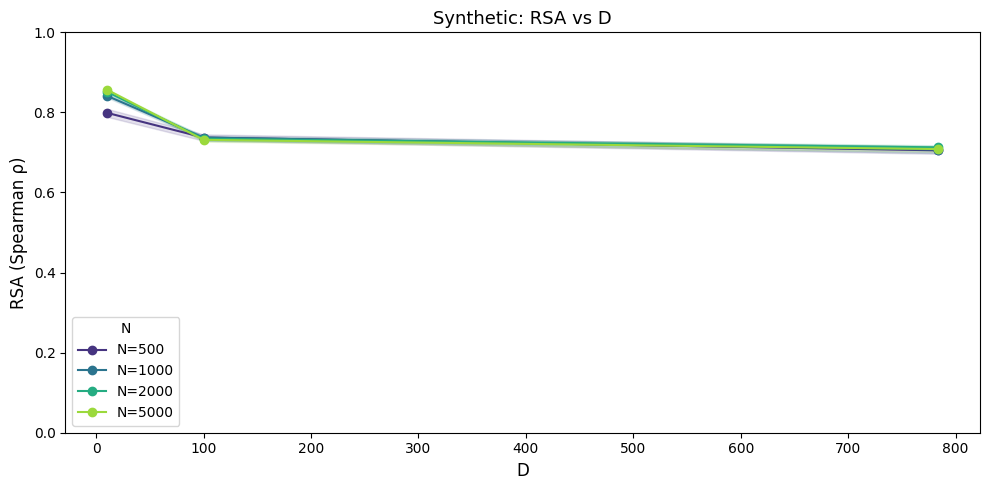

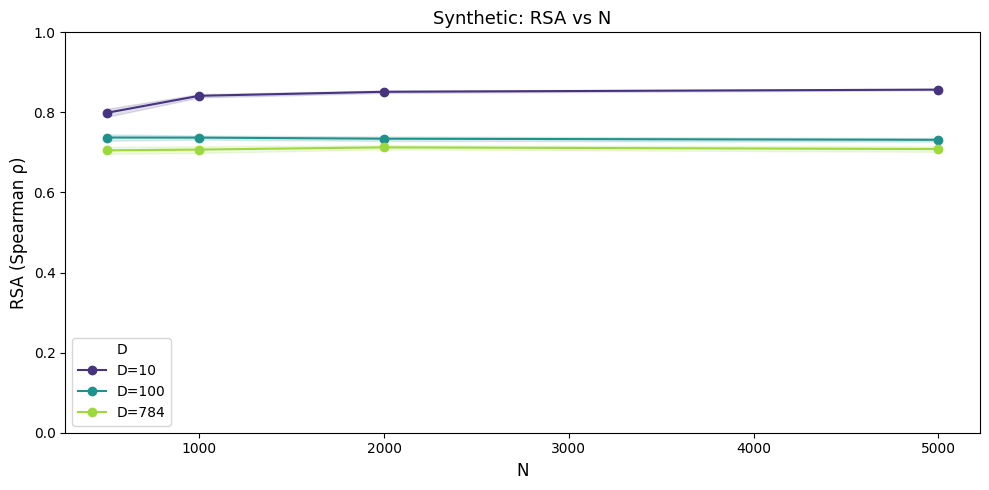

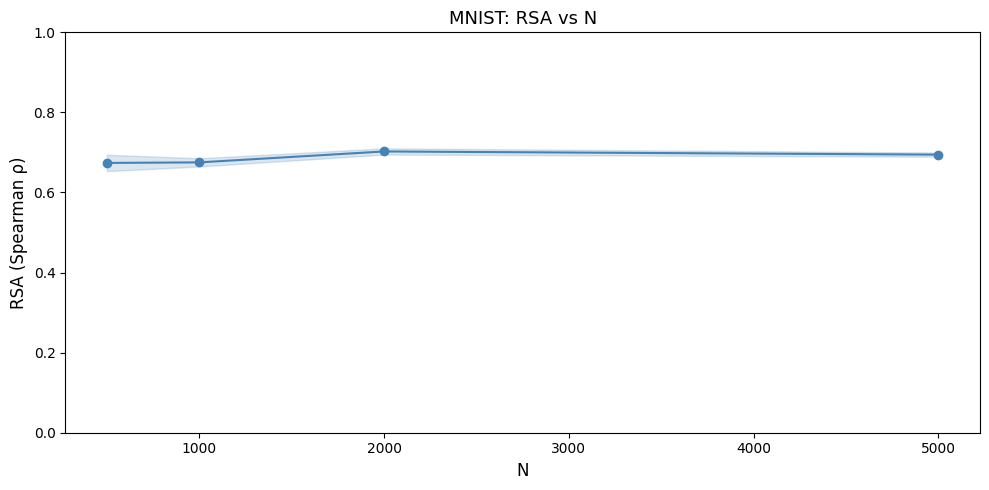

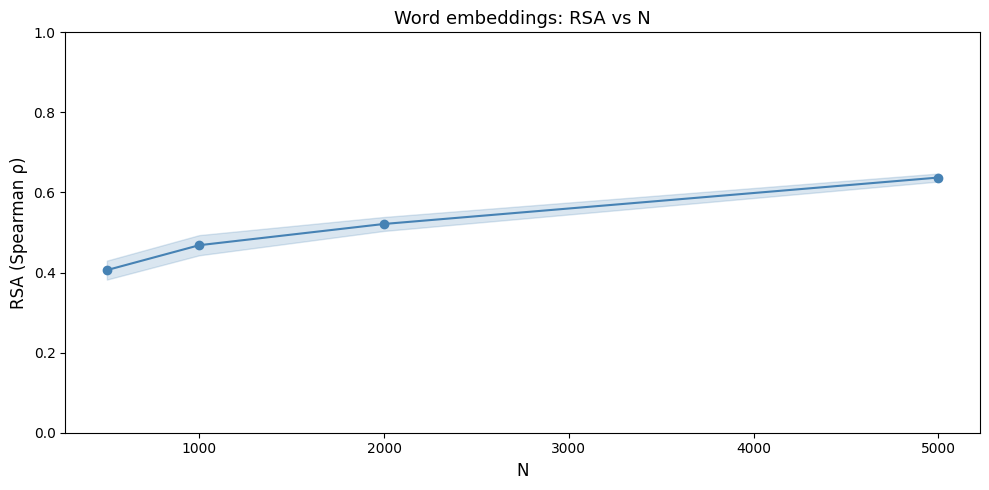

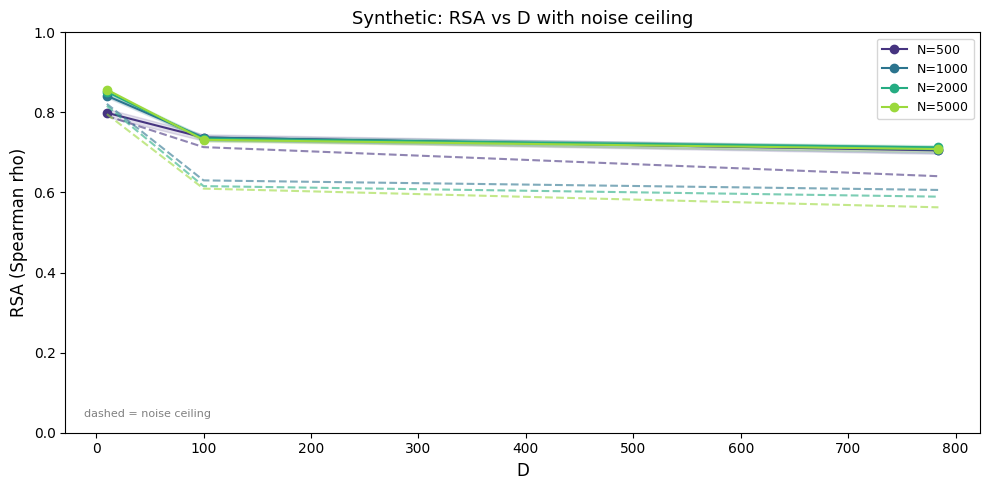

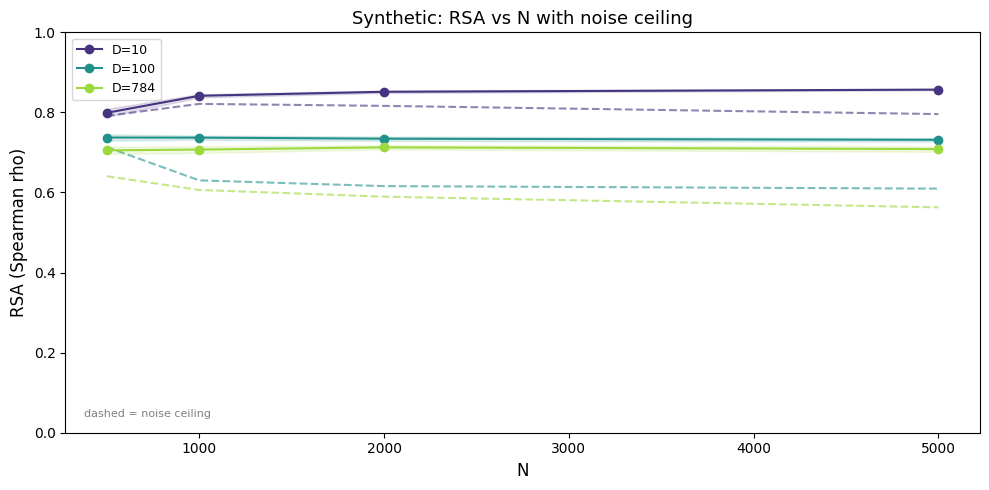

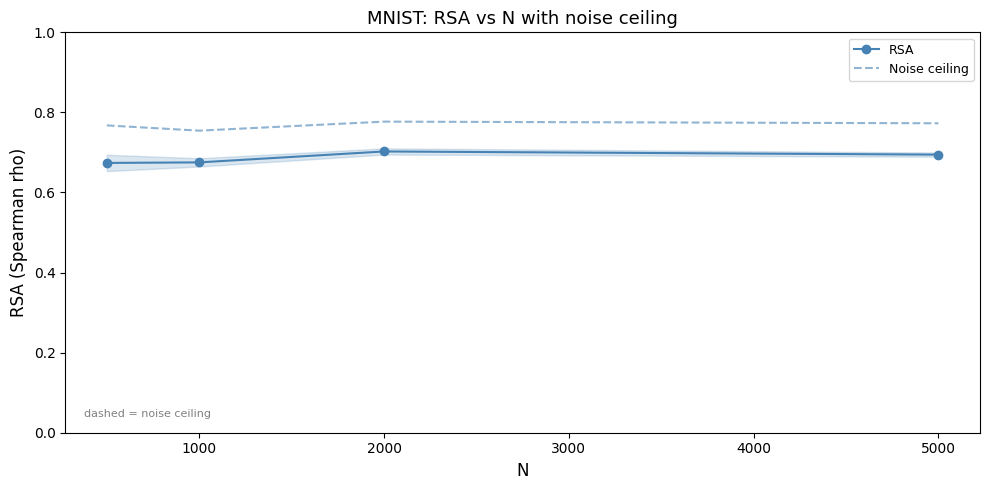

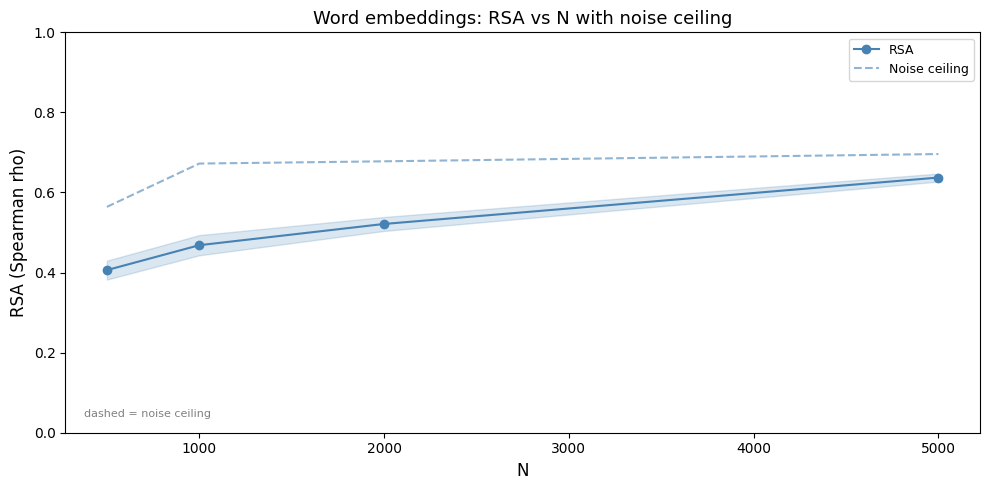

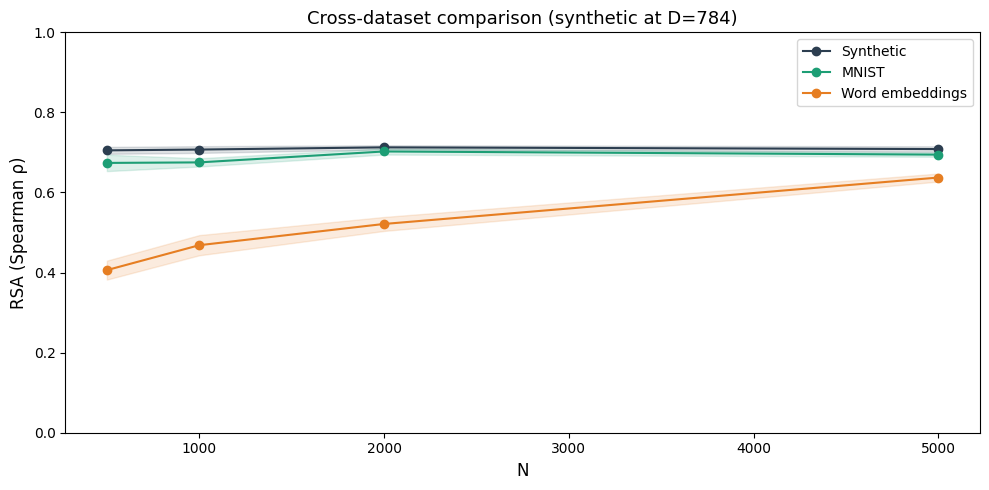


total comparisons: 20
Bonferroni correction across 20 tests

          comparison    N        U      p  cliff_delta  p_corrected  significant
 Synth D=10 vs D=784  500 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=100  500 100.0000 0.0002       1.0000       0.0037         True
Synth D=100 vs D=784  500 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=784 1000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=100 1000 100.0000 0.0002       1.0000       0.0037         True
Synth D=100 vs D=784 1000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=784 2000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=100 2000 100.0000 0.0002       1.0000       0.0037         True
Synth D=100 vs D=784 2000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=784 5000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=100 5000 100.0000 0.0002      

In [ ]:
# ---- H1 plots ----
plot_rsa_by_factor(df_v2, 'Synthetic', factor='D', other_factor='N')
plot_rsa_by_factor(df_v2, 'Synthetic', factor='N', other_factor='D')

# ---- H3 plots ----
plot_rsa_by_factor(df_v2, 'MNIST', factor='N')
plot_rsa_by_factor(df_v2, 'Word embeddings', factor='N')

# ---- ceiling overlays ----
plot_with_ceiling(df_v2, 'Synthetic', factor='D', other_factor='N')
plot_with_ceiling(df_v2, 'Synthetic', factor='N', other_factor='D')
plot_with_ceiling(df_v2, 'MNIST', factor='N')
plot_with_ceiling(df_v2, 'Word embeddings', factor='N')

# ---- cross-dataset comparison ----
plot_cross_dataset(df_v2)

# ---- statistics ----
comp_df_v2 = run_comparisons(df_v2)
print(f"\ntotal comparisons: {len(comp_df_v2)}")
print(f"Bonferroni correction across {len(comp_df_v2)} tests\n")
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(comp_df_v2.to_string(index=False))

In [ ]:
def plot_rsa_by_factor(df, dataset_name, factor, metric='rsa_optB_spearman',
                        other_factor=None, figsize=(10, 5)):
    """
    Line plot of mean RSA ± 1 SD vs a scaling factor (N or D),
    with separate lines for each level of the other factor.
    Shows run-to-run spread as shaded band.

    Args:
        df (pd.DataFrame): combined results dataframe
        dataset_name (str): 'Synthetic', 'MNIST', or 'Word embeddings'
        factor (str): column to put on x-axis ('N' or 'D')
        metric (str): column to plot on y-axis
        other_factor (str): column to split into separate lines (optional)
        figsize (tuple): figure size
    """
    sub = df[df['dataset'] == dataset_name].copy()

    fig, ax = plt.subplots(figsize=figsize)

    if other_factor:
        levels = sorted(sub[other_factor].unique())
        colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(levels)))
        for colour, level in zip(colours, levels):
            grp = sub[sub[other_factor] == level]
            stats = grp.groupby(factor)[metric].agg(['mean', 'std']).reset_index()
            ax.plot(stats[factor], stats['mean'],
                    marker='o', label=f'{other_factor}={level}', color=colour)
            ax.fill_between(stats[factor],
                            stats['mean'] - stats['std'],
                            stats['mean'] + stats['std'],
                            alpha=0.15, color=colour)
    else:
        stats = sub.groupby(factor)[metric].agg(['mean', 'std']).reset_index()
        ax.plot(stats[factor], stats['mean'], marker='o', color='steelblue')
        ax.fill_between(stats[factor],
                        stats['mean'] - stats['std'],
                        stats['mean'] + stats['std'],
                        alpha=0.2, color='steelblue')

    ax.set_xlabel(factor, fontsize=12)
    ax.set_ylabel('RSA (Spearman ρ)', fontsize=12)
    ax.set_title(f'{dataset_name}: RSA vs {factor}', fontsize=13)
    if other_factor:
        ax.legend(title=other_factor, fontsize=10)
    ax.set_ylim(0, 1)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    plt.tight_layout()


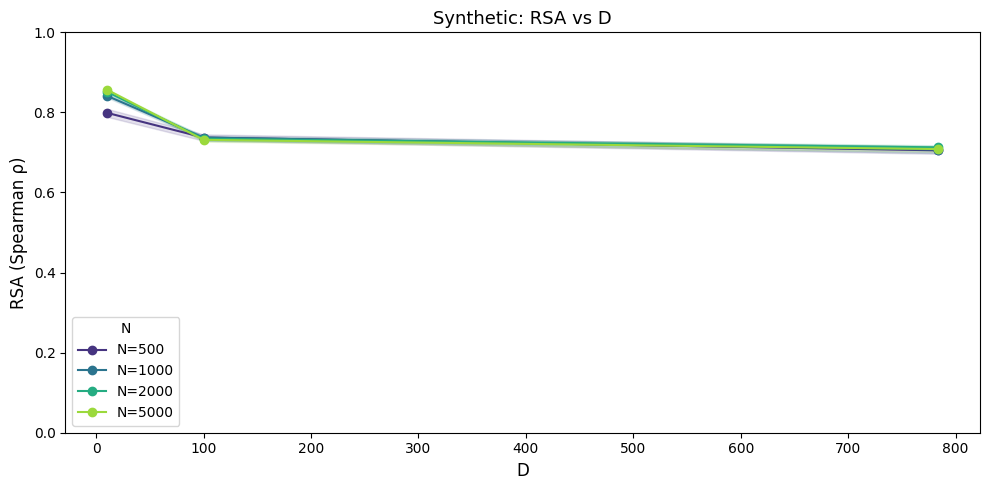

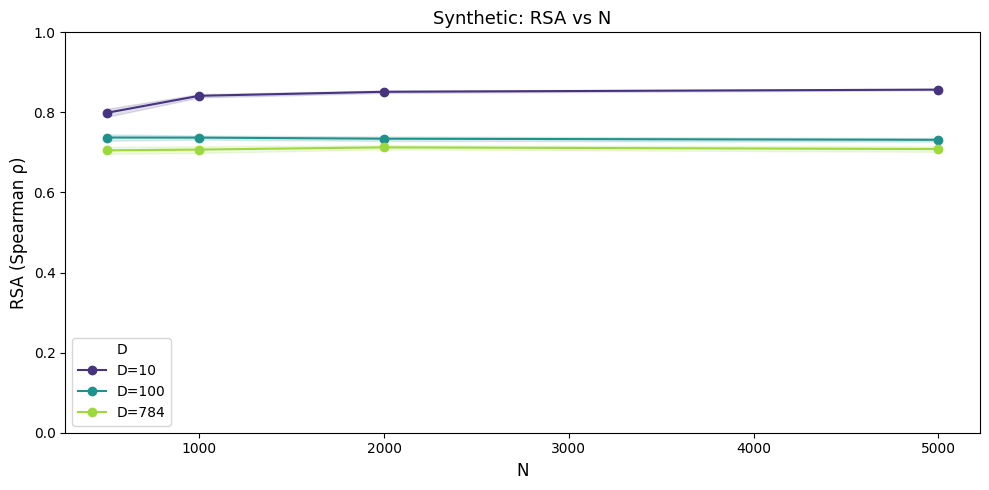

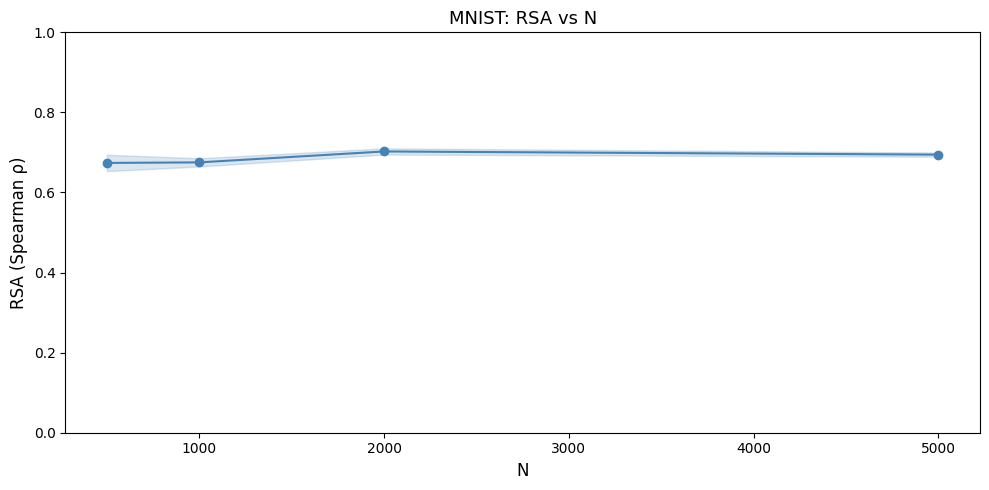

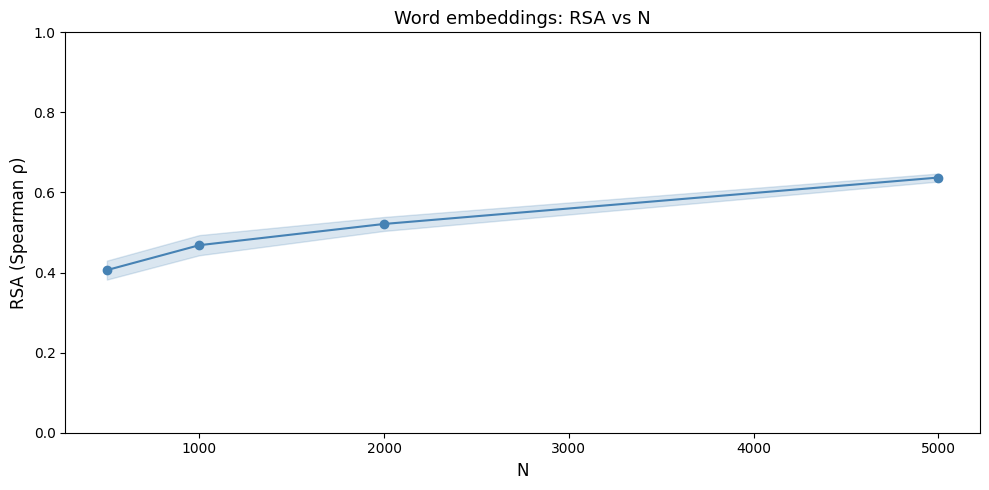

In [ ]:
df = df_v2   # ensure we're using the v2 dataframe, not whatever df is left over

# H1: does RSA degrade as D increases? (synthetic, one line per N)
plot_rsa_by_factor(df, 'Synthetic', factor='D', other_factor='N')

# H1: does RSA degrade as N increases? (synthetic, one line per D)
plot_rsa_by_factor(df, 'Synthetic', factor='N', other_factor='D')

# H3: MNIST — RSA vs N
plot_rsa_by_factor(df, 'MNIST', factor='N')

# H3: words — RSA vs N
plot_rsa_by_factor(df, 'Word embeddings', factor='N')

In [ ]:
def plot_with_ceiling(df, dataset_name, factor, metric='rsa_optB_spearman',
                      other_factor=None, figsize=(10, 5)):
    """
    Same as plot_rsa_by_factor but with the noise ceiling overlaid
    as a dashed line (or set of dashed lines) for each group.
    The ceiling is the within-condition RSA — the self-consistency
    limit of the pipeline. Preservation scores should sit below it.

    Args:
        df (pd.DataFrame): combined results dataframe
        dataset_name (str): 'Synthetic', 'MNIST', or 'Word embeddings'
        factor (str): column to put on x-axis ('N' or 'D')
        metric (str): column to plot on y-axis
        other_factor (str): column to split into separate lines (optional)
        figsize (tuple): figure size
    """
    sub = df[df['dataset'] == dataset_name].copy()

    fig, ax = plt.subplots(figsize=figsize)

    if other_factor:
        levels = sorted(sub[other_factor].unique())
        colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(levels)))
        for colour, level in zip(colours, levels):
            grp = sub[sub[other_factor] == level]
            stats = grp.groupby(factor)[metric].agg(['mean','std']).reset_index()
            ceil  = grp.groupby(factor)['ceiling'].mean().reset_index()

            ax.plot(stats[factor], stats['mean'],
                    marker='o', color=colour,
                    label=f'{other_factor}={level}')
            ax.fill_between(stats[factor],
                            stats['mean'] - stats['std'],
                            stats['mean'] + stats['std'],
                            alpha=0.15, color=colour)
            ax.plot(ceil[factor], ceil['ceiling'],
                    linestyle='--', color=colour, alpha=0.6)
    else:
        stats = sub.groupby(factor)[metric].agg(['mean','std']).reset_index()
        ceil  = sub.groupby(factor)['ceiling'].mean().reset_index()

        ax.plot(stats[factor], stats['mean'],
                marker='o', color='steelblue', label='RSA')
        ax.fill_between(stats[factor],
                        stats['mean'] - stats['std'],
                        stats['mean'] + stats['std'],
                        alpha=0.2, color='steelblue')
        ax.plot(ceil[factor], ceil['ceiling'],
                linestyle='--', color='steelblue', alpha=0.6,
                label='Noise ceiling')

    ax.set_xlabel(factor, fontsize=12)
    ax.set_ylabel('RSA (Spearman rho)', fontsize=12)
    ax.set_title(f'{dataset_name}: RSA vs {factor} with noise ceiling',
                 fontsize=13)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

    # annotation explaining dashed lines
    ax.annotate('dashed = noise ceiling (self-consistency limit)',
                xy=(0.02, 0.04), xycoords='axes fraction',
                fontsize=8, color='gray')

    plt.tight_layout()
    plt.show()

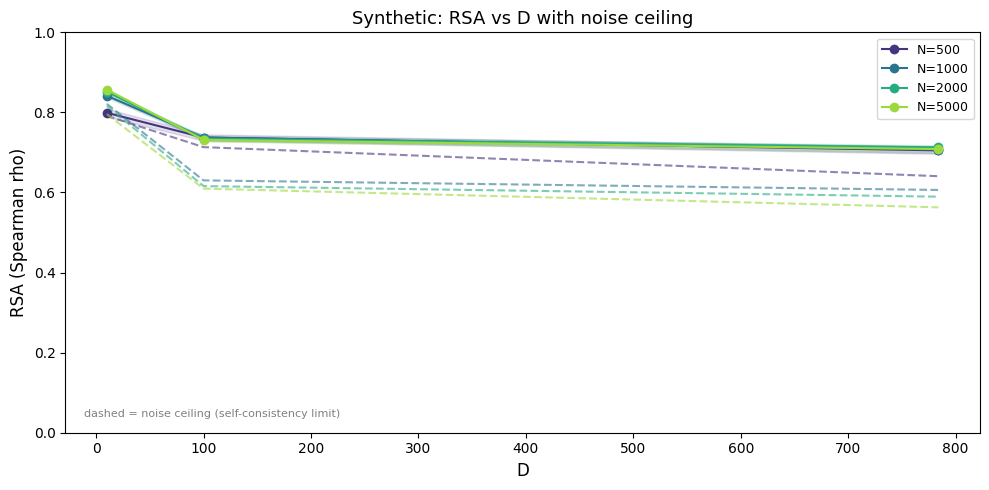

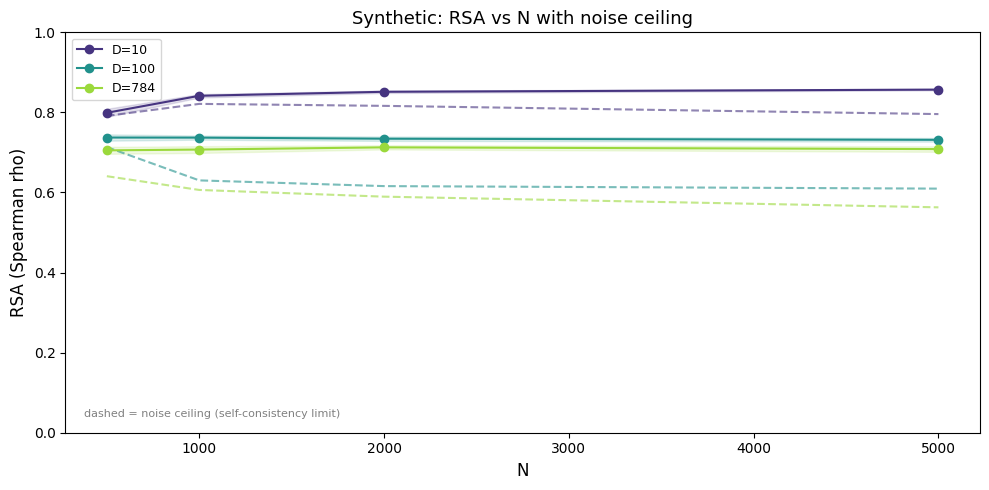

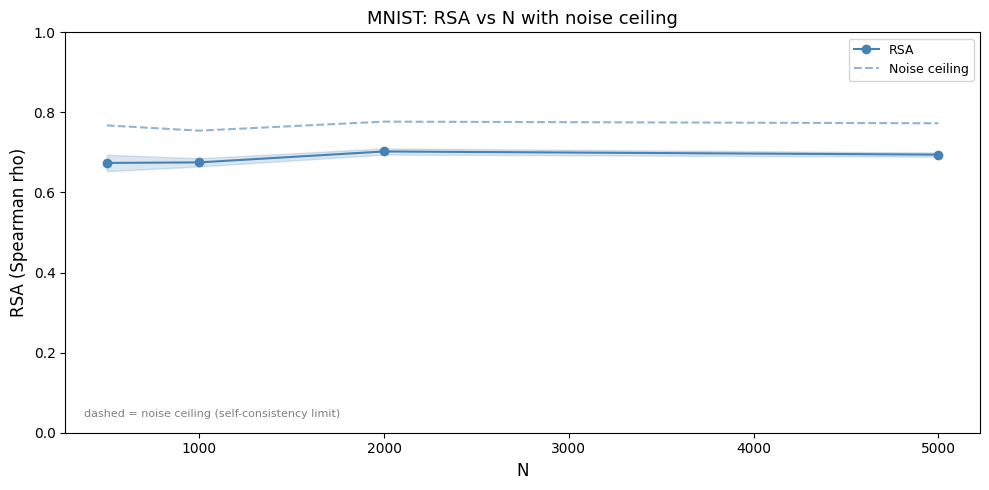

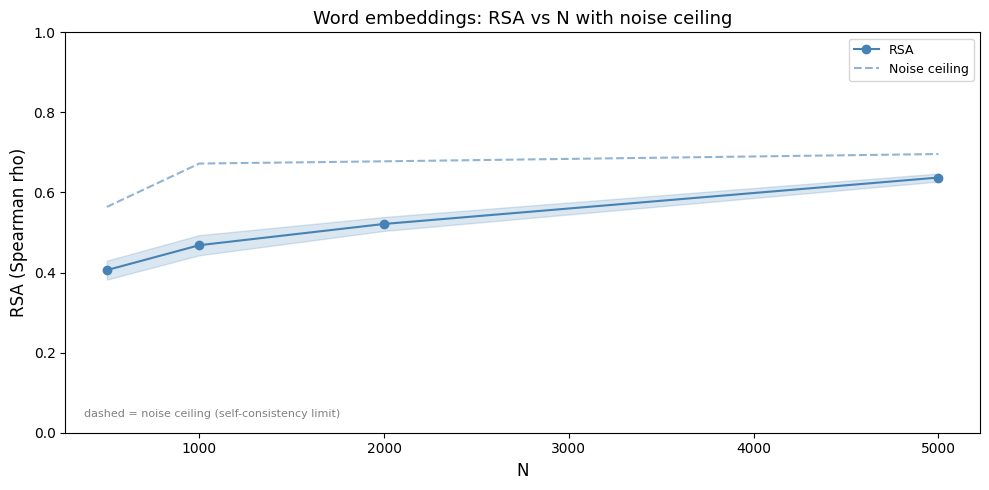

In [ ]:
# synthetic: RSA vs D with ceiling per N
plot_with_ceiling(df, 'Synthetic', factor='D', other_factor='N')

# synthetic: RSA vs N with ceiling per D
plot_with_ceiling(df, 'Synthetic', factor='N', other_factor='D')

# MNIST: RSA vs N with ceiling
plot_with_ceiling(df, 'MNIST', factor='N')

# words: RSA vs N with ceiling
plot_with_ceiling(df, 'Word embeddings', factor='N')


In [ ]:
def plot_cross_dataset(df, metric='rsa_optB_spearman', figsize=(10, 5)):
    """
    Compare all three datasets at matched N values on one plot.
    This is the primary H3 figure: does preservation differ between
    synthetic, MNIST, and word embeddings?

    Args:
        df (pd.DataFrame): combined results dataframe
        metric (str): column to plot
        figsize (tuple): figure size
    """
    fig, ax = plt.subplots(figsize=figsize)

    datasets = ['Synthetic', 'MNIST', 'Word embeddings']
    colours = {'Synthetic': '#2C3E50', 'MNIST': '#1D9E75', 'Word embeddings': '#E67E22'}

    for ds in datasets:
        sub = df[df['dataset'] == ds]
        if ds == 'Synthetic':
            # use D=784 only, to match real-data dimensionality
            sub = sub[sub['D'] == 784]
        stats = sub.groupby('N')[metric].agg(['mean', 'std']).reset_index()
        ax.plot(stats['N'], stats['mean'],
                marker='o', color=colours[ds], label=ds)
        ax.fill_between(stats['N'],
                        stats['mean'] - stats['std'],
                        stats['mean'] + stats['std'],
                        alpha=0.15, color=colours[ds])

    ax.set_xlabel('N', fontsize=12)
    ax.set_ylabel('RSA (Spearman ρ)', fontsize=12)
    ax.set_title('Cross-dataset comparison (synthetic at D=784)', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

    ax.annotate('Synthetic filtered to D=784 for matched-dimensionality comparison',
                xy=(0.02, 0.04), xycoords='axes fraction',
                fontsize=8, color='gray')
    plt.tight_layout()
    plt.show()

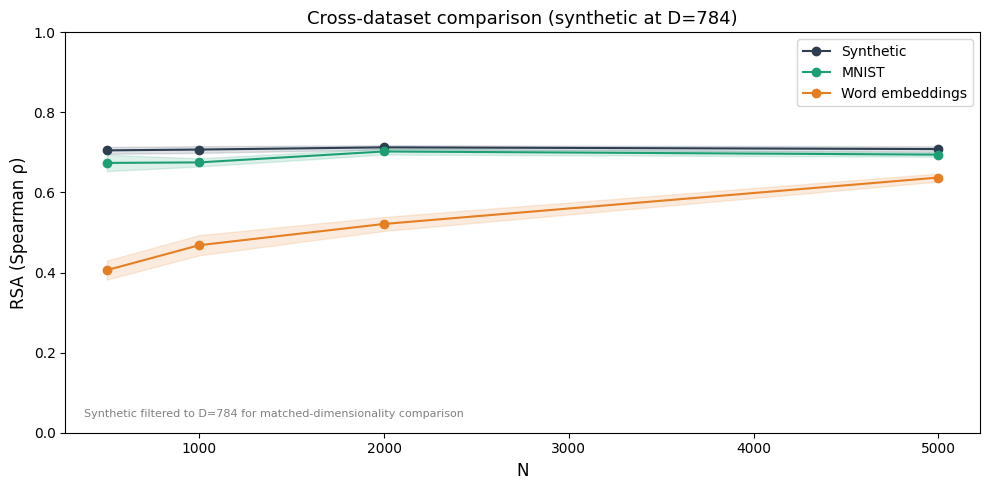

In [ ]:
plot_cross_dataset(df)

In [ ]:
def cliff_delta(x, y):
    """
    Compute Cliff's delta: a non-parametric effect size for two groups.
    Ranges from -1 to +1. Near 0 = no effect; |d| > 0.33 = medium;
    |d| > 0.47 = large (Romano et al., 2006).

    Args:
        x, y (array-like): two groups of observations

    Returns:
        float: Cliff's delta
    """
    x, y = np.array(x), np.array(y)
    n_x, n_y = len(x), len(y)
    more = sum((xi > yj) for xi in x for yj in y)
    less = sum((xi < yj) for xi in x for yj in y)
    return (more - less) / (n_x * n_y)

In [ ]:
def run_comparisons(df, metric='rsa_optB_spearman'):
    """
    Pre-specified pairwise comparisons with Mann-Whitney U and Cliff's
    delta. Bonferroni-corrected across the family of tests.

    The comparisons are fixed before looking at results:
    1. Synthetic D=10 vs D=784 (at each N) — the D effect
    2. Synthetic D=10 vs D=100 (at each N) — where the D threshold sits
    3. Synthetic D=100 vs D=784 (at each N) — does D matter beyond 100?
    4. MNIST vs words (at each matched N) — the H3 comparison
    5. Synthetic D=784 vs MNIST (at each matched N) — real vs controlled

    Returns:
        pd.DataFrame: one row per comparison, with U, p, corrected p,
                       Cliff's delta, and significance flag
    """
    comparisons = []

    N_values = sorted(df[df['dataset'] == 'Synthetic']['N'].unique())

    # synthetic D comparisons
    for N in N_values:
        syn = df[(df['dataset'] == 'Synthetic') & (df['N'] == N)]
        for d_a, d_b in [(10, 784), (10, 100), (100, 784)]:
            group_a = syn[syn['D'] == d_a][metric].values
            group_b = syn[syn['D'] == d_b][metric].values
            U, p = mannwhitneyu(group_a, group_b, alternative='two-sided')
            cd = cliff_delta(group_a, group_b)
            comparisons.append({
                'comparison': f'Synth D={d_a} vs D={d_b}',
                'N': N, 'U': U, 'p': p, 'cliff_delta': cd
            })

    # MNIST vs words
    for N in N_values:
        mnist_vals = df[(df['dataset'] == 'MNIST') & (df['N'] == N)][metric].values
        words_vals = df[(df['dataset'] == 'Word embeddings') & (df['N'] == N)][metric].values
        if len(mnist_vals) > 0 and len(words_vals) > 0:
            U, p = mannwhitneyu(mnist_vals, words_vals, alternative='two-sided')
            cd = cliff_delta(mnist_vals, words_vals)
            comparisons.append({
                'comparison': 'MNIST vs Words',
                'N': N, 'U': U, 'p': p, 'cliff_delta': cd
            })

    # synthetic D=784 vs MNIST
    for N in N_values:
        syn784 = df[(df['dataset'] == 'Synthetic') & (df['N'] == N)
                     & (df['D'] == 784)][metric].values
        mnist_vals = df[(df['dataset'] == 'MNIST') & (df['N'] == N)][metric].values
        if len(syn784) > 0 and len(mnist_vals) > 0:
            U, p = mannwhitneyu(syn784, mnist_vals, alternative='two-sided')
            cd = cliff_delta(syn784, mnist_vals)
            comparisons.append({
                'comparison': 'Synth D=784 vs MNIST',
                'N': N, 'U': U, 'p': p, 'cliff_delta': cd
            })

    comp_df = pd.DataFrame(comparisons)

    # Bonferroni correction
    n_tests = len(comp_df)
    comp_df['p_corrected'] = (comp_df['p'] * n_tests).clip(upper=1.0)
    comp_df['significant'] = comp_df['p_corrected'] < 0.05

    return comp_df

In [ ]:
comp_df = run_comparisons(df)

print(f"total comparisons: {len(comp_df)}")
print(f"Bonferroni correction across {len(comp_df)} tests\n")

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(comp_df.to_string(index=False))

total comparisons: 20
Bonferroni correction across 20 tests

          comparison    N        U      p  cliff_delta  p_corrected  significant
 Synth D=10 vs D=784  500 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=100  500 100.0000 0.0002       1.0000       0.0037         True
Synth D=100 vs D=784  500 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=784 1000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=100 1000 100.0000 0.0002       1.0000       0.0037         True
Synth D=100 vs D=784 1000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=784 2000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=100 2000 100.0000 0.0002       1.0000       0.0037         True
Synth D=100 vs D=784 2000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=784 5000 100.0000 0.0002       1.0000       0.0037         True
 Synth D=10 vs D=100 5000 100.0000 0.0002       

In [ ]:
# EXECUTED during the v2 analysis; DO NOT RE-RUN in a fresh session.
# This cell loads locally saved graphs from the sweep output directories
# (relative paths, session-local). In a fresh runtime those directories do
# not exist, every load silently fails via the per-run try/except, and the
# final to_csv OVERWRITES results_saturation.csv on Drive with an empty
# table — which is how the saved saturation results were lost.
# Re-running requires first regenerating the sweeps with saved graphs.

# # ---- Change 5: d-saturation analysis ----
# # Run spectral embedding at each d on every saved graph from the v2 sweep
# # and the p-sweep. Compute RSA at each d.

# d_levels = [2, 3, 5, 10]

# def run_saturation_analysis(sweep_dir, results_df, d_levels, label=""):
#     """
#     Post-processing pass: for every saved run in a sweep, load the graph,
#     embed at each d, compute RSA against the input-side RDM.
#     """
#     sat_rows = []

#     for _, row in results_df.drop_duplicates(
#             subset=['condition_id', 'train_seed']).iterrows():

#         condition_id = row['condition_id']
#         train_seed = int(row['train_seed'])
#         p = int(row['p'])

#         run_id = f"{condition_id}_train{train_seed}"
#         try:
#             loaded = load_run(run_id, output_dir=sweep_dir)
#         except Exception as e:
#             print(f"  skipping {run_id}: {e}")
#             continue

#         X = loaded['_X']
#         W = loaded['_W']
#         G = loaded['_G']

#         G_sub, n_comp = largest_connected_component(G)
#         node_order = list(G_sub.nodes())
#         W_kept = W[node_order]

#         # input-side RDM at prototype level (for spectral comparison)
#         input_rdm_proto = pairwise_rdm(W_kept)
#         p_sub = G_sub.number_of_nodes()

#         for d in d_levels:
#             # guard: eigsh requires d+1 < p
#             if d + 1 >= p_sub:
#                 continue

#             try:
#                 Y, _ = spectral_embed(G_sub, d)
#                 repr_rdm = pairwise_rdm(Y)
#                 rsa_val = rsa(input_rdm_proto, repr_rdm, method="spearman")

#                 sat_rows.append({
#                     'condition_id': condition_id,
#                     'train_seed': train_seed,
#                     'p': p,
#                     'D': int(row.get('D', 0)),
#                     'd': d,
#                     'rsa_spectral': rsa_val,
#                     'n_nodes': p_sub,
#                 })
#             except Exception as e:
#                 print(f"  {run_id} d={d}: {e}")
#                 continue

#     df = pd.DataFrame(sat_rows)
#     if label:
#         print(f"{label}: {len(df)} rows")
#     return df


# # run on main sweep
# print("running saturation on main v2 sweep...")
# sat_main = run_saturation_analysis(
#     "sweep_synthetic_v2", results_synthetic_v2, d_levels, label="synthetic v2")

# # run on p-sweep
# print("running saturation on p-sweep...")
# sat_p = run_saturation_analysis(
#     "sweep_p_capacity", results_p_sweep, d_levels, label="p-sweep")

# # combine and save
# sat_all = pd.concat([sat_main, sat_p], ignore_index=True)
# sat_all.to_csv('/content/drive/MyDrive/dissertation/results_saturation.csv',
#                index=False)

# print(f"\n✓ saturation analysis complete — {len(sat_all)} rows saved to Drive")
# print(f"\npreview:")

running saturation on main v2 sweep...
  skipping manifold_N500_D10_p40_train0: [Errno 2] No such file or directory: 'sweep_synthetic_v2/manifold_N500_D10_p40_train0/arrays.npz'
  skipping manifold_N500_D10_p40_train1: [Errno 2] No such file or directory: 'sweep_synthetic_v2/manifold_N500_D10_p40_train1/arrays.npz'
  skipping manifold_N500_D10_p40_train2: [Errno 2] No such file or directory: 'sweep_synthetic_v2/manifold_N500_D10_p40_train2/arrays.npz'
  skipping manifold_N500_D10_p40_train3: [Errno 2] No such file or directory: 'sweep_synthetic_v2/manifold_N500_D10_p40_train3/arrays.npz'
  skipping manifold_N500_D10_p40_train4: [Errno 2] No such file or directory: 'sweep_synthetic_v2/manifold_N500_D10_p40_train4/arrays.npz'
  skipping manifold_N500_D10_p40_train5: [Errno 2] No such file or directory: 'sweep_synthetic_v2/manifold_N500_D10_p40_train5/arrays.npz'
  skipping manifold_N500_D10_p40_train6: [Errno 2] No such file or directory: 'sweep_synthetic_v2/manifold_N500_D10_p40_train6/

In [ ]:
# sat_all = pd.read_csv('/content/drive/MyDrive/dissertation/results_saturation.csv')

# # main sweep: RSA vs d, one line per D, at p=40
# fig, ax = plt.subplots(figsize=(10, 5))

# sat_main = sat_all[sat_all['p'] == 40]
# D_levels = sorted(sat_main['D'].unique())
# colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(D_levels)))

# for colour, D in zip(colours, D_levels):
#     sub = sat_main[sat_main['D'] == D]
#     stats = sub.groupby('d')['rsa_spectral'].agg(['mean', 'std']).reset_index()
#     ax.plot(stats['d'], stats['mean'], marker='o', color=colour, label=f'D={D}')
#     ax.fill_between(stats['d'],
#                      stats['mean'] - stats['std'],
#                      stats['mean'] + stats['std'],
#                      alpha=0.15, color=colour)

# ax.axvline(5, color='red', linestyle=':', alpha=0.5, label='d_int=5')
# ax.set_xlabel('embedding dimensionality (d)', fontsize=12)
# ax.set_ylabel('RSA (Spearman ρ)', fontsize=12)
# ax.set_title('Saturation analysis: RSA vs d at p=40, N=1000', fontsize=13)
# ax.legend(fontsize=10)
# ax.set_ylim(0, 1)
# plt.tight_layout()
# plt.show()

**Interaction testing (N × D).** The full-factorial design (4 N × 3 D)
supports a formal interaction test. The aligned-rank-transform ANOVA
(Wobbrock et al., 2011) is implemented manually in the dedicated cell below
(no mature Python implementation exists); correctness is established by the
standard ARTool sanity check — an ANOVA on the aligned, unranked data gives
F = 0 for every effect other than the one aligned for. Result: N × D
interaction F(6, 108) = 57.15, p < .001, partial η² = .76, matching the
values reported in the Results chapter.


## Module 6 summary — Analysis and Statistics

**Status: complete**

Six analysis components built and validated:

- **`load_all_results_v2`** — combines three sweep arms (synthetic 120 runs,
  MNIST 40, words 40 = 200 total) with per-condition within-condition
  RSA (the reproducibility index) into one working dataframe. Validated:
  200 rows, 20 conditions, index attached to every row.

- **`plot_rsa_by_factor`** — mean RSA ± 1 SD vs N or D, with separate
  lines per level of the other factor. Primary H1 figures.

- **`plot_with_ceiling`** — same plots with noise ceiling overlaid as
  dashed lines. Revealed that preservation scores exceed the ceiling in
  the synthetic arm — diagnosed as a comparability mismatch (ceiling
  compares TRN-to-TRN, preservation compares TRN-to-input, on different
  item sets when fragmentation trims). MNIST provides the clean
  comparison (no fragmentation, scores sit just below ceiling).

- **`plot_cross_dataset`** — all three datasets at matched N, synthetic
  filtered to D=784. Primary H3 figure. Showed synthetic and MNIST
  overlapping, words below but converging.

- **`cliff_delta`** — non-parametric effect size for Mann-Whitney
  comparisons. Romano et al. (2006) thresholds: |δ| > 0.33 medium,
  |δ| > 0.47 large.

- **`run_comparisons`** — 20 pre-specified Mann-Whitney U tests with
  Bonferroni correction. Results:
  - Synthetic D-axis (12 comparisons): significant at every N with
    complete separation throughout (all U = 100, δ = 1.00,
    corrected p < .001)
  - MNIST vs words: significant at every N; complete separation at
    N ≤ 2000 (δ = 1.00), near-complete at N = 5000 (U = 96, δ = 0.92,
    corrected p = .003); gap narrows from .268 to .057
  - Synthetic D=784 vs MNIST: significant at N = 500, 1000, 5000
    (δ = 1.00, .98, .88); at N = 2000 does not survive correction
    (corrected p = .078). Consistent direction, small magnitude
    (.010–.031)

**Key findings:**
1. Apparent scaling effects — ambient dimensionality appeared to degrade preservation
   (step between D=10 and D=100), dataset size appeared to matter only
   at D=10. Both effects were subsequently shown by the
   orthonormal-embedding control (Module 8) to be artefacts of generator
   conditioning: under the control neither survives, and H1 is supported
   on both axes
2. Synthetic > MNIST, slightly but consistently — significant at three
   of four N at matched dimensionality, with small differences
   (.010–.031): clean structure costs little relative to real clustered
   structure
3. Words are harder but improving — word embeddings show lower
   preservation than MNIST at every N, but the gap closes with more data
4. The consistency measure is a reproducibility index, not a strict
   ceiling — reframed accordingly

**Formal interaction test:** N × D tested with a manual
aligned-rank-transform ANOVA (Wobbrock et al., 2011): F(6, 108) = 57.15,
p < .001, partial η² = .76; ARTool sanity check passed (aligned unranked
data give F = 0 for non-aligned effects).

**Limitations noted:**
- Ceiling comparability mismatch in the synthetic arm
- CKA overflow at large N (debiased estimator overflows; values
  unreliable for N > 500 on MNIST/words)

In [ ]:
# Module 8 — post-hoc generator diagnostic
# Characterises the ambient geometry produced by make_manifold_data,
# to identify the mechanism behind the observed D effect (Discussion 5.2).

import numpy as np
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist

for D in [10, 100, 784]:
    rhos, conds, contrasts = [], [], []
    for seed in range(12):                  # data_seed = condition_idx in the sweep
        r = np.random.default_rng(seed)
        latent = r.normal(size=(1000, 5))
        E = r.normal(size=(5, D))
        X = latent @ E
        rhos.append(spearmanr(pdist(latent), pdist(X)).statistic)
        conds.append(np.linalg.cond(E @ E.T))
        d = pdist(X); contrasts.append(d.std() / d.mean())
    print(f"D={D:4d}  rho(latent,ambient)={np.mean(rhos):.4f}  "
          f"cond(EE^T)={np.mean(conds):6.2f}  rel.contrast={np.mean(contrasts):.4f}")

D=  10  rho(latent,ambient)=0.8105  cond(EE^T)= 14.99  rel.contrast=0.3954
D= 100  rho(latent,ambient)=0.9811  cond(EE^T)=  1.94  rel.contrast=0.3288
D= 784  rho(latent,ambient)=0.9975  cond(EE^T)=  1.26  rel.contrast=0.3235


In [ ]:
# Module 8b — verify the control generator is well-conditioned at every D
for D in [10, 100, 784]:
    conds, rhos = [], []
    for seed in range(5):
        r = np.random.default_rng(seed)
        latent = r.normal(size=(1000, 5))
        E = r.normal(size=(5, D))
        Q, _ = np.linalg.qr(E.T)
        X = latent @ Q.T
        conds.append(np.linalg.cond((Q.T @ Q.T.T)))
        rhos.append(spearmanr(pdist(latent), pdist(X)).statistic)
    print(f"D={D:4d}  cond(EE^T)={np.mean(conds):.4f}  rho(latent,ambient)={np.mean(rhos):.4f}")

D=  10  cond(EE^T)=1.0000  rho(latent,ambient)=1.0000
D= 100  cond(EE^T)=1.0000  rho(latent,ambient)=1.0000
D= 784  cond(EE^T)=1.0000  rho(latent,ambient)=1.0000


In [ ]:
def make_manifold_data_orth(n_points, ambient_dim, intrinsic_dim, rng):
    """
    Generate points on a linear manifold, as make_manifold_data, but using
    an orthonormal embedding matrix (condition number 1) rather than a
    random Gaussian one. Isolates the effect of ambient dimensionality
    from the effect of embedding conditioning.

    Args:
        n_points (int):      number of samples (N)
        ambient_dim (int):   dimensionality of the ambient space (D)
        intrinsic_dim (int): true dimensionality of the manifold (d_int)
        rng (np.random.Generator): seeded generator

    Returns:
        X (np.ndarray): (n_points, ambient_dim) data matrix
    """
    latent = rng.normal(size=(n_points, intrinsic_dim))

    # random Gaussian matrix, then orthonormalise via QR decomposition
    A = rng.normal(size=(ambient_dim, intrinsic_dim))
    Q, _ = np.linalg.qr(A)          # Q has orthonormal columns
    embedding = Q.T                  # (intrinsic_dim, ambient_dim)

    return latent @ embedding

In [ ]:
# EXECUTED 7–8 Aug 2026; outputs saved to Drive (results_control_orth.csv + ceilings_control_orth.json).
# Uncomment to re-run — retrains TRNs and OVERWRITES the saved outputs.

# # Module 8c — orthonormal-embedding control
# # Same architecture, same N, same p as the main sweep; only the embedding changes.
# # Isolates whether the D effect survives when cond(EE^T) is held at 1.

# control_grid = [
#     {'data_type':  'manifold',
#      'N':          1000,
#      'D':          D,
#      'd_int':      5,
#      'p':          P_STAR,
#      'trn_params': {**real_trn_params, 't_max': 200 * P_STAR},
#      'k':          5}
#     for D in D_VALUES
# ]

# _original_generator = make_manifold_data          # keep a handle
# try:
#     make_manifold_data = make_manifold_data_orth  # patch the name run_single resolves
#     results_control, ceilings_control = run_sweep(
#         control_grid, n_repeats=5, output_dir="sweep_control_orth"
#     )
# finally:
#     make_manifold_data = _original_generator      # always restore
#     print("generator restored:", make_manifold_data.__name__)

# results_control.to_csv(
#     '/content/drive/MyDrive/dissertation/results_control_orth.csv', index=False
# )
# with open('/content/drive/MyDrive/dissertation/ceilings_control_orth.json', 'w') as f:
#     json.dump({k: float(v) for k, v in ceilings_control.items()}, f, indent=2)

# print(results_control.groupby('D')['rsa_optB_spearman'].agg(['mean', 'std', 'count']))

generator restored: make_manifold_data
      mean    std  count
D                       
10  0.7006 0.0049      5
100 0.7137 0.0052      5
784 0.7042 0.0096      5


In [ ]:
baseline = pd.read_csv('/content/drive/MyDrive/dissertation/results_synthetic_v2.csv')
base_1000 = baseline[baseline['N'] == 1000].groupby('D')['rsa_optB_spearman'].mean()
results_control = pd.read_csv(
    '/content/drive/MyDrive/dissertation/results_control_orth.csv')
ctrl      = results_control.groupby('D')['rsa_optB_spearman'].mean()

print(pd.DataFrame({'random map': base_1000, 'orthonormal': ctrl,
                    'difference': ctrl - base_1000}).round(4))
print(f"\nD-effect (D=10 minus D=784):")
print(f"  random map:  {base_1000[10] - base_1000[784]:.4f}")
print(f"  orthonormal: {ctrl[10] - ctrl[784]:.4f}")

     random map  orthonormal  difference
D                                       
10       0.8415       0.7006     -0.1409
100      0.7370       0.7137     -0.0234
784      0.7072       0.7042     -0.0030

D-effect (D=10 minus D=784):
  random map:  0.1343
  orthonormal: -0.0036


In [ ]:
# EXECUTED 7–8 Aug 2026; outputs saved to Drive (results_control_orth_N.csv).
# Uncomment to re-run — retrains TRNs and OVERWRITES the saved outputs.

# n_control_grid = [
#     {'data_type': 'manifold', 'N': N, 'D': 10, 'd_int': 5, 'p': P_STAR,
#      'trn_params': {**real_trn_params, 't_max': 200 * P_STAR}, 'k': 5}
#     for N in [500, 5000]
# ]

# _original_generator = make_manifold_data
# try:
#     make_manifold_data = make_manifold_data_orth
#     results_ncontrol, _ = run_sweep(n_control_grid, n_repeats=5,
#                                      output_dir="sweep_control_orth_N")
# finally:
#     make_manifold_data = _original_generator

# results_ncontrol.to_csv('/content/drive/MyDrive/dissertation/results_control_orth_N.csv',
#                         index=False)
# print(results_ncontrol.groupby('N')['rsa_optB_spearman'].agg(['mean','std']))

KeyboardInterrupt: 

In [ ]:
cached = np.load('/content/drive/MyDrive/dissertation/bert_word_embeddings.npz',
                 allow_pickle=True)
X_words = cached['X']
words = list(cached['words'])
print(f"X_words shape: {X_words.shape}")
print(f"first 5 words: {words[:5]}")

In [ ]:
# intervals

synth = pd.read_csv('/content/drive/MyDrive/dissertation/results_synthetic_v2.csv')
mnist = pd.read_csv('/content/drive/MyDrive/dissertation/results_mnist_v2.csv')
words = pd.read_csv('/content/drive/MyDrive/dissertation/results_words_v2.csv')

col = 'rsa_optB_spearman'
s = synth[synth['D'] == 784].groupby('N')[col].mean()
m = mnist.groupby('N')[col].mean()
w = words.groupby('N')[col].mean()

print(pd.DataFrame({
    'synthetic': s, 'mnist': m, 'words': w,
    'synth−mnist': s - m,
    'mnist−words': m - w,
    'ratio': (m - w) / (s - m)
}).round(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SATURATION UNAVAILABLE (No columns to parse from file) — Figure 3 will be single-panel
Loaded. Columns check:
  synth: ['data_type', 'N', 'D', 'p', 'data_seed', 'train_seed', 'n_components', 'n_prototypes_kept', 'n_items_kept', 'n_items_dropped', 'rsa_optB_spearman', 'rsa_optB_pearson', 'trustworthiness', 'continuity', 'cka', 'mqe', 'condition_id']
  psweep: ['data_type', 'N', 'D', 'p', 'data_seed', 'train_seed', 'n_components', 'n_prototypes_kept', 'n_items_kept', 'n_items_dropped', 'rsa_optB_spearman', 'rsa_optB_pearson', 'trustworthiness', 'continuity', 'cka', 'mqe', 'condition_id']
  ctrl: ['data_type', 'N', 'D', 'p', 'data_seed', 'train_seed', 'n_components', 'n_prototypes_kept', 'n_items_kept', 'n_items_dropped', 'rsa_optB_spearman', 'rsa_optB_pearson', 'trustworthiness', 'continuity', 'cka', 'mqe', 'condition_id']
Ceiling JSON top-level type/keys: dict

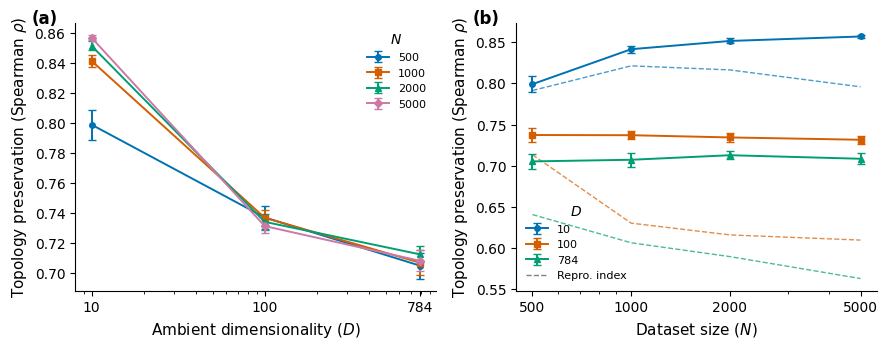

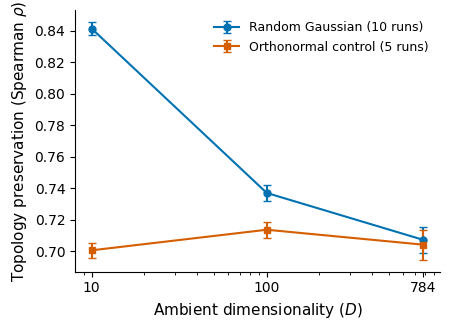

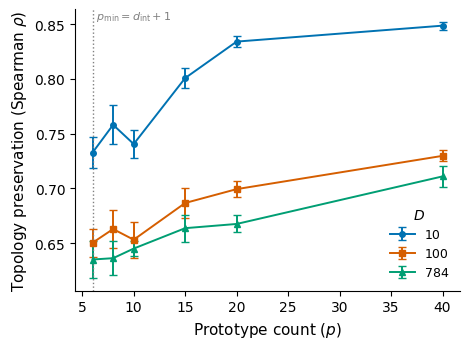

npz arrays: {'X': (5000, 768), 'words': (5000,)}


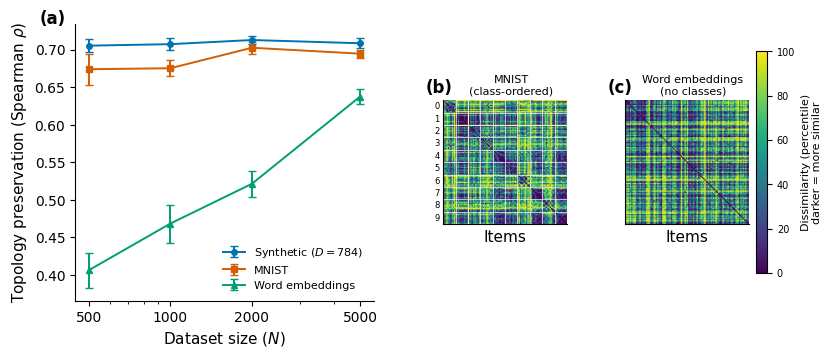

Done. Figures written to /content/drive/MyDrive/dissertation/figures/


In [ ]:
# =====================================================================
# DISSERTATION FIGURES — generation script (Colab)
# Produces the four consolidated body figures + optional appendix figures.
# APA-compliant: axis labels, legends, panel letters, NO in-image titles
# (LaTeX captions carry figure number + title). 300 dpi PNG output.
#
# Data: /content/drive/MyDrive/dissertation/
# Output: same folder, /figures subfolder.
# =====================================================================

from google.colab import drive
drive.mount('/content/drive')

import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/dissertation/'
OUT  = os.path.join(BASE, 'figures/')
os.makedirs(OUT, exist_ok=True)

SYNTH_CSV   = BASE + 'results_synthetic_v2.csv'
MNIST_CSV   = BASE + 'results_mnist_v2.csv'
WORDS_CSV   = BASE + 'results_words_v2.csv'
PSWEEP_CSV  = BASE + 'results_p_sweep.csv'
SAT_CSV     = BASE + 'results_saturation.csv'
CONTROL_CSV = BASE + 'results_control_orth.csv'
CEILING_JSON_SYNTH = BASE + 'ceilings_synthetic_v2.json'

RSA = 'rsa_optB_spearman'   # primary DV column (per your schema)

# ---------------------------------------------------------------------
# Styling — colorblind-safe, grayscale-distinguishable
# ---------------------------------------------------------------------
plt.rcParams.update({
    'font.size': 10, 'axes.labelsize': 11, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'errorbar.capsize': 3, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
COLORS  = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']  # Okabe-Ito subset
MARKERS = ['o', 's', '^', 'D']

def cond_stats(df, group_cols, val=RSA):
    """Mean and SD of val per condition."""
    g = df.groupby(group_cols)[val].agg(['mean', 'std', 'count']).reset_index()
    return g

def panel_letter(ax, letter):
    ax.text(-0.12, 1.05, f'({letter})', transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top')

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
synth = pd.read_csv(SYNTH_CSV)
mnist = pd.read_csv(MNIST_CSV)
words = pd.read_csv(WORDS_CSV)
psweep = pd.read_csv(PSWEEP_CSV)
ctrl   = pd.read_csv(CONTROL_CSV)
try:
    sat = pd.read_csv(SAT_CSV)
except Exception as e:
    print(f'SATURATION UNAVAILABLE ({e}) — Figure 3 will be single-panel')
    sat = None

print('Loaded. Columns check:')
for name, df in [('synth', synth), ('psweep', psweep), ('sat', sat), ('ctrl', ctrl)]:
    if df is not None:
        print(f'  {name}: {list(df.columns)}')

# --- Reproducibility index -------------------------------------------------
# ADAPTER: handles the two ceiling-JSON shapes used in this project and
# prints what it finds; adapt here if the stored structure changes.
def load_repro_index(path):
    with open(path) as f:
        obj = json.load(f)
    print('Ceiling JSON top-level type/keys:',
          type(obj).__name__, list(obj)[:8] if hasattr(obj, '__iter__') else '')
    out = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, dict):
                # e.g. {"manifold_N1000_D10_p40": {"mean_pairwise_rsa": 0.79, ...}}
                for key in ('mean_pairwise_rsa', 'repro_index', 'ceiling', 'mean'):
                    if key in v:
                        out[k] = v[key]; break
            elif isinstance(v, (int, float)):
                out[k] = v      # e.g. {"manifold_N1000_D10_p40": 0.79}
    if len(out) < 12:
        print(f'WARNING: only {len(out)} ceiling entries found — Figure 1 needs 12')
        print('         (4 N-levels x 3 D-levels). This looks like the wrong JSON;')
        print('         overlays will be skipped for missing conditions.')
    return out

repro = load_repro_index(CEILING_JSON_SYNTH)

def repro_for(N, D, p=40):
    return repro.get(f'manifold_N{N}_D{D}_p{p}', None)

# =====================================================================
# FIGURE 1 — RQ1 main sweep (2 panels) + reproducibility overlays
# =====================================================================
Ns = sorted(synth['N'].unique())
Ds = sorted(synth['D'].unique())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))

# (a) rho vs D, one line per N
st = cond_stats(synth, ['N', 'D'])
for i, N in enumerate(Ns):
    s = st[st['N'] == N].sort_values('D')
    ax1.errorbar(s['D'], s['mean'], yerr=s['std'], color=COLORS[i],
                 marker=MARKERS[i], ms=4, lw=1.4, label=f'{N}')
ax1.set_xscale('log'); ax1.set_xticks(Ds); ax1.set_xticklabels(Ds)
ax1.set_xlabel('Ambient dimensionality ($D$)')
ax1.set_ylabel('Topology preservation (Spearman $\\rho$)')
from matplotlib.lines import Line2D
ax1.legend(title='$N$', frameon=False, fontsize=8)
panel_letter(ax1, 'a')

# (b) rho vs N, one line per D
for i, D in enumerate(Ds):
    s = st[st['D'] == D].sort_values('N')
    ax2.errorbar(s['N'], s['mean'], yerr=s['std'], color=COLORS[i],
                 marker=MARKERS[i], ms=4, lw=1.4, label=f'{D}')
    rvals = [repro_for(N, D) for N in s['N']]
    if all(r is not None for r in rvals):
        ax2.plot(s['N'], rvals, color=COLORS[i], ls='--', lw=1, alpha=0.7)
ax2.set_xscale('log'); ax2.set_xticks(Ns); ax2.set_xticklabels(Ns)
ax2.set_xlabel('Dataset size ($N$)')
ax2.set_ylabel('Topology preservation (Spearman $\\rho$)')
handles2, labels2 = ax2.get_legend_handles_labels()
handles2.append(Line2D([0], [0], color='gray', ls='--', lw=1))
labels2.append('Repro. index')
ax2.legend(handles2, labels2, title='$D$', frameon=False, fontsize=8,
           loc='lower left')
panel_letter(ax2, 'b')

fig.tight_layout()
fig.savefig(OUT + 'fig1_scaling.png')
plt.show()

# =====================================================================
# FIGURE 2 — the control (random vs orthonormal embedding), N = 1000
# =====================================================================
fig, ax = plt.subplots(figsize=(4.6, 3.4))
main_1000 = cond_stats(synth[synth['N'] == 1000], ['D']).sort_values('D')
ctrl_1000 = cond_stats(ctrl[ctrl['N'] == 1000], ['D']).sort_values('D')

ax.errorbar(main_1000['D'], main_1000['mean'], yerr=main_1000['std'],
            color=COLORS[0], marker='o', ms=5, lw=1.5,
            label='Random Gaussian (10 runs)')
ax.errorbar(ctrl_1000['D'], ctrl_1000['mean'], yerr=ctrl_1000['std'],
            color=COLORS[1], marker='s', ms=5, lw=1.5,
            label='Orthonormal control (5 runs)')
ax.set_xscale('log'); ax.set_xticks(Ds); ax.set_xticklabels(Ds)
ax.set_xlabel('Ambient dimensionality ($D$)')
ax.set_ylabel('Topology preservation (Spearman $\\rho$)')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT + 'fig2_control.png')
plt.show()

# =====================================================================
# FIGURE 3 — RQ2 capacity (2 panels): p-sweep + saturation
# =====================================================================
if sat is None:
    fig, ax1 = plt.subplots(figsize=(4.8, 3.6))
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))

# (a) p-sweep: rho vs p, one line per D; vline at floor p = 6
ps = cond_stats(psweep, ['D', 'p'])
for i, D in enumerate(sorted(psweep['D'].unique())):
    s = ps[ps['D'] == D].sort_values('p')
    ax1.errorbar(s['p'], s['mean'], yerr=s['std'], color=COLORS[i],
                 marker=MARKERS[i], ms=4, lw=1.4, label=f'{D}')
ax1.axvline(6, color='gray', ls=':', lw=1)
ax1.text(6, ax1.get_ylim()[1], ' $p_{\\min}=d_{\\mathrm{int}}+1$',
         fontsize=8, color='gray', va='top')
ax1.set_xlabel('Prototype count ($p$)')
ax1.set_ylabel('Topology preservation (Spearman $\\rho$)')
ax1.legend(title='$D$', frameon=False)
if sat is not None:
    panel_letter(ax1, 'a')

    # (b) saturation: RSA vs embedding dimensionality d at p = 40
    # ADAPTER: auto-detect the embedding-dimensionality column
    d_col = next((c for c in ('d', 'embed_dim', 'embedding_dim', 'n_components')
                  if c in sat.columns and sat[c].nunique() > 1), None)
    print('Saturation d-column detected:', d_col)
    ss = cond_stats(sat, ['D', d_col])
    for i, D in enumerate(sorted(sat['D'].unique())):
        s = ss[ss['D'] == D].sort_values(d_col)
        ax2.errorbar(s[d_col], s['mean'], yerr=s['std'], color=COLORS[i],
                     marker=MARKERS[i], ms=4, lw=1.4, label=f'{D}')
    ax2.axvline(5, color='gray', ls=':', lw=1)
    ax2.text(5, ax2.get_ylim()[1], ' $d_{\\mathrm{int}}$', fontsize=8,
             color='gray', va='top')
    ax2.set_xlabel('Embedding dimensionality ($d$)')
    ax2.set_ylabel('RSA through spectral embedding (Spearman $\\rho$)')
    ax2.legend(title='$D$', frameon=False)
    panel_letter(ax2, 'b')

fig.tight_layout()
fig.savefig(OUT + 'fig3_capacity.png')
plt.show()

# =====================================================================
# FIGURE 4 — RQ3 (2 panels): three-dataset overlay + RDM pair
# =====================================================================
fig = plt.figure(figsize=(9.5, 3.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 0.75, 0.75], wspace=0.35)
ax1 = fig.add_subplot(gs[0])

series = [('Synthetic ($D=784$)', synth[synth['D'] == 784]),
          ('MNIST', mnist), ('Word embeddings', words)]
for i, (label, df) in enumerate(series):
    s = cond_stats(df, ['N']).sort_values('N')
    ax1.errorbar(s['N'], s['mean'], yerr=s['std'], color=COLORS[i],
                 marker=MARKERS[i], ms=4, lw=1.4, label=label)
ax1.set_xscale('log'); ax1.set_xticks(Ns); ax1.set_xticklabels(Ns)
ax1.set_xlabel('Dataset size ($N$)')
ax1.set_ylabel('Topology preservation (Spearman $\\rho$)')
ax1.legend(frameon=False, fontsize=8)
panel_letter(ax1, 'a')

# (b/c) RDM pair: MNIST (class-ordered) vs word embeddings, 100 items each
from sklearn.datasets import fetch_openml
from scipy.spatial.distance import pdist, squareform

rng = np.random.default_rng(0)

# MNIST: 10 per class, ordered by class -> block structure visible
mn = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_mn, y_mn = mn.data, mn.target.astype(int)
idx = np.concatenate([rng.choice(np.where(y_mn == c)[0], 10, replace=False)
                      for c in range(10)])
rdm_mn = squareform(pdist(X_mn[idx], metric='euclidean'))

# Word embeddings: 100-item subsample of the SAVED experiment embeddings,
# so the RDM shows exactly the vectors the results used.
npz = np.load(BASE + 'bert_word_embeddings.npz', allow_pickle=True)
print('npz arrays:', {k: getattr(npz[k], 'shape', type(npz[k])) for k in npz.files})
# ADAPTER: pick the 2-D float array as the embedding matrix
emb_key = next(k for k in npz.files
               if getattr(npz[k], 'ndim', 0) == 2 and np.issubdtype(npz[k].dtype, np.floating))
emb_all = npz[emb_key]
sel = sorted(rng.choice(emb_all.shape[0], 100, replace=False))
rdm_wd = squareform(pdist(emb_all[sel], metric='euclidean'))

from scipy.stats import rankdata

def percentile_rdm(rdm):
    """Rank-transform off-diagonal dissimilarities to percentiles (standard
    RSA visualisation; maximises visible rank structure and makes panels with
    different raw distance scales comparable by construction)."""
    m = rdm.copy().astype(float)
    n = m.shape[0]
    off = ~np.eye(n, dtype=bool)
    m[off] = rankdata(m[off]) / off.sum() * 100.0
    np.fill_diagonal(m, 0.0)
    return m

panel_names = {'b': 'MNIST\n(class-ordered)',
               'c': 'Word embeddings\n(no classes)'}
for k, (rdm, ttl_letter) in enumerate([(rdm_mn, 'b'), (rdm_wd, 'c')]):
    ax = fig.add_subplot(gs[k + 1])
    im = ax.imshow(percentile_rdm(rdm), cmap='viridis', aspect='equal',
                   vmin=0, vmax=100)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('Items')
    ax.text(0.55, 1.03, panel_names[ttl_letter], transform=ax.transAxes,
            fontsize=8, ha='center', va='bottom')
    ax.text(-0.14, 1.03, f'({ttl_letter})', transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='bottom', ha='left')
    if ttl_letter == 'b':
        # class boundaries: 10 items per digit class, class-ordered
        for b in range(10, 100, 10):
            ax.axhline(b - 0.5, color='white', lw=0.6, alpha=0.8)
            ax.axvline(b - 0.5, color='white', lw=0.6, alpha=0.8)
        # digit labels along the left edge, one per class block
        for c in range(10):
            ax.text(-3.5, c * 10 + 4.5, str(c), fontsize=6,
                    ha='right', va='center')
cbar = fig.colorbar(im, ax=fig.axes[-2:], shrink=0.8, pad=0.02)
cbar.set_label('Dissimilarity (percentile)\ndarker = more similar', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.savefig(OUT + 'fig4_structure.png')
plt.show()

print('Done. Figures written to', OUT)